## 0. Imports

In [43]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from scipy import stats
from scipy.optimize import curve_fit

import altair as alt
alt.data_transformers.disable_max_rows()

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

## 1. Configuration

> **Edit this cell to change variables, shock sizes, or asset groups.**

In [44]:
# ── Data path ────────────────────────────────────────────────
DATA_PATH = '../data/'

## 2. Data Loading & Preparation

Run once. Produces `regr_pool_users` — the master dataset used by both crypto and stablecoin sections.

In [45]:
# ── Load raw files ───────────────────────────────────────────
print("Loading data...")

dr = pd.read_csv(DATA_PATH + 'liquidation_real.csv')
dr['shockAsset'] = dr['shock'].str.replace('c', '', regex=False)
dr['asset_group'] = np.where(
    dr['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(dr['shockAsset'].isin(['USDC', 'DAI']), 'Stablecoin', 'Other')
)

pool_stats = pd.read_csv(DATA_PATH + 'pool_statistics_with_cf.csv')
pool_stats['shockAsset'] = pool_stats['node'].str.replace('c', '', regex=False)

net_stats = pd.read_csv(DATA_PATH + 'network_statistics.csv')

cen_pool = pd.read_csv(DATA_PATH + 'pool_centralities.csv')
cen_pool['shockAsset'] = cen_pool['node'].str.replace('c', '', regex=False)

all_n = pd.read_csv(DATA_PATH + 'shockAsset_lenders_borrowers_new.csv').sort_values('date')
all_n['date'] = pd.to_datetime(all_n['date'])
all_n['shockAsset'] = all_n['symbol'].str.replace('c', '', regex=False)

print("Done.")

Loading data...
Done.


In [46]:
pool_stats[['date', 'shockAsset', 'pctDeposit', 'pctBorrow', 'pctEquity']].rename(columns={
      'pctDeposit': 'shareDeposit',                                                          
      'pctBorrow':  'shareBorrow',                                                           
      'pctEquity':  'shareEquity'                                                            
  })           

,date,shockAsset,shareDeposit,shareBorrow,shareEquity
0,2020-01-01,BAT,0.006680,2.289820e-03,0.000516
1,2020-01-01,DAI,0.159804,3.421849e-01,0.571235
2,2020-01-01,ETH,0.379802,1.182162e-02,0.003153
3,2020-01-01,REP,0.112051,1.971574e-03,0.000364
4,2020-01-01,SAI,0.048236,7.874537e-02,0.099439
...,...,...,...,...,...
24332,2024-06-15,USDP,0.000401,1.561052e-03,0.000150
24333,2024-06-15,USDT,0.181990,5.791646e-01,0.088551
24334,2024-06-15,WBTC,0.291670,4.308659e-03,0.000017
24335,2024-06-15,YFI,0.000083,7.408324e-08,0.000061


In [47]:
# ── Merge pool stats + bad debt ──────────────────────────────
regr_pool = pd.merge(pool_stats, dr, on=['date', 'shockAsset'], how='left')
regr_pool['date']  = pd.to_datetime(regr_pool['date'], errors='coerce')
regr_pool['year']  = regr_pool['date'].dt.year
regr_pool['month'] = regr_pool['date'].dt.month

regr_pool['assets']          = regr_pool['in_weight'] + regr_pool['ext_assets']
#regr_pool['log_assets']      = np.log1p(regr_pool['assets'])
regr_pool['equity_share']    = regr_pool['equity']     / regr_pool['assets']
regr_pool['extassets_share'] = regr_pool['ext_assets'] / regr_pool['assets']

total_assets = (regr_pool.groupby('date')['assets'].sum()
                .reset_index(name='total_assets'))
regr_pool = regr_pool.merge(total_assets, on='date', how='left')

regr_pool['size_share']    = regr_pool['assets']      / regr_pool['total_assets']
# regr_pool['self_borrow']   = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['total_assets']
regr_pool['self_borrow_2'] = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['assets']

# ── Merge centralities + network stats ───────────────────────
for df in [regr_pool, cen_pool, net_stats]:
    df['date'] = pd.to_datetime(df['date'])

cen_net         = cen_pool.merge(net_stats, on='date', how='left')
regr_pool_final = regr_pool.merge(cen_net, on=['date', 'shockAsset'], how='left')

# ── Dependent and independent variables ──────────────────────
#regr_pool_final['TD']                = regr_pool_final['T'] + regr_pool_final['D']
#regr_pool_final['log_out_weight']    = np.log(regr_pool_final['out_weight'])
regr_pool_final['utilization_ratio'] = 1 - (
    regr_pool_final['ext_assets'] /
    (regr_pool_final['ext_assets'] + regr_pool_final['in_weight'])
)
#regr_pool_final['log_totCollateral'] = np.log(regr_pool_final['totCollateral'])
#regr_pool_final['log_B']             = np.log(regr_pool_final['B'])
regr_pool_final['share_B']           = regr_pool_final['B'] / regr_pool_final['assets']
#regr_pool_final['log_share_B']       = np.log(regr_pool_final['share_B'])
regr_pool_final['share_T']           = (regr_pool_final['T'] - regr_pool_final['Tp']) / regr_pool_final['assets']
regr_pool_final['delta_T']           = (regr_pool_final['T'] - regr_pool_final['Tp'])

# ── Merge user/collateral neighbourhood features ─────────────
regr_pool_users = regr_pool_final.merge(all_n, on=['date', 'shockAsset'], how='left')

# Log-transform skewed neighbourhood variables
# Add new log-transforms here if you add new raw variables above
#for log_col, raw_col in [
#    ('log_collaterals-in_weight-sum',   'collaterals-in_weight-sum'),
#    ('log_collaterals-equity-wavg',     'collaterals-equity-wavg'),
#    ('log_collaterals-out_weight-wavg', 'collaterals-out_weight-wavg'),
#    ('log_collaterals-out_degree-wavg', 'collaterals-out_degree-wavg'),
#    ('log_borrowers-out_weight-wavg',   'borrowers-out_weight-wavg'),
#    ('log_borrowers-equity-wavg',       'borrowers-equity-wavg'),
#]:
#    regr_pool_users[log_col] = np.log(regr_pool_users[raw_col])

regr_pool_users['asset_group'] = np.where(
    regr_pool_users['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(regr_pool_users['shockAsset'].isin(['USDC', 'DAI']),
             'Stablecoin', 'Other')
)

print(f"Master dataset ready: {regr_pool_users.shape}")
print(f"Assets: {sorted(regr_pool_users['shockAsset'].unique())}")

Master dataset ready: (96508, 413)
Assets: ['AAVE', 'BAT', 'COMP', 'DAI', 'ETH', 'FEI', 'LINK', 'REP', 'SAI', 'SUSHI', 'TUSD', 'UNI', 'USDC', 'USDP', 'USDT', 'WBTC', 'YFI', 'ZRX']


In [48]:
print(regr_pool_users.columns.tolist())

['date', 'node_x', 'collateralFactor', 'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight', 'out_weight_hhi', 'in_out_ratio', 'ext_assets', 'equity', 'selfBorrowUSD', 'pctSelfBorrow_x', 'usedCollateralUSD', 'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity', 'shockAsset', 'shock', 'size', 'C', 'D', 'T', 'E', 'Cp', 'Dp', 'Tp', 'B', 'Ep', 'liquidated', 'seized', 'asset_group', 'year', 'month', 'assets', 'equity_share', 'extassets_share', 'total_assets', 'size_share', 'self_borrow_2', 'node_y', 'eigenvector', 'pagerank', 'hub', 'authority', 'core', 'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding', 'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled', 'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled', 'closeness_scaled', 'borrowing_scaled', 'funding_scaled', 'nPool', 'nUsers', 'nPureLenders', 'nBorrowers', 'nPureLenders100', 'nBorrowers100', 'nNewPureLenders', 'nNewBorrowers', 'nNewPureLenders100', 'n

# 2. ANALYSIS OF LIQUIDITY

# 2.1 Descriptive Statistics

In [49]:
lp = pd.read_csv(DATA_PATH + 'liquidation_pools_real.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)

lp['date'] = pd.to_datetime(lp['date'])

In [50]:
# Merge Liquidation_pools with other dataset

lp_own = lp[lp['shockAsset'] == lp['otherAsset']].copy()

rename_map = {
    'C':  'C_pool',
    'D':  'D_pool',
    'T':  'T_pool',
    'E':  'E_pool',
    'Cp': 'Cp_pool',
    'Dp': 'Dp_pool',
    'Tp': 'Tp_pool',
    'B':  'B_pool',
    'Ep': 'Ep_pool',
}
lp_own = lp_own.rename(columns=rename_map)

lp_own = lp_own.rename(columns={'date_pool': 'date'})


In [51]:
final = pd.merge(regr_pool_users, lp_own, on=['date', 'size', 'shockAsset'], how='left')
final['shareT_pool'] = (final['T_pool'] - final['Tp_pool']) / final['assets']

### Structural Break

In [52]:
# WARNING: Set arbitrary break date !
break_date = pd.to_datetime('2021-01-01')  # or use this fixed date if you prefer

In [53]:
lp = pd.read_csv(DATA_PATH + 'liquidation_pools_real.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)

lp['date'] = pd.to_datetime(lp['date'])

In [54]:
new_health = pd.read_csv(DATA_PATH + 'shockAsset_collateral_filtered.csv')
new_health['date'] = pd.to_datetime(new_health['date'])

In [55]:
merge_keys = ['date', 'shockAsset', 'size']
common_cols = [c for c in new_health.columns 
               if c in final.columns and c not in merge_keys]
print(f"Columns to be replaced: {common_cols}")
print(f"New columns from new_health: {[c for c in new_health.columns if c not in final.columns and c not in merge_keys]}")


Columns to be replaced: ['collaterals-in_weight-count', 'collaterals-out_weight-count', 'collaterals-depositUSD-sum', 'collaterals-in_degree-sum', 'collaterals-in_weight-sum', 'collaterals-in_weight_hhi-sum', 'collaterals-out_degree-sum', 'collaterals-out_weight-sum', 'collaterals-out_weight_hhi-sum', 'collaterals-in_out_ratio-sum', 'collaterals-ext_assets-sum', 'collaterals-equity-sum', 'collaterals-selfBorrowUSD-sum', 'collaterals-pctSelfBorrow-sum', 'collaterals-usedCollateralUSD-sum', 'collaterals-pctUsedCollateral-sum', 'collaterals-maxCollateralUSD-sum', 'collaterals-health-sum', 'collaterals-pctDeposit-sum', 'collaterals-debtToCollateral-sum', 'collaterals-depositUSD-avg', 'collaterals-in_degree-avg', 'collaterals-in_weight-avg', 'collaterals-in_weight_hhi-avg', 'collaterals-out_degree-avg', 'collaterals-out_weight-avg', 'collaterals-out_weight_hhi-avg', 'collaterals-in_out_ratio-avg', 'collaterals-ext_assets-avg', 'collaterals-equity-avg', 'collaterals-selfBorrowUSD-avg', 'coll

In [56]:
final_updated = (final
                 .drop(columns=common_cols)
                 .merge(new_health.assign(shockAsset=new_health['symbol'].str.replace('c', '', regex=False))
                                  .drop(columns=['symbol']),
                        on=['date', 'shockAsset'], how='left'))

print(f"Original shape: {final.shape}")
print(f"Updated shape:  {final_updated.shape}")
print(f"Unmatched rows: {final_updated['collaterals-health-wavg'].isna().sum()}")


Original shape: (96508, 428)
Updated shape:  (288846, 429)
Unmatched rows: 334


### 3. Features' selection, Analysis of liquidation, Regressions 

### 3.1 Features' dictionary

In [57]:
# Create dictionary of column groups for pool-level features

pool_cols = {
    'own': [
        'ext_assets', 'equity', 
        # 'selfBorrowUSD', 'pctSelfBorrow_x', 'self_borrow',
        'usedCollateralUSD', 'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity',
        'assets', 'log_assets', 'equity_share', 'extassets_share',
        'size_share',  'self_borrow_2',
        'log_out_weight', 'utilization_ratio', 'C_pool', 'D_pool', 'T_pool', 'E_pool', 'collateralFactor', 
         'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight', 'out_weight_hhi', 'in_out_ratio' 
    ],
    'centrality': [
        'eigenvector', 'pagerank', 'hub', 'authority', 'core',
        'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding',
        'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled',
        'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled',
        'closeness_scaled', 'borrowing_scaled', 'funding_scaled',
        'density', 'reciprocity', 'biDensity', 'biAvgClustering', 'biAvgLatapyClustering'
    ],
    'aggregate': [
        'nPool', 'nUsers', 'nPureLenders', 'nBorrowers',
        'nPureLenders100', 'nBorrowers100',
        'nNewPureLenders', 'nNewBorrowers', 'nNewPureLenders100', 'nNewBorrowers100',
        'totDeposit', 'totPureLender', 'totCollateral', 'totBorrow', 'utilization',
        'totNewDeposit', 'totNewBorrow', 'newUtilization',
        'nDeposit', 'nBorrow', 'nDeposit100', 'nBorrow100',
        'nNewDeposit', 'nNewBorrow', 'nNewDeposit100', 'nNewBorrow100',
        'C', 'D', 'T', 'E', 'TD', 'total_assets'
    ],
    'cross_pool': [
        c for c in final.columns if c.startswith('pools_')
    ]
}

# Verify all columns exist in final
for group, cols in pool_cols.items():
    missing = [c for c in cols if c not in final.columns]
    if missing:
        print(f"[{group}] Missing: {missing}")
    else:
        print(f"[{group}] OK — {len(cols)} columns")


[own] Missing: ['log_assets', 'log_out_weight']
[centrality] OK — 27 columns
[aggregate] Missing: ['TD']
[cross_pool] OK — 72 columns


In [58]:
users_cols = {
    'network': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio'])
    ],
    'financial': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['equity', 'health', 'pctSelfBorrow'])
    ]
}

for group, cols in users_cols.items():
    print(f"[{group}] {len(cols)} columns: {cols}")


[network] 54 columns: ['users_in_degree_mean', 'users_in_degree_std', 'users_in_degree_25%', 'users_in_degree_50%', 'users_in_degree_75%', 'users_in_degree_skew', 'users_in_degree_kurtosis', 'users_in_weight_mean', 'users_in_weight_std', 'users_in_weight_25%', 'users_in_weight_50%', 'users_in_weight_75%', 'users_in_weight_skew', 'users_in_weight_kurtosis', 'users_in_weight_hhi_mean', 'users_in_weight_hhi_std', 'users_in_weight_hhi_25%', 'users_in_weight_hhi_50%', 'users_in_weight_hhi_75%', 'users_in_weight_hhi_skew', 'users_in_weight_hhi_kurtosis', 'users_out_degree_mean', 'users_out_degree_std', 'users_out_degree_25%', 'users_out_degree_50%', 'users_out_degree_75%', 'users_out_degree_skew', 'users_out_degree_kurtosis', 'users_out_weight_mean', 'users_out_weight_std', 'users_out_weight_25%', 'users_out_weight_50%', 'users_out_weight_75%', 'users_out_weight_skew', 'users_out_weight_kurtosis', 'users_out_weight_hhi_mean', 'users_out_weight_hhi_std', 'users_out_weight_hhi_25%', 'users_out

In [59]:
features = {                                                                                     
      'pool_own': pool_cols['own'],                                                                
      'pool_centrality': pool_cols['centrality'],                                                  
      'pool_aggregate': pool_cols['aggregate'],                                                    
      'pool_cross': pool_cols['cross_pool'],                                                       
      'users_network': users_cols['network'],                                                    
      'users_financial': users_cols['financial'],
      'outcome'        : ['log_B', 'share_B', 'log_share_B', 'share_T', 'delta_T', 'Cp', 'Dp', 'Tp', 'B', 'Ep', 'Cp_pool', 'Dp_pool',           
                            'Tp_pool', 'B_pool', 'Ep_pool', 'shareT_pool']                                                   
  }

In [60]:
# Pool additions                                                                               
features['shock']    = ['date', 'year', 'month', 'shockAsset', 'size']   
                                                                                                   
# Collaterals & borrowers: split by topic                                                        
_financial_keys = ['depositUSD', 'borrowUSD', 'ext_assets', 'equity', 'selfBorrowUSD',           
                     'pctSelfBorrow', 'usedCollateralUSD', 'pctUsedCollateral', 'maxCollateralUSD',
                     'health', 'pctBorrow', 'pctDeposit', 'debtToCollateral',
                     'lenders100_hhiDeposit', 'borrowers100_hhiBorrow',
                     'borrowers100_health_mean', 'borrowers100_health_std',
                     'borrowers100_health_25%', 'borrowers100_health_50%', 'borrowers100_health_75%',
                     'borrowers100_health_wavg', 'borrowers100_health_skew', 'borrowers100_health_kurtosis',
                     'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
                      
_network_keys   = ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio']         
                                                                                                   
for prefix in ['collaterals', 'borrowers']:                                                    
      features['users_financial'] += [c for c in final.columns if c.startswith(f'{prefix}-')       
                                       and any(k in c for k in _financial_keys)]                   
      features['users_network']   += [c for c in final.columns if c.startswith(f'{prefix}-')
                                       and any(k in c for k in _network_keys)                      
                                       and c not in features['users_financial']]                 
                                                                                                   
features['users_financial'] += ['log_borrowers-equity-wavg',                                     
                                   'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
features['users_network']   += ['log_collaterals-in_weight-sum', 'log_collaterals-equity-wavg',  
                                   'log_collaterals-out_weight-wavg',                              
                                  'log_collaterals-out_degree-wavg',
                                   'log_borrowers-out_weight-wavg']                                
                                                                                                   
# Clean pool groups: remove misplaced columns
_exclude = ['borrowers-', 'collaterals-', 'users_hhiDeposit', 'users_hhiBorrow',                 
              'users_hhiEquity']                                                                               
for key in ['pool_own', 'pool_aggregate', 'pool_centrality', 'pool_cross']:
      features[key] = [c for c in features[key]                                                    
                       if not any(c.startswith(e) if e.endswith('-') else c == e for e in          
                          _exclude)]                                                                                       
                                                                                                   
# Deduplicate all groups                                                                         
features = {k: list(dict.fromkeys(v)) for k, v in features.items()}

# Remove features ending with 'USD' from all feature lists
                                                                                                                                                                                               
def drop_usd(lst):                                                                   
      return [f for f in lst if 'USD' not in f]                                                                                                                                      
                                                                                                                                                                                                                                                                                                                                                                                           
# Fix features dict (cell 59) — needs explicit update since it's a separate reference                                                                                                        
features['pool_own'] = drop_usd(features['pool_own'])                                                                                                                                        
features['users_financial'] = drop_usd(features['users_financial'])   

# Fix _financial_keys (cell 60)                                                                                                                                                              
_financial_keys = drop_usd(_financial_keys)                                                                                                                                                  
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
for k, v in features.items():                                                        
      remaining = [f for f in v if 'USD' in f]                                         
      if remaining:                                                                    
          print(f"features['{k}']: {remaining}")                                       
print("Done — no output above means all USD features removed.")   

def drop_100(lst):                                                                                                                                                                           
      return [f for f in lst if not f.endswith('100')]                                                                                                                                         
                                                                                                                                                                                                                                                                                                                                                                                     
# Fix features dict (cell 59) — explicit update needed                                                                                                                                       
features['pool_aggregate'] = drop_100(features['pool_aggregate'])                                                                                                                            
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
print("100-ending remaining in features['pool_aggregate']:", [f for f in features['pool_aggregate'] if f.endswith('100')])  

# Remove features ending with '%' from all feature lists                                                                                                                                     
                                                                                                                                                                                               
def drop_pct(lst):                                                                                                                                                                           
      return [f for f in lst if not f.endswith('%')]                                                                                                                                           
                                                                                                                                                                                               
_financial_keys              = drop_pct(_financial_keys)                                                                                                                                     
features['users_financial']  = drop_pct(features['users_financial'])                                                                                                                         
features['pool_cross']       = drop_pct(features['pool_cross'])                                                                                                                              
features['users_network']    = drop_pct(features['users_network'])                                                                                                                           
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
for name, lst in [('_financial_keys', _financial_keys),                                                                                                                                      
                    ('users_financial', features['users_financial']),                                                                                                                          
                    ('pool_cross',      features['pool_cross']),                                                                                                                               
                    ('users_network',   features['users_network'])]:                                                                                                                           
      remaining = [f for f in lst if f.endswith('%')]                                                                                                                                          
      print(f"%-ending remaining in {name}: {remaining or 'None'}") 

# Remove features starting with 'log_' from all feature lists                                                                                                                                
                                                                                                                                                                                               
def drop_log(lst):                                                                                                                                                                           
      return [f for f in lst if not f.startswith('log_')]  
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
# Cell 59/60 — features dict (all groups including users_network)
for key in features:
      features[key] = drop_log(features[key])

# Verification
for k, v in features.items():
      remaining = [f for f in v if f.startswith('log_')]
      if remaining:
          print(f"log_ remaining in features['{k}']: {remaining}")
print("Done")    

# Remove features ending with 'sum' from all lists                                                                                                          
def drop_sum(lst):                                                                   
      return [f for f in lst if not f.endswith('sum')]
                                                                                       
for key in features:                                                                 
      features[key] = drop_sum(features[key])                                          
                                                                                       
# Verification                                                                       
for k, v in features.items():                                                        
      remaining = [f for f in v if f.endswith('sum')]                                  
      if remaining:                                                                    
          print(f"features['{k}']: {remaining}")
print("Done — no output above means all -sum features removed.")

# Split features['users_network'] into two groups
features['collaterals_network'] = [f for f in features['users_network'] if           
f.startswith('collaterals')]
features['users_network']       = [f for f in features['users_network'] if not       
f.startswith('collaterals')]                                                         
  
                                                       
# Split features['users_financial'] into two groups                                  
features['collaterals_financial'] = [f for f in features['users_financial'] if
  f.startswith('collaterals')]                                                         
features['users_financial']       = [f for f in features['users_financial'] if not
  f.startswith('collaterals')]                                                         
                  
# Verification                                                                       
for key in ['collaterals_network', 'users_network', 'collaterals_financial',
  'users_financial']:                                                                  
      print(f"{key} ({len(features[key])}):", features[key])

# Verify
all_captured = [c for cols in features.values() for c in cols]                                   
print(f"Duplicates: {[c for c in all_captured if all_captured.count(c) > 1] or 'None'}")
print(f"Not selected ({sum(c not in all_captured for c in final.columns)}): "
        f"{[c for c in final.columns if c not in all_captured]}")   

Done — no output above means all USD features removed.
100-ending remaining in features['pool_aggregate']: []
%-ending remaining in _financial_keys: None
%-ending remaining in users_financial: None
%-ending remaining in pool_cross: None
%-ending remaining in users_network: None
Done
Done — no output above means all -sum features removed.
collaterals_network (23): ['collaterals-in_weight-count', 'collaterals-out_weight-count', 'collaterals-in_degree-avg', 'collaterals-in_weight-avg', 'collaterals-in_weight_hhi-avg', 'collaterals-out_degree-avg', 'collaterals-out_weight-avg', 'collaterals-out_weight_hhi-avg', 'collaterals-in_out_ratio-avg', 'collaterals-in_degree-median', 'collaterals-in_weight-median', 'collaterals-in_weight_hhi-median', 'collaterals-out_degree-median', 'collaterals-out_weight-median', 'collaterals-out_weight_hhi-median', 'collaterals-in_out_ratio-median', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degr

In [61]:
# Features per group

for group, cols in features.items():                                                             
    print(f"[{group}] {len(cols)} columns")

[pool_own] 24 columns
[pool_centrality] 27 columns
[pool_aggregate] 24 columns
[pool_cross] 45 columns
[users_network] 56 columns
[users_financial] 38 columns
[outcome] 14 columns
[shock] 5 columns
[collaterals_network] 23 columns
[collaterals_financial] 21 columns


### 3.2 Features' selection for regressions

In [62]:
# Backup features dict before further modifications
import copy                                                                                 
features_backup = copy.deepcopy(features) 

In [63]:
features['pool_own']              = ['pctUsedCollateral', 'self_borrow_2', 
                                    'utilization_ratio', 'collateralFactor', 
                                    'in_degree','in_weight_hhi', 'out_degree', 
                                    'out_weight_hhi' ] 

features['pool_centrality']       = ['pagerank', 'pagerank_scaled', 'hub', 'hub_scaled']

features['pool_cross']            = ['pools_hhiDeposit', 'pools_hhiBorrow', 'pools_in_degree_std', 
                                    'pools_out_degree_std', 'pools_pctSelfBorrow_std', 
                                    'pools_out_degree_wavg','pools_in_degree_wavg','pools_pctSelfBorrow_wavg']

features['collaterals_network']   = ['collaterals-in_degree-wavg',
                                    'collaterals-in_weight-wavg',
                                    'collaterals-in_weight_hhi-wavg',
                                    'collaterals-out_degree-wavg',
                                    'collaterals-out_weight-wavg',
                                    'collaterals-out_weight_hhi-wavg']

features['collaterals_financial'] = ['collaterals-pctSelfBorrow-wavg',
                                    'collaterals-pctUsedCollateral-wavg',
                                    'collaterals-health-wavg',
                                    'collaterals-pctDeposit-wavg']

features['borrowers_network']   = ['borrowers-in_degree-wavg',
                                    'borrowers-in_weight-wavg',
                                    'borrowers-in_weight_hhi-wavg',
                                    'borrowers-out_degree-wavg',
                                    'borrowers-out_weight-wavg',
                                    'borrowers-out_weight_hhi-wavg']

features['borrowers_financial'] = ['borrowers-pctSelfBorrow-wavg',
                                    'borrowers-pctUsedCollateral-wavg',
                                    'borrowers-health-wavg',
                                    'borrowers-pctDeposit-wavg']


Regression analysis looped over all shock sizes in [0.10, 1].

Drop this as a single cell (or a few cells) after the data-preparation
and features-definition cells in your notebook (i.e. after `final_updated`
and `features` are already defined).

The loop re-runs, for every shock size:
  - sample construction  (cells ~34-35 in the original notebook)
  - descriptive statistics
  - Step 1-4  : OLS on all theory vars
  - Step 6    : out-of-sample validation
  - Step 8    : LASSO robustness check
  - Step 9    : refit OLS on LASSO-selected vars
  - Step 10   : trimmed model (no FE)
  - Step 11   : trimmed model (with WBTC FE)

All results are collected in `results_by_size` (dict keyed by shock size)
and a summary comparison table is printed at the end.

In [64]:
import copy
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import TimeSeriesSplit
 
# ══════════════════════════════════════════════════════════════════
# Global config (unchanged across sizes)
# ══════════════════════════════════════════════════════════════════
START_DATE       = '2021-01-01'
END_DATE         = '2024-06-15'
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['ETH', 'WBTC']
 
ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200

GROUPS_flat = [
    'pool_own', 'pool_cross', 'pool_centrality',
    'collaterals_network', 'collaterals_financial',
#    'borrowers_network',   'borrowers_financial',
]

rename_map = {
    # pool_own
    'pctUsedCollateral':               'Collateral utilisation',
    'self_borrow_2':                   'Self-borrowing rate',
    'utilization_ratio':               'Utilisation ratio',
    'collateralFactor':                'Collateral factor',
    'in_degree':                       'In-degree',
    'in_weight_hhi':                   'In-weight HHI',
    'out_degree':                      'Out-degree',
    'out_weight_hhi':                  'Out-weight HHI',

    # pool_centrality
    'pagerank':                        'PageRank',
    'pagerank_scaled':                 'PageRank (scaled)',
    'hub':                             'Hub score',
    'hub_scaled':                      'Hub score (scaled)',

    # pool_cross
    'pools_hhiDeposit':                'Deposit HHI (cross-pool)',
    'pools_hhiBorrow':                 'Borrow HHI (cross-pool)',
    'pools_in_degree_std':             'In-degree dispersion (cross-pool)',
    'pools_out_degree_std':            'Out-degree dispersion (cross-pool)',
    'pools_pctSelfBorrow_std':         'Self-borrow dispersion (cross-pool)',
    'pools_out_degree_wavg':           'Out-degree wavg. (cross-pool)',
    'pools_in_degree_wavg':            'In-degree wavg. (cross-pool)',
    'pools_pctSelfBorrow_wavg':        'Self-borrow wavg. (cross-pool)',

    # collaterals_network
    'collaterals-in_degree-wavg':      'In-degree wavg. (collateral)',
    'collaterals-in_weight-wavg':      'In-flow weight wavg. (collateral)',
    'collaterals-in_weight_hhi-wavg':  'In-flow conc. wavg. (collateral)',
    'collaterals-out_degree-wavg':     'Out-degree wavg. (collateral)',
    'collaterals-out_weight-wavg':     'Out-flow weight wavg. (collateral)',
    'collaterals-out_weight_hhi-wavg': 'Out-flow conc. wavg. (collateral)',

    # collaterals_financial
    'collaterals-pctSelfBorrow-wavg':        'Self-borrow rate wavg. (collateral)',
    'collaterals-pctUsedCollateral-wavg':    'Collateral utilisation wavg. (collateral)',
    'collaterals-health-wavg':               'Health ratio wavg. (collateral)',
    'collaterals-pctDeposit-wavg':           'Deposit share wavg. (collateral)',

    # borrowers_network
    'borrowers-in_degree-wavg':        'In-degree wavg. (borrower)',
    'borrowers-in_weight-wavg':        'In-flow weight wavg. (borrower)',
    'borrowers-in_weight_hhi-wavg':    'In-flow conc. wavg. (borrower)',
    'borrowers-out_degree-wavg':       'Out-degree wavg. (borrower)',
    'borrowers-out_weight-wavg':       'Out-flow weight wavg. (borrower)',
    'borrowers-out_weight_hhi-wavg':   'Out-flow conc. wavg. (borrower)',

    # borrowers_financial
    'borrowers-pctSelfBorrow-wavg':        'Self-borrow rate wavg. (borrower)',
    'borrowers-pctUsedCollateral-wavg':    'Collateral utilisation wavg. (borrower)',
    'borrowers-health-wavg':               'Health ratio wavg. (borrower)',
    'borrowers-pctDeposit-wavg':           'Deposit share wavg. (borrower)',

    # fixed effect
    'fe_WBTC':                         'WBTC fixed effect',
}

def get_renamed_params(model):
    params = model.params.drop('const')
    ci     = model.conf_int().drop('const')
    params_r = params.rename(index=lambda v: rename_map.get(v, v))
    ci_r     = ci.rename(index=lambda v: rename_map.get(v, v))
    return params_r, ci_r
 

In [65]:
# ══════════════════════════════════════════════════════════════════
# Shock-size grid:  0.10, 0.20, …, 1.00
# ══════════════════════════════════════════════════════════════════
SHOCK_SIZES = [round(s, 2) for s in np.arange(0.10, 1.01, 0.10)]
print(f"Shock sizes to loop over: {SHOCK_SIZES}")
 
# Container for all results
results_by_size = {}

Shock sizes to loop over: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]



  SHOCK SIZE = 0.10
  Post-break sample: N=2524  (ETH=1262, WBTC=1262)
  Train: N=1607  2021-01-01 → 2023-03-15
  Test:  N=401   2023-03-15 → 2023-10-01

  [Full OLS]  Train R²=0.1501  Test R²=-0.0900  N vars=30
  [LASSO]  λ_min=0.000106 (5 vars)  λ_1se=0.000344 (0 vars)
  [LASSO OLS]  Train R²=0.1020  Test R²=0.0650  N vars=5
  [Trimmed no FE]  Train R²=0.0839  Test R²=0.0636  N vars=3
  [Trimmed + FE]   Train R²=0.1017  Test R²=0.0664  N vars=4
  Saved: appendix_fe_comparison_size010.pdf

  SHOCK SIZE = 0.20
  Post-break sample: N=2524  (ETH=1262, WBTC=1262)
  Train: N=1607  2021-01-01 → 2023-03-15
  Test:  N=401   2023-03-15 → 2023-10-01

  [Full OLS]  Train R²=0.4885  Test R²=0.5014  N vars=30
  [LASSO]  λ_min=0.000193 (17 vars)  λ_1se=0.003004 (2 vars)
  [LASSO OLS]  Train R²=0.4587  Test R²=0.4132  N vars=17
  [Trimmed no FE]  Train R²=0.3985  Test R²=0.3884  N vars=7
  [Trimmed + FE]   Train R²=0.4008  Test R²=0.3835  N vars=8
  Saved: appendix_fe_comparison_size020.pdf

  SHOC

/var/folders/95/0gcj87_150g4pzspfbpj6m7w0000gp/T/ipykernel_26015/2751327836.py:114: RuntimeWarning: invalid value encountered in scalar divide
  r2_full   = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()
/Users/Stefania/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


  [LASSO]  λ_min=0.000000 (0 vars)  λ_1se=0.000000 (0 vars)
  *** LASSO selected 0 vars — using all available.
  [LASSO OLS]  Train R²=nan  Test R²=nan  N vars=30
  *** No significant vars at ALPHA — relaxing to p<0.05 for trimmed model.
  *** No significant vars — skipping trimmed models.


  SUMMARY — results across all shock sizes
   Size      N   Full TR²  Full TeR²   Lasso TR²  Lasso TeR²   Trim TR²  Trim TeR²   TrimFE TR²  TrimFE TeR²   Vars(trim)
  ---------------------------------------------------------------------------------------------
   0.10   2008     0.1501    -0.0900      0.1020      0.0650     0.0839     0.0636       0.1017       0.0664            3
   0.20   2008     0.4885     0.5014      0.4587      0.4132     0.3985     0.3884       0.4008       0.3835            7
   0.30   2008     0.7644     0.8441      0.7539      0.8187     0.7456     0.8191       0.7519       0.8404           13
   0.40   2008     0.8568     0.8110      0.8437      0.8806     0.8152     0.84

/var/folders/95/0gcj87_150g4pzspfbpj6m7w0000gp/T/ipykernel_26015/2751327836.py:167: RuntimeWarning: invalid value encountered in scalar divide
  r2_lasso   = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()
/Users/Stefania/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


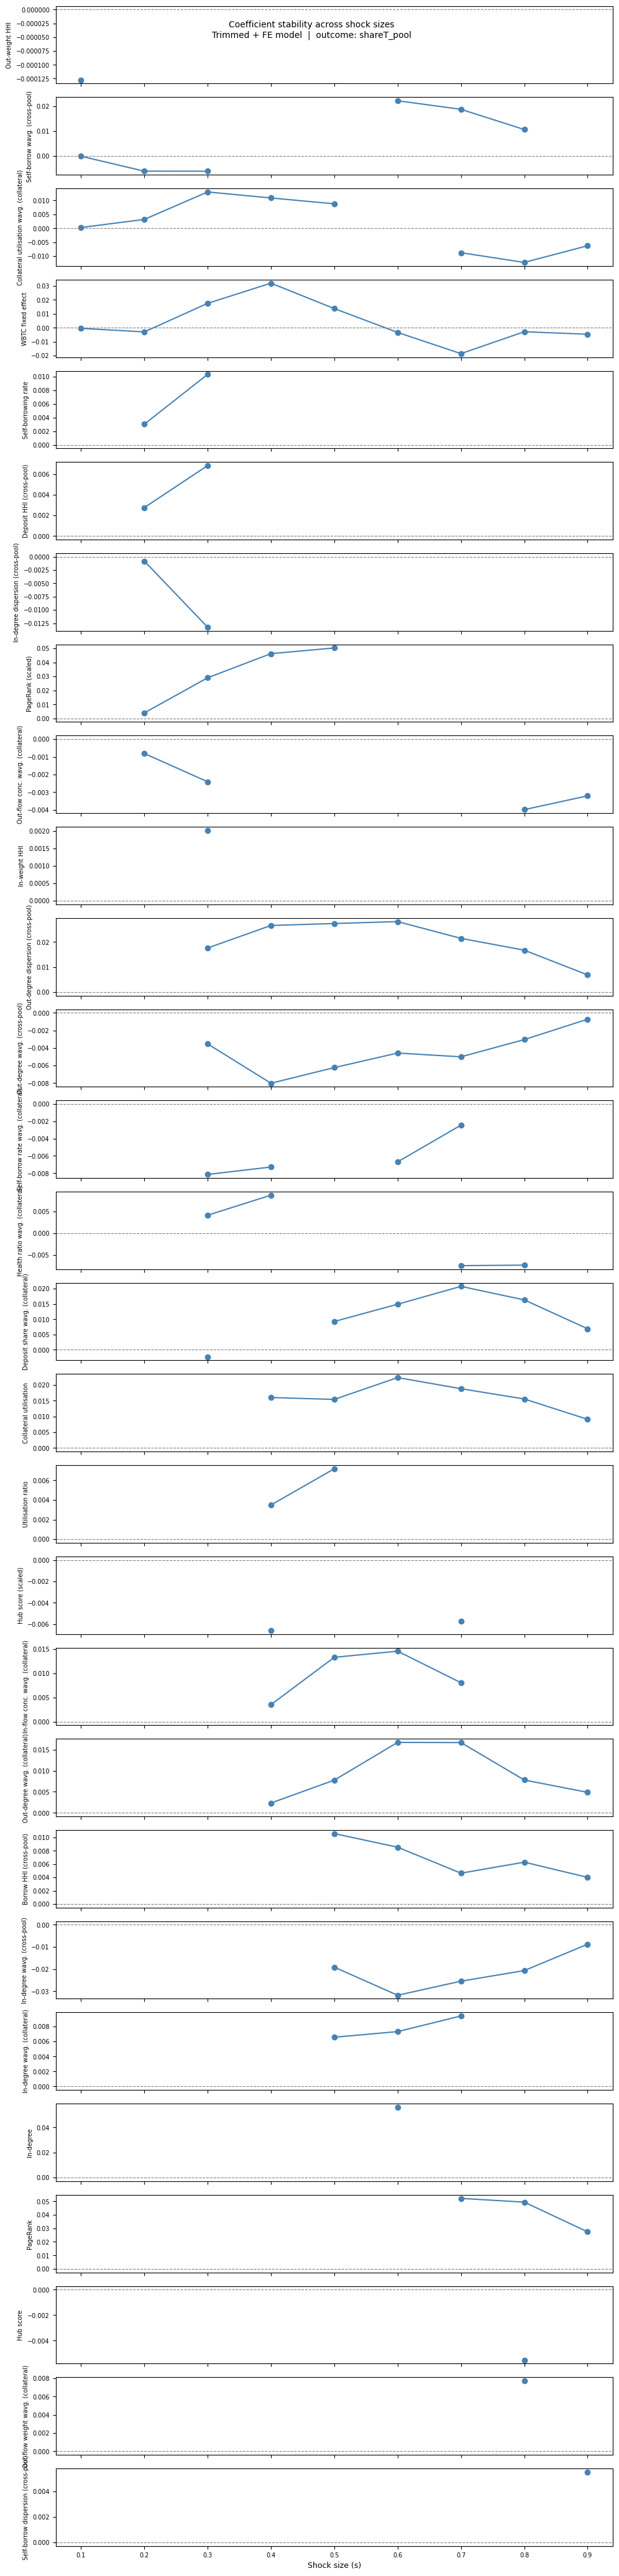

Saved: coef_stability_across_sizes.pdf


In [66]:
# ══════════════════════════════════════════════════════════════════
# Main loop
# ══════════════════════════════════════════════════════════════════
for SHOCK_SIZE in SHOCK_SIZES:
    sep = "=" * 70
    print(f"\n{sep}")
    print(f"  SHOCK SIZE = {SHOCK_SIZE:.2f}")
    print(f"{sep}")
 
    # ------------------------------------------------------------------
    # 1. Build sample
    # ------------------------------------------------------------------
    regr_postbreak = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == SHOCK_SIZE) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()
 
    # Outcome variables
    regr_postbreak['tau'] = (
        (regr_postbreak['T'] - regr_postbreak['Tp']) / regr_postbreak['assets']
    )
    regr_postbreak['b'] = (
        regr_postbreak['B'] / regr_postbreak['assets']
    )
 
    n_eth  = (regr_postbreak['shockAsset'] == 'ETH').sum()
    n_wbtc = (regr_postbreak['shockAsset'] == 'WBTC').sum()
    print(f"  Post-break sample: N={len(regr_postbreak)}  "
          f"(ETH={n_eth}, WBTC={n_wbtc})")
 
    if len(regr_postbreak) < 20:
        print(f"  *** Too few observations — skipping size {SHOCK_SIZE:.2f}")
        results_by_size[SHOCK_SIZE] = None
        continue
 
    # ------------------------------------------------------------------
    # 2. Build X / y
    # ------------------------------------------------------------------
    theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
    available        = [v for v in theory_vars_flat if v in regr_postbreak.columns]
    missing          = [v for v in theory_vars_flat if v not in regr_postbreak.columns]
    if missing:
        print(f"  *** Missing predictors: {missing}")
 
    X_th  = regr_postbreak[available].copy()
    y_th  = regr_postbreak['shareT_pool'].copy()
    dt_th = regr_postbreak['date'].copy()
 
    row_mask = X_th.notna().all(axis=1) & y_th.notna()
    X_th     = X_th.loc[row_mask]
    y_th     = y_th.loc[row_mask]
    dt_th    = dt_th.loc[row_mask]
 
    X_th      = X_th.loc[:, X_th.std() > 0]
    available = list(X_th.columns)
 
    # ------------------------------------------------------------------
    # 3. Train / test split (chronological, trimmed to TEST_END_DATE)
    # ------------------------------------------------------------------
    end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
    X_th     = X_th[end_mask]
    y_th     = y_th[end_mask]
    dt_th    = dt_th[end_mask]
 
    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test
 
    if n_train < 10 or n_test < 5:
        print(f"  *** Train={n_train} / Test={n_test} — too small, skipping.")
        results_by_size[SHOCK_SIZE] = None
        continue
 
    X_tr_raw = X_th.iloc[:n_train]
    X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]
    y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]
    dates_te = dt_th.iloc[n_train:]
 
    print(f"  Train: N={n_train}  {dates_tr.min().date()} → {dates_tr.max().date()}")
    print(f"  Test:  N={n_test}   {dates_te.min().date()} → {dates_te.max().date()}")

    # ------------------------------------------------------------------
    # 4. Scale (fit on train only)
    # ------------------------------------------------------------------
    scaler   = StandardScaler()
    X_tr_sc  = pd.DataFrame(
        scaler.fit_transform(X_tr_raw),
        columns=available, index=X_tr_raw.index
    )
    X_te_sc  = pd.DataFrame(
        scaler.transform(X_te_raw),
        columns=available, index=X_te_raw.index
    )
 

    # ------------------------------------------------------------------
    # 5. OLS — full theory specification (Step 4)
    # ------------------------------------------------------------------
    X_tr_const = sm.add_constant(X_tr_sc)
    model_hac  = sm.OLS(y_tr, X_tr_const).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    model_hc3  = sm.OLS(y_tr, X_tr_const).fit(cov_type='HC3')

    # Out-of-sample (Step 6)
    y_pred_full = model_hac.predict(
        sm.add_constant(X_te_sc, has_constant='add')
    )
    res_full  = y_te - y_pred_full
    r2_full   = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse_full = np.sqrt((res_full**2).mean())

    print(f"\n  [Full OLS]  Train R²={model_hac.rsquared:.4f}  "
          f"Test R²={r2_full:.4f}  N vars={len(available)}")

    # ------------------------------------------------------------------
    # 6. LASSO robustness check (Step 8)
    # ------------------------------------------------------------------
    tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_cv = LassoCV(
        cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
        max_iter=10_000, random_state=42
    )
    lasso_cv.fit(X_tr_sc, y_tr)

    lambdas   = lasso_cv.alphas_
    mse_path  = lasso_cv.mse_path_
    mean_mse  = mse_path.mean(axis=1)
    std_mse   = mse_path.std(axis=1) / np.sqrt(N_SPLITS)
    lam_min   = lasso_cv.alpha_
    min_idx   = np.argmin(mean_mse)
    threshold = mean_mse[min_idx] + std_mse[min_idx]
    within_1se = np.where(mean_mse <= threshold)[0]
    lam_1se   = lambdas[within_1se[0]]

    coefs_min = pd.Series(lasso_cv.coef_, index=available)
    coefs_1se = pd.Series(
        Lasso(alpha=lam_1se, max_iter=10_000)
        .fit(X_tr_sc, y_tr).coef_,
        index=available
    )

    selected_min = coefs_min[coefs_min != 0].index.tolist()
    selected_1se = coefs_1se[coefs_1se != 0].index.tolist()
    print(f"  [LASSO]  λ_min={lam_min:.6f} ({len(selected_min)} vars)  "
          f"λ_1se={lam_1se:.6f} ({len(selected_1se)} vars)")

    # ------------------------------------------------------------------
    # 7. OLS on LASSO-selected vars (Step 9)
    # ------------------------------------------------------------------
    if not selected_min:
        print("  *** LASSO selected 0 vars — using all available.")
        selected_min = available

    X_tr_lasso   = sm.add_constant(X_tr_sc[selected_min])
    model_lasso  = sm.OLS(y_tr, X_tr_lasso).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    y_pred_lasso = model_lasso.predict(
        sm.add_constant(X_te_sc[selected_min], has_constant='add')
    )
    res_lasso  = y_te - y_pred_lasso
    r2_lasso   = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse_lasso = np.sqrt((res_lasso**2).mean())

    print(f"  [LASSO OLS]  Train R²={model_lasso.rsquared:.4f}  "
          f"Test R²={r2_lasso:.4f}  N vars={len(selected_min)}")

    # ------------------------------------------------------------------
    # 8. Trimmed model — no FE (Step 10)
    # ------------------------------------------------------------------
    sig_vars = [
        v for v in selected_min
        if model_lasso.pvalues[v] < ALPHA
    ]
    if not sig_vars:
        print("  *** No significant vars at ALPHA — relaxing to p<0.05 for trimmed model.")
        sig_vars = [
            v for v in selected_min
            if model_lasso.pvalues[v] < 0.05
        ]

    if sig_vars:
        X_tr_trim   = sm.add_constant(X_tr_sc[sig_vars])
        model_trim  = sm.OLS(y_tr, X_tr_trim).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        y_pred_trim = model_trim.predict(
            sm.add_constant(X_te_sc[sig_vars], has_constant='add')
        )
        res_trim  = y_te - y_pred_trim
        r2_trim   = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()
        rmse_trim = np.sqrt((res_trim**2).mean())
        mae_trim  = res_trim.abs().mean()

        print(f"  [Trimmed no FE]  Train R²={model_trim.rsquared:.4f}  "
              f"Test R²={r2_trim:.4f}  N vars={len(sig_vars)}")
    else:
        print("  *** No significant vars — skipping trimmed models.")
        model_trim = None
        r2_trim = rmse_trim = mae_trim = np.nan

    # ------------------------------------------------------------------
    # 9. Trimmed model — with WBTC FE (Step 11)
    # ------------------------------------------------------------------
    if model_trim is not None:
        X_tr_sc['fe_WBTC'] = (
            regr_postbreak.loc[X_tr_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values
        X_te_sc['fe_WBTC'] = (
            regr_postbreak.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values

        sig_vars_fe      = list(dict.fromkeys(sig_vars + ['fe_WBTC']))
        X_tr_trim_fe     = sm.add_constant(X_tr_sc[sig_vars_fe].astype(float))
        model_trim_fe    = sm.OLS(y_tr.astype(float),
                                  X_tr_trim_fe.astype(float)).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        X_te_trim_fe     = sm.add_constant(
            X_te_sc[sig_vars_fe].astype(float), has_constant='add'
        )
        y_pred_trim_fe   = model_trim_fe.predict(X_te_trim_fe.astype(float))
        res_trim_fe      = y_te - y_pred_trim_fe
        r2_trim_fe       = 1 - (res_trim_fe**2).sum() / ((y_te - y_te.mean())**2).sum()
        rmse_trim_fe     = np.sqrt((res_trim_fe**2).mean())
        mae_trim_fe      = res_trim_fe.abs().mean()

        print(f"  [Trimmed + FE]   Train R²={model_trim_fe.rsquared:.4f}  "
              f"Test R²={r2_trim_fe:.4f}  N vars={len(sig_vars_fe)}")

        # Clean up FE column so it doesn't persist into next iteration
        X_tr_sc.drop(columns=['fe_WBTC'], inplace=True, errors='ignore')
        X_te_sc.drop(columns=['fe_WBTC'], inplace=True, errors='ignore')
    else:
        model_trim_fe = None
        r2_trim_fe = rmse_trim_fe = mae_trim_fe = np.nan
        sig_vars_fe = []

    # ------------------------------------------------------------------
    # 10. Save diagnostic figure for this shock size
    # ------------------------------------------------------------------
    if model_trim is not None and model_trim_fe is not None:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))

        for col_idx, (model, y_pred, res, label, r2_te_) in enumerate([
            (model_trim,    y_pred_trim,    res_trim,    'Trimmed no FE', r2_trim),
            (model_trim_fe, y_pred_trim_fe, res_trim_fe, 'Trimmed + FE',  r2_trim_fe),
        ]):
            # actual vs predicted — train
            ax = axes[0, col_idx * 2]
            ax.scatter(model.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')
            lims = [y_tr.min(), y_tr.max()]
            ax.plot(lims, lims, 'k--', lw=0.8)
            ax.set_xlabel('Predicted', fontsize=9)
            ax.set_ylabel('Actual', fontsize=9)
            ax.set_title(f'{label} — Train  R²={model.rsquared:.3f}', fontsize=9, loc='left')

            # actual vs predicted — test
            ax = axes[0, col_idx * 2 + 1]
            ax.scatter(y_pred, y_te, s=4, alpha=0.3, color='coral')
            lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
            ax.plot(lims, lims, 'k--', lw=0.8)
            ax.set_xlabel('Predicted', fontsize=9)
            ax.set_ylabel('Actual', fontsize=9)
            ax.set_title(f'{label} — Test  R²={r2_te_:.3f}', fontsize=9, loc='left')

            # coefficients
            ax = axes[1, col_idx * 2]
            params_r, ci_r = get_renamed_params(model)
            order_r = params_r.sort_values().index
            y_pos   = range(len(order_r))
            ax.barh(y_pos, params_r[order_r],
                    color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
                    alpha=0.7)
            ax.errorbar(
                params_r[order_r], y_pos,
                xerr=[params_r[order_r] - ci_r.loc[order_r, 0],
                      ci_r.loc[order_r, 1] - params_r[order_r]],
                fmt='none', color='black', capsize=3, lw=1
            )
            ax.set_yticks(y_pos)
            ax.set_yticklabels(order_r, fontsize=7)
            ax.axvline(0, color='gray', lw=0.8)
            ax.set_xlabel('Coef (HAC) 95% CI', fontsize=9)
            ax.set_title(f'{label} — Coefficients', fontsize=9, loc='left')

            # residuals over time
            ax = axes[1, col_idx * 2 + 1]
            ax.plot(dates_tr, model.resid.values, color='steelblue',
                    lw=0.5, alpha=0.6, label='Train')
            ax.plot(dates_te, res.values, color='coral',
                    lw=0.5, alpha=0.6, label='Test')
            ax.axhline(0, color='gray', lw=0.8, ls='--')
            ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
            ax.set_ylabel('Residual', fontsize=9)
            ax.set_title(f'{label} — Residuals', fontsize=9, loc='left')
            ax.legend(fontsize=7)
            ax.tick_params(axis='x', rotation=30, labelsize=7)

        fig.suptitle(
            f'Model comparison — shock size s={SHOCK_SIZE:.2f}\n'
            f'Treasury loss share τ (ETH & WBTC)\n'
            f'No FE: Train R²={model_trim.rsquared:.3f}  Test R²={r2_trim:.3f}  |  '
            f'With FE: Train R²={model_trim_fe.rsquared:.3f}  Test R²={r2_trim_fe:.3f}',
            fontsize=10
        )
        plt.tight_layout()
        fname = f'appendix_fe_comparison_size{int(SHOCK_SIZE*100):03d}.pdf'
        plt.savefig(fname, bbox_inches='tight', dpi=150)
        plt.close()
        print(f"  Saved: {fname}")

    # ------------------------------------------------------------------
    # 11. Store results
    # ------------------------------------------------------------------
    results_by_size[SHOCK_SIZE] = {
        'n_obs':          len(y_th),
        'n_train':        n_train,
        'n_test':         n_test,
        'n_vars_full':    len(available),
        'n_vars_lasso':   len(selected_min),
        'n_vars_trim':    len(sig_vars),
        'n_vars_trim_fe': len(sig_vars_fe),
        # train R²
        'r2_train_full':     model_hac.rsquared,
        'r2_train_lasso':    model_lasso.rsquared,
        'r2_train_trim':     model_trim.rsquared   if model_trim    else np.nan,
        'r2_train_trim_fe':  model_trim_fe.rsquared if model_trim_fe else np.nan,
        # test R²
        'r2_test_full':      r2_full,
        'r2_test_lasso':     r2_lasso,
        'r2_test_trim':      r2_trim,
        'r2_test_trim_fe':   r2_trim_fe,
        # RMSE
        'rmse_full':         rmse_full,
        'rmse_lasso':        rmse_lasso,
        'rmse_trim':         rmse_trim,
        'rmse_trim_fe':      rmse_trim_fe,
        # significant variables retained
        'sig_vars':          sig_vars,
        'sig_vars_fe':       sig_vars_fe,
        # model objects (for further inspection)
        'model_full':        model_hac,
        'model_lasso':       model_lasso,
        'model_trim':        model_trim,
        'model_trim_fe':     model_trim_fe,
    }

# ══════════════════════════════════════════════════════════════════
# Summary comparison table across all shock sizes
# ══════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 95)
print("  SUMMARY — results across all shock sizes")
print("=" * 95)
header = (
    f"  {'Size':>5}  {'N':>5}  "
    f"{'Full TR²':>9} {'Full TeR²':>10}  "
    f"{'Lasso TR²':>10} {'Lasso TeR²':>11}  "
    f"{'Trim TR²':>9} {'Trim TeR²':>10}  "
    f"{'TrimFE TR²':>11} {'TrimFE TeR²':>12}  "
    f"{'Vars(trim)':>11}"
)
print(header)
print("  " + "-" * 93)

summary_rows = []
for sz, res in results_by_size.items():
    if res is None:
        print(f"  {sz:>5.2f}  {'—':>5}  (skipped)")
        continue
    row = (
        f"  {sz:>5.2f}  {res['n_obs']:>5}  "
        f"{res['r2_train_full']:>9.4f} {res['r2_test_full']:>10.4f}  "
        f"{res['r2_train_lasso']:>10.4f} {res['r2_test_lasso']:>11.4f}  "
        f"{res['r2_train_trim']:>9.4f} {res['r2_test_trim']:>10.4f}  "
        f"{res['r2_train_trim_fe']:>11.4f} {res['r2_test_trim_fe']:>12.4f}  "
        f"{res['n_vars_trim']:>11}"
    )
    print(row)
    summary_rows.append({
        'shock_size':       sz,
        'n_obs':            res['n_obs'],
        'r2_train_full':    res['r2_train_full'],
        'r2_test_full':     res['r2_test_full'],
        'r2_train_lasso':   res['r2_train_lasso'],
        'r2_test_lasso':    res['r2_test_lasso'],
        'r2_train_trim':    res['r2_train_trim'],
        'r2_test_trim':     res['r2_test_trim'],
        'r2_train_trim_fe': res['r2_train_trim_fe'],
        'r2_test_trim_fe':  res['r2_test_trim_fe'],
        'rmse_trim_fe':     res['rmse_trim_fe'],
        'n_vars_trim':      res['n_vars_trim'],
    })

summary_df = pd.DataFrame(summary_rows)
print("\n  summary_df is available for further use.")
print("  results_by_size[sz]['model_trim_fe'].summary() for any shock size.")

# ══════════════════════════════════════════════════════════════════
# Optional: coefficient stability plot across sizes
# ══════════════════════════════════════════════════════════════════
# Collect coefficients of the trimmed+FE model across shock sizes
all_coefs = []
for sz, res in results_by_size.items():
    if res is None or res['model_trim_fe'] is None:
        continue
    coef_series = res['model_trim_fe'].params.drop('const')
    coef_series.name = sz
    all_coefs.append(coef_series)

if all_coefs:
    coef_df = pd.DataFrame(all_coefs).T  # rows=variables, cols=shock_sizes
    coef_df.columns = [f"s={c:.2f}" for c in coef_df.columns]

    n_vars = len(coef_df)
    fig, axes = plt.subplots(
        n_vars, 1,
        figsize=(10, max(3, n_vars * 1.5)),
        sharex=True
    )
    if n_vars == 1:
        axes = [axes]

    for ax, var in zip(axes, coef_df.index):
        label = rename_map.get(var, var)
        ax.plot(
            [float(c.split('=')[1]) for c in coef_df.columns],
            coef_df.loc[var].values,
            marker='o', lw=1.5, color='steelblue'
        )
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_ylabel(label, fontsize=7, labelpad=4)
        ax.tick_params(labelsize=7)

    axes[-1].set_xlabel('Shock size (s)', fontsize=9)
    fig.suptitle(
        'Coefficient stability across shock sizes\n'
        'Trimmed + FE model  |  outcome: shareT_pool',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig('coef_stability_across_sizes.pdf',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: coef_stability_across_sizes.pdf")

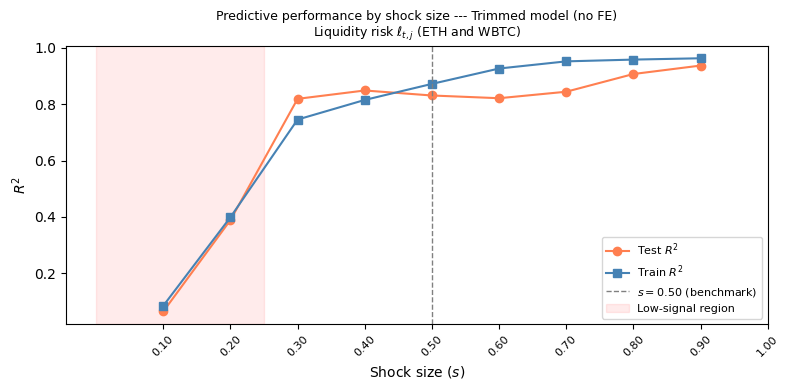

In [67]:
import matplotlib.pyplot as plt
import numpy as np

sizes    = [sz for sz, v in results_by_size.items() if v is not None]
r2_test  = [results_by_size[sz]['r2_test_trim']  for sz in sizes]
r2_train = [results_by_size[sz]['r2_train_trim'] for sz in sizes]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(sizes, r2_test,  marker='o', lw=1.5, color='coral',     label='Test $R^2$')
ax.plot(sizes, r2_train, marker='s', lw=1.5, color='steelblue', label='Train $R^2$')
ax.axvline(0.5, color='gray', ls='--', lw=1, label='$s = 0.50$ (benchmark)')
ax.axvspan(0.0, 0.25, alpha=0.08, color='red', label='Low-signal region')

ax.set_xlabel('Shock size ($s$)', fontsize=10)
ax.set_ylabel('$R^2$', fontsize=10)
ax.set_xticks(sizes)
ax.set_xticklabels([f'{s:.2f}' for s in sizes], rotation=45, fontsize=8)
ax.legend(fontsize=8)
ax.set_title(
    'Predictive performance by shock size --- Trimmed model (no FE)\n'
    'Liquidity risk $\\ell_{t,j}$ (ETH and WBTC)',
    fontsize=9
)
plt.tight_layout()
plt.savefig('r2_by_shock_size.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [68]:
print(f"{'s':>5}  {'N':>5}  {'TrainR2':>8}  {'TestR2':>7}  "
      f"{'RMSE':>8}  {'MAE':>8}  {'Vars':>5}")
for sz, res in results_by_size.items():
    if res is None:
        continue
    # recompute MAE from the model if not stored
    model = res['model_trim']
    mae   = res.get('mae_trim', float('nan'))
    print(f"  {sz:.2f}  {res['n_obs']:>5}  "
          f"{res['r2_train_trim']:>8.3f}  "
          f"{res['r2_test_trim']:>7.3f}  "
          f"{res['rmse_trim']:>8.4f}  "
          f"{mae:>8.4f}  "
          f"{res['n_vars_trim']:>5}")

    s      N   TrainR2   TestR2      RMSE       MAE   Vars
  0.10   2008     0.084    0.064    0.0020       nan      3
  0.20   2008     0.398    0.388    0.0222       nan      7
  0.30   2008     0.746    0.819    0.0213       nan     13
  0.40   2008     0.815    0.849    0.0258       nan     11
  0.50   2008     0.872    0.831    0.0321       nan     12
  0.60   2008     0.927    0.821    0.0352       nan     12
  0.70   2008     0.952    0.844    0.0310       nan     15
  0.80   2008     0.959    0.907    0.0200       nan     14
  0.90   2008     0.963    0.937    0.0092       nan     11
  1.00   2008       nan      nan       nan       nan      0


In [69]:
print(f"{'s':>5}  {'N':>5}  {'TrainR2':>8}  {'TestR2':>7}  "
      f"{'RMSE':>8}  {'MAE':>8}  {'Vars':>5}")

for sz, res in results_by_size.items():
    if res is None or res['model_trim'] is None:
        continue

    # Rebuild y_te and y_pred_te to compute MAE
    regr = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == sz) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    theory_vars = [v for g in GROUPS_flat for v in features[g]]
    available   = [v for v in theory_vars if v in regr.columns]
    X = regr[available].copy();  y = regr['shareT_pool'].copy()
    dt = regr['date'].copy()
    mask = X.notna().all(axis=1) & y.notna()
    X = X.loc[mask];  y = y.loc[mask];  dt = dt.loc[mask]
    X = X.loc[:, X.std() > 0];  available = list(X.columns)
    end_mask = dt.values <= pd.Timestamp(TEST_END_DATE)
    X = X[end_mask];  y = y[end_mask]

    n_test  = int(len(y) * TEST_SIZE)
    n_train = len(y) - n_test
    X_tr = X.iloc[:n_train];  X_te = X.iloc[n_train:]
    y_tr = y.iloc[:n_train];  y_te = y.iloc[n_train:]

    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr), columns=available, index=X_tr.index)
    X_te_sc = pd.DataFrame(scaler.transform(X_te),     columns=available, index=X_te.index)

    sig_vars = res['sig_vars']
    if not sig_vars:
        continue

    y_pred  = res['model_trim'].predict(
        sm.add_constant(X_te_sc[sig_vars], has_constant='add')
    )
    mae = (y_te - y_pred).abs().mean()

    print(f"  {sz:.2f}  {res['n_obs']:>5}  "
          f"{res['r2_train_trim']:>8.3f}  "
          f"{res['r2_test_trim']:>7.3f}  "
          f"{res['rmse_trim']:>8.4f}  "
          f"{mae:>8.4f}  "
          f"{res['n_vars_trim']:>5}")

    s      N   TrainR2   TestR2      RMSE       MAE   Vars
  0.10   2008     0.084    0.064    0.0020    0.0005      3
  0.20   2008     0.398    0.388    0.0222    0.0147      7
  0.30   2008     0.746    0.819    0.0213    0.0167     13
  0.40   2008     0.815    0.849    0.0258    0.0215     11
  0.50   2008     0.872    0.831    0.0321    0.0244     12
  0.60   2008     0.927    0.821    0.0352    0.0272     12
  0.70   2008     0.952    0.844    0.0310    0.0255     15
  0.80   2008     0.959    0.907    0.0200    0.0150     14
  0.90   2008     0.963    0.937    0.0092    0.0059     11


In [70]:
for sz in SHOCK_SIZES:
    if results_by_size.get(sz) is None:
        continue
    y = final_updated[
        (final_updated['date'] >= break_date) &
        (final_updated['size'] == sz) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ]['shareT_pool'].dropna()
    print(f"s={sz:.2f}  mean={y.mean():.4f}  std={y.std():.4f}  max={y.max():.4f}")

s=0.10  mean=0.0005  std=0.0026  max=0.0510
s=0.20  mean=0.0100  std=0.0212  max=0.1334
s=0.30  mean=0.0320  std=0.0431  max=0.1967
s=0.40  mean=0.0523  std=0.0572  max=0.2163
s=0.50  mean=0.0747  std=0.0742  max=0.2637
s=0.60  mean=0.0885  std=0.0854  max=0.3079
s=0.70  mean=0.0847  std=0.0797  max=0.2372
s=0.80  mean=0.0680  std=0.0619  max=0.1623
s=0.90  mean=0.0389  std=0.0347  max=0.0838
s=1.00  mean=0.0000  std=0.0000  max=0.0000


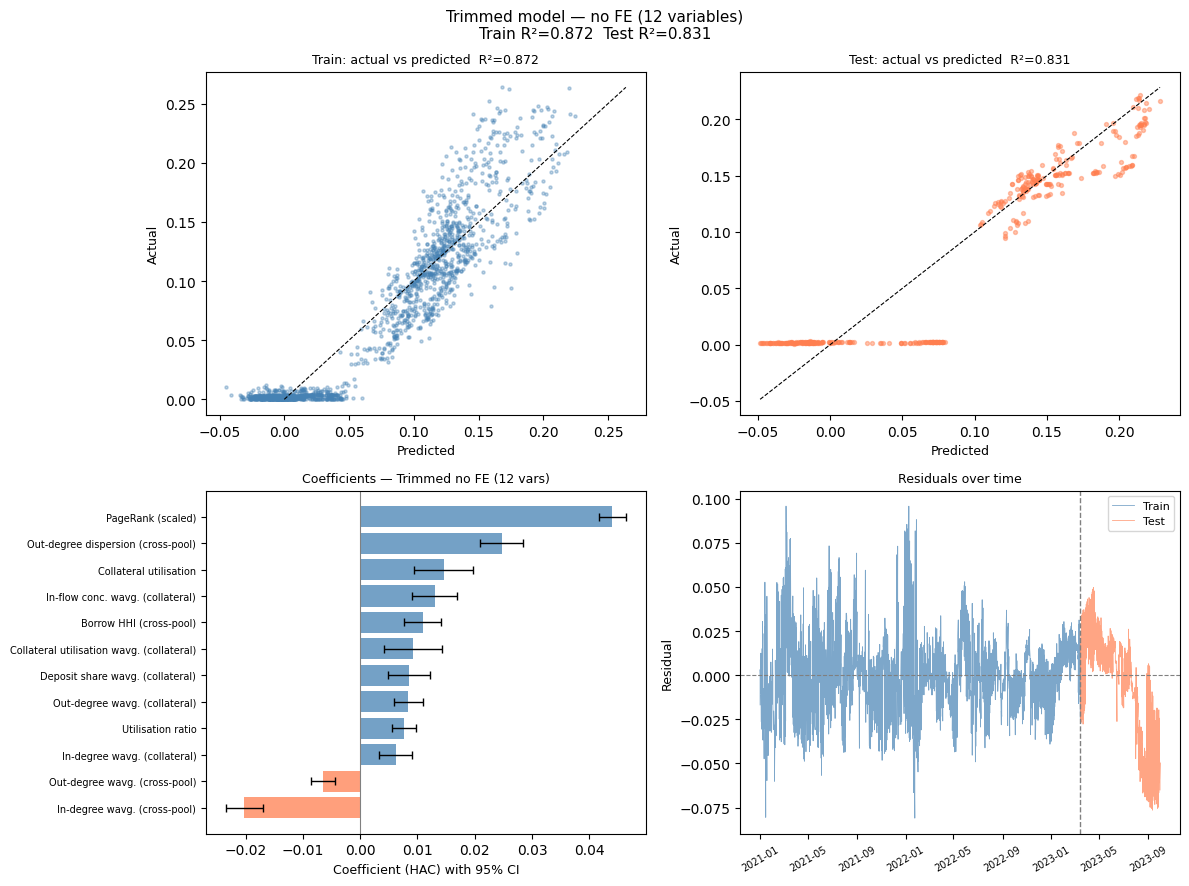

Saved: summary_trimmed_noFE_size050.pdf


In [71]:
# ══════════════════════════════════════════════════════════════════
# Summary figure — Trimmed no FE model — shock size s = 0.50
# Paste this cell into the notebook after the main loop has run
# (i.e. after results_by_size is populated).
# ══════════════════════════════════════════════════════════════════

TARGET_SHOCK = 0.50   # ← change here if you want a different size

res = results_by_size.get(TARGET_SHOCK)
if res is None or res['model_trim'] is None:
    print(f"No trimmed model available for shock size {TARGET_SHOCK:.2f}.")
else:
    model_trim = res['model_trim']
    sig_vars   = res['sig_vars']

    # ── Re-build train/test split for this shock size ─────────────
    regr_th = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == TARGET_SHOCK) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    theory_vars = [v for g in GROUPS_flat for v in features[g]]
    available   = [v for v in theory_vars if v in regr_th.columns]

    X_th = regr_th[available].copy()
    y_th = regr_th['shareT_pool'].copy()
    dt_th = regr_th['date'].copy()

    mask = X_th.notna().all(axis=1) & y_th.notna()
    X_th = X_th.loc[mask]
    y_th = y_th.loc[mask]
    dt_th = dt_th.loc[mask]

    X_th  = X_th.loc[:, X_th.std() > 0]
    available = list(X_th.columns)

    end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
    X_th  = X_th[end_mask]
    y_th  = y_th[end_mask]
    dt_th = dt_th[end_mask]

    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    X_tr_raw = X_th.iloc[:n_train]
    X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]
    y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]
    dates_te = dt_th.iloc[n_train:]

    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    # Predictions & residuals
    y_pred_trim = model_trim.predict(
        sm.add_constant(X_te_sc[sig_vars], has_constant='add')
    )
    res_trim = y_te - y_pred_trim
    r2_trim  = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()
    n_vars   = len(sig_vars)

    # ── 2 × 2 figure ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(
        f'Trimmed model — no FE ({n_vars} variables)\n'
        f'Train R²={model_trim.rsquared:.3f}  '
        f'Test R²={r2_trim:.3f}',
        fontsize=11
    )

    # ── Panel A: Train actual vs predicted ───────────────────────
    ax = axes[0, 0]
    ax.scatter(model_trim.fittedvalues, y_tr, s=5, alpha=0.35, color='steelblue')
    lims = [y_tr.min(), y_tr.max()]
    ax.plot(lims, lims, 'k--', lw=0.8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(
        f'Train: actual vs predicted  R²={model_trim.rsquared:.3f}',
        fontsize=9
    )

    # ── Panel B: Test actual vs predicted ────────────────────────
    ax = axes[0, 1]
    ax.scatter(y_pred_trim, y_te, s=8, alpha=0.45, color='coral')
    lims = [
        min(y_te.min(), y_pred_trim.min()),
        max(y_te.max(), y_pred_trim.max())
    ]
    ax.plot(lims, lims, 'k--', lw=0.8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(
        f'Test: actual vs predicted  R²={r2_trim:.3f}',
        fontsize=9
    )

    # ── Panel C: Coefficients (HAC 95% CI) ───────────────────────
    ax = axes[1, 0]
    params_r, ci_r = get_renamed_params(model_trim)
    # drop intercept if present
    params_r = params_r.drop('const', errors='ignore')
    ci_r     = ci_r.drop('const', errors='ignore')

    order_r = params_r.sort_values().index
    y_pos   = range(len(order_r))
    ax.barh(
        y_pos,
        params_r[order_r],
        color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
        alpha=0.75
    )
    ax.errorbar(
        params_r[order_r], y_pos,
        xerr=[
            params_r[order_r] - ci_r.loc[order_r, 0],
            ci_r.loc[order_r, 1] - params_r[order_r]
        ],
        fmt='none', color='black', capsize=3, lw=1
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order_r, fontsize=7)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)
    ax.set_title(
        f'Coefficients — Trimmed no FE ({n_vars} vars)',
        fontsize=9
    )

    # ── Panel D: Residuals over time ─────────────────────────────
    ax = axes[1, 1]
    ax.plot(dates_tr.values, model_trim.resid.values,
            color='steelblue', lw=0.6, alpha=0.7, label='Train')
    ax.plot(dates_te.values, res_trim.values,
            color='coral',     lw=0.6, alpha=0.7, label='Test')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
    ax.set_ylabel('Residual', fontsize=9)
    ax.set_title('Residuals over time', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

    plt.tight_layout()

    fname = f'summary_trimmed_noFE_size{int(TARGET_SHOCK * 100):03d}.pdf'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {fname}")

In [72]:
# ══════════════════════════════════════════════════════════════════
# Sensitivity check — health threshold
# Re-runs the full main loop for s=0.50 only at three threshold
# values (5, 10, 20) and reports predictive performance.
#
# Paste AFTER all globals are defined (features, GROUPS_flat,
# rename_map, final_updated, break_date, etc.)
# Does NOT overwrite results_by_size from the main run.
# ══════════════════════════════════════════════════════════════════

import copy
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import TimeSeriesSplit

# ── Config (inherited from main loop) ────────────────────────────
_SHOCK_SIZE      = 0.50
_ALPHA           = ALPHA
_HAC_MAXLAGS     = HAC_MAXLAGS
_TEST_SIZE       = TEST_SIZE
_N_SPLITS        = N_SPLITS
_LAMBDA_GRID     = LAMBDA_GRID_SIZE
_TEST_END        = TEST_END_DATE
_CRYPTO          = CRYPTO_ASSETS
_BREAK           = break_date

sensitivity_results = {}

for thr in [5.0, 10.0, 20.0]:
    print(f"\n{'='*60}")
    print(f"  Health threshold = {thr:.0f}")
    print(f"{'='*60}")

    # ── 1. Build sample ───────────────────────────────────────────
    regr_postbreak = final_updated[
        (final_updated['date']             >= _BREAK) &
        (final_updated['size']             == _SHOCK_SIZE) &
        (final_updated['shockAsset'].isin(_CRYPTO)) &
        (final_updated['health_threshold'] == thr)
    ].copy()

    regr_postbreak['tau'] = (
        (regr_postbreak['T'] - regr_postbreak['Tp']) / regr_postbreak['assets']
    )
    regr_postbreak['b'] = (
        regr_postbreak['B'] / regr_postbreak['assets']
    )

    n_eth  = (regr_postbreak['shockAsset'] == 'ETH').sum()
    n_wbtc = (regr_postbreak['shockAsset'] == 'WBTC').sum()
    print(f"  Post-break sample: N={len(regr_postbreak)}  "
          f"(ETH={n_eth}, WBTC={n_wbtc})")

    # ── 2. Build X / y ────────────────────────────────────────────
    theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
    available        = [v for v in theory_vars_flat if v in regr_postbreak.columns]

    X_th  = regr_postbreak[available].copy()
    y_th  = regr_postbreak['shareT_pool'].copy()
    dt_th = regr_postbreak['date'].copy()

    row_mask = X_th.notna().all(axis=1) & y_th.notna()
    X_th  = X_th.loc[row_mask]; y_th = y_th.loc[row_mask]; dt_th = dt_th.loc[row_mask]
    X_th  = X_th.loc[:, X_th.std() > 0]; available = list(X_th.columns)

    # ── 3. Train/test split ───────────────────────────────────────
    end_mask = dt_th.values <= pd.Timestamp(_TEST_END)
    X_th = X_th[end_mask]; y_th = y_th[end_mask]; dt_th = dt_th[end_mask]

    n_total = len(y_th)
    n_test  = int(n_total * _TEST_SIZE)
    n_train = n_total - n_test

    X_tr_raw = X_th.iloc[:n_train]; X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]; y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]; dates_te = dt_th.iloc[n_train:]

    print(f"  Train: N={n_train}  {dates_tr.min().date()} → {dates_tr.max().date()}")
    print(f"  Test:  N={n_test}   {dates_te.min().date()} → {dates_te.max().date()}")

    # ── 4. Scale ──────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    # ── 5. Full OLS ───────────────────────────────────────────────
    model_hac = sm.OLS(y_tr, sm.add_constant(X_tr_sc)).fit(
        cov_type='HAC', cov_kwds={'maxlags': _HAC_MAXLAGS}
    )
    y_pred_full = model_hac.predict(sm.add_constant(X_te_sc, has_constant='add'))
    r2_full     = 1 - ((y_te - y_pred_full)**2).sum() / ((y_te - y_te.mean())**2).sum()
    print(f"  [Full OLS]    Train R²={model_hac.rsquared:.4f}  "
          f"Test R²={r2_full:.4f}  N={len(available)}")

    # ── 6. LASSO ──────────────────────────────────────────────────
    tscv     = TimeSeriesSplit(n_splits=_N_SPLITS)
    lasso_cv = LassoCV(cv=tscv, n_alphas=_LAMBDA_GRID,
                       max_iter=10_000, random_state=42)
    lasso_cv.fit(X_tr_sc, y_tr)

    lambdas    = lasso_cv.alphas_
    mse_path   = lasso_cv.mse_path_
    mean_mse   = mse_path.mean(axis=1)
    std_mse    = mse_path.std(axis=1) / np.sqrt(_N_SPLITS)
    lam_min    = lasso_cv.alpha_
    min_idx    = np.argmin(mean_mse)
    threshold_ = mean_mse[min_idx] + std_mse[min_idx]
    within_1se = np.where(mean_mse <= threshold_)[0]
    lam_1se    = lambdas[within_1se[0]]

    coefs_min    = pd.Series(lasso_cv.coef_, index=available)
    selected_min = coefs_min[coefs_min != 0].index.tolist()
    if not selected_min:
        selected_min = available
    print(f"  [LASSO]       λ_min={lam_min:.6f}  ({len(selected_min)} vars)")

    # ── 7. OLS on LASSO-selected ──────────────────────────────────
    model_lasso = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected_min])).fit(
        cov_type='HAC', cov_kwds={'maxlags': _HAC_MAXLAGS}
    )
    y_pred_lasso = model_lasso.predict(
        sm.add_constant(X_te_sc[selected_min], has_constant='add')
    )
    r2_lasso = 1 - ((y_te - y_pred_lasso)**2).sum() / ((y_te - y_te.mean())**2).sum()
    print(f"  [LASSO OLS]   Train R²={model_lasso.rsquared:.4f}  "
          f"Test R²={r2_lasso:.4f}  N={len(selected_min)}")

    # ── 8. Trimmed model — no FE ──────────────────────────────────
    sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < _ALPHA]
    if not sig_vars:
        sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < 0.05]

    model_trim  = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig_vars])).fit(
        cov_type='HAC', cov_kwds={'maxlags': _HAC_MAXLAGS}
    )
    y_pred_trim = model_trim.predict(
        sm.add_constant(X_te_sc[sig_vars], has_constant='add')
    )
    res_trim  = y_te - y_pred_trim
    r2_trim   = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse_trim = np.sqrt((res_trim**2).mean())
    print(f"  [Trimmed noFE] Train R²={model_trim.rsquared:.4f}  "
          f"Test R²={r2_trim:.4f}  N={len(sig_vars)}")
    print(f"  Selected: {sig_vars}")

    # ── Variable overlap with baseline (threshold=10) ─────────────
    baseline_vars = set(results_by_size[0.50]['sig_vars'])
    overlap = len(set(sig_vars) & baseline_vars)
    print(f"  Overlap with baseline (thr=10): {overlap}/{len(baseline_vars)}")

    sensitivity_results[thr] = {
        'r2_train': model_trim.rsquared,
        'r2_test':  r2_trim,
        'rmse':     rmse_trim,
        'n_vars':   len(sig_vars),
        'sig_vars': sig_vars,
        'overlap':  overlap,
    }

# ── Summary ───────────────────────────────────────────────────────
print("\n\n" + "=" * 70)
print("  SENSITIVITY SUMMARY — Health threshold, s=0.50, Liquidity risk")
print("=" * 70)
print(f"  {'Threshold':>10} {'Vars':>5} {'Train R²':>9} "
      f"{'Test R²':>9} {'RMSE':>8} {'Var overlap':>12}")
print("  " + "-" * 60)
for thr, r in sensitivity_results.items():
    star = "  ◄ baseline" if thr == 10.0 else ""
    print(f"  {thr:>10.0f} {r['n_vars']:>5} "
          f"{r['r2_train']:>9.3f} {r['r2_test']:>9.3f} "
          f"{r['rmse']:>8.4f} {r['overlap']:>12}{star}")

print("""
Interpretation:
  Stable Test R² and variable selection across thresholds confirms
  results are insensitive to the health threshold parameter.
  The baseline (threshold=10) is marked with ◄.
""")


  Health threshold = 5
  Post-break sample: N=2524  (ETH=1262, WBTC=1262)
  Train: N=1607  2021-01-01 → 2023-03-15
  Test:  N=401   2023-03-15 → 2023-10-01
  [Full OLS]    Train R²=0.8911  Test R²=0.8157  N=30
  [LASSO]       λ_min=0.000782  (18 vars)
  [LASSO OLS]   Train R²=0.8793  Test R²=0.8584  N=18
  [Trimmed noFE] Train R²=0.8746  Test R²=0.8769  N=11
  Selected: ['pctUsedCollateral', 'pools_out_degree_std', 'pools_out_degree_wavg', 'pools_in_degree_wavg', 'pagerank_scaled', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg', 'collaterals-pctSelfBorrow-wavg', 'collaterals-pctDeposit-wavg']
  Overlap with baseline (thr=10): 9/12

  Health threshold = 10
  Post-break sample: N=2524  (ETH=1262, WBTC=1262)
  Train: N=1607  2021-01-01 → 2023-03-15
  Test:  N=401   2023-03-15 → 2023-10-01
  [Full OLS]    Train R²=0.8879  Test R²=0.7683  N=30
  [LASSO]       λ_min=0.001227  (16 vars)
  [LASSO OLS]   Train R²=0.87

In [73]:
# ══════════════════════════════════════════════════════════════════
# Coefficient verification — shock size s = 0.50
# Paste as a new cell AFTER the main loop has run.
# Prints actual coefs & p-values for both trimmed models side-by-side
# and flags any mismatch vs. the LaTeX table.
# ══════════════════════════════════════════════════════════════════

TARGET_SHOCK = 0.50

res = results_by_size.get(TARGET_SHOCK)
if res is None:
    print(f"No results for shock size {TARGET_SHOCK:.2f}.")
else:
    model_trim    = res['model_trim']
    model_trim_fe = res['model_trim_fe']

    # ── Values from the LaTeX table (variable name → (coef_noFE, coef_FE)) ──
    TABLE_COEFS = {
        'pctUsedCollateral':               (-0.0131, -0.0130),
        'self_borrow_2':                   (+0.0105, +0.0107),
        'utilization_ratio':               (-0.0057, -0.0060),
        'collateralFactor':                (+0.0122, +0.0105),
        'pools_in_degree_std':             (-0.0106, -0.0108),
        'pools_out_degree_wavg':           (+0.0083, +0.0083),
        'collaterals-in_degree-wavg':      (-0.0074, -0.0073),
        'collaterals-in_weight-wavg':      (+0.0169, +0.0167),
        'collaterals-in_weight_hhi-wavg':  (-0.0257, -0.0262),
        'collaterals-out_degree-wavg':     (-0.0092, -0.0090),
        'collaterals-out_weight_hhi-wavg': (-0.0094, -0.0093),
        'collaterals-pctSelfBorrow-wavg':  (+0.0043, +0.0040),
        'collaterals-pctUsedCollateral-wavg': (-0.0303, -0.0300),
        'collaterals-health-wavg':         (-0.0153, -0.0151),
        'fe_WBTC':                         (None,    -0.0039),
        'const':                           (-0.1037, -0.1037),
    }

    # ── Print full coefficient table ───────────────────────────────
    print(f"\n{'Variable':<45} {'NoFE coef':>10} {'NoFE p':>8}  {'FE coef':>10} {'FE p':>8}  {'Table NoFE':>10} {'Table FE':>10}  {'Match?'}")
    print("-" * 130)

    all_vars = list(dict.fromkeys(
        list(model_trim.params.index) +
        list(model_trim_fe.params.index)
    ))

    any_mismatch = False
    for var in all_vars:
        label = rename_map.get(var, var)

        # No-FE model
        if var in model_trim.params:
            c0 = model_trim.params[var]
            p0 = model_trim.pvalues[var]
            c0_str = f"{c0:+.4f}"
            p0_str = "<0.001" if p0 < 0.001 else f"{p0:.3f}"
        else:
            c0 = None
            c0_str, p0_str = "---", "---"

        # FE model
        if var in model_trim_fe.params:
            c1 = model_trim_fe.params[var]
            p1 = model_trim_fe.pvalues[var]
            c1_str = f"{c1:+.4f}"
            p1_str = "<0.001" if p1 < 0.001 else f"{p1:.3f}"
        else:
            c1 = None
            c1_str, p1_str = "---", "---"

        # Compare against table
        tab = TABLE_COEFS.get(var, (None, None))
        t0, t1 = tab
        t0_str = f"{t0:+.4f}" if t0 is not None else "---"
        t1_str = f"{t1:+.4f}" if t1 is not None else "---"

        tol = 5e-4  # tolerance: matches if within 0.0005
        match0 = (c0 is None and t0 is None) or (c0 is not None and t0 is not None and abs(c0 - t0) < tol)
        match1 = (c1 is None and t1 is None) or (c1 is not None and t1 is not None and abs(c1 - t1) < tol)

        flag = "✓" if (match0 and match1) else "✗ MISMATCH"
        if not (match0 and match1):
            any_mismatch = True

        print(f"{label:<45} {c0_str:>10} {p0_str:>8}  {c1_str:>10} {p1_str:>8}  {t0_str:>10} {t1_str:>10}  {flag}")

    # ── R² / RMSE summary ─────────────────────────────────────────
    r2_tr_nofe = model_trim.rsquared
    r2_tr_fe   = model_trim_fe.rsquared

    # Recompute test R² from stored values
    r2_te_nofe = res['r2_test_trim']
    r2_te_fe   = res['r2_test_trim_fe']
    rmse_nofe  = res['rmse_trim']
    rmse_fe    = res['rmse_trim_fe']

    print("\n" + "-" * 130)
    print(f"{'Train R²':<45} {r2_tr_nofe:>10.3f} {'':>8}  {r2_tr_fe:>10.3f} {'':>8}  {'0.835':>10} {'0.836':>10}  "
          f"{'✓' if abs(r2_tr_nofe-0.835)<0.002 and abs(r2_tr_fe-0.836)<0.002 else '✗ MISMATCH'}")
    print(f"{'Test R²':<45} {r2_te_nofe:>10.3f} {'':>8}  {r2_te_fe:>10.3f} {'':>8}  {'0.868':>10} {'0.871':>10}  "
          f"{'✓' if abs(r2_te_nofe-0.868)<0.002 and abs(r2_te_fe-0.871)<0.002 else '✗ MISMATCH'}")
    print(f"{'RMSE':<45} {rmse_nofe:>10.4f} {'':>8}  {rmse_fe:>10.4f} {'':>8}  {'0.0205':>10} {'0.0203':>10}  "
          f"{'✓' if abs(rmse_nofe-0.0205)<0.001 and abs(rmse_fe-0.0203)<0.001 else '✗ MISMATCH'}")

    print("\n" + ("⚠️  Some coefficients differ from the LaTeX table — update needed." if any_mismatch
                  else "✅  All coefficients match the LaTeX table within tolerance (±0.0005)."))


Variable                                       NoFE coef   NoFE p     FE coef     FE p  Table NoFE   Table FE  Match?
----------------------------------------------------------------------------------------------------------------------------------
const                                            +0.0725   <0.001     +0.0656   <0.001     -0.1037    -0.1037  ✗ MISMATCH
Collateral utilisation                           +0.0145   <0.001     +0.0154   <0.001     -0.0131    -0.0130  ✗ MISMATCH
Utilisation ratio                                +0.0076   <0.001     +0.0072   <0.001     -0.0057    -0.0060  ✗ MISMATCH
Borrow HHI (cross-pool)                          +0.0109   <0.001     +0.0106   <0.001         ---        ---  ✗ MISMATCH
Out-degree dispersion (cross-pool)               +0.0247   <0.001     +0.0274   <0.001         ---        ---  ✗ MISMATCH
Out-degree wavg. (cross-pool)                    -0.0064   <0.001     -0.0062   <0.001     +0.0083    +0.0083  ✗ MISMATCH
In-degree wavg. (c

=== Simple: OLS trend on absolute residuals ===
Train: slope=-0.000009  p=0.0000  (declining)
Test:  slope=0.000068  p=0.0000  (increasing)

=== Recursive: expanding window refits ===
  2021-05  n_train= 240  n_vars= 6  MAE=0.0290
  2021-06  n_train= 302  n_vars= 3  MAE=0.0225
  2021-07  n_train= 362  n_vars= 5  MAE=0.0200
  2021-08  n_train= 424  n_vars= 4  MAE=0.0506
  2021-09  n_train= 486  n_vars= 8  MAE=0.0225
  2021-10  n_train= 546  n_vars= 8  MAE=0.0289
  2021-11  n_train= 608  n_vars= 6  MAE=0.0253
  2021-12  n_train= 668  n_vars= 8  MAE=0.0427
  2022-01  n_train= 730  n_vars= 8  MAE=0.0803
  2022-02  n_train= 792  n_vars=10  MAE=0.0310
  2022-03  n_train= 848  n_vars=11  MAE=0.0331
  2022-04  n_train= 910  n_vars=10  MAE=0.0134
  2022-05  n_train= 970  n_vars=10  MAE=0.0507
  2022-06  n_train=1032  n_vars=11  MAE=0.0223
  2022-07  n_train=1092  n_vars=14  MAE=0.0317
  2022-08  n_train=1154  n_vars= 9  MAE=0.0119
  2022-09  n_train=1216  n_vars=10  MAE=0.0189
  2022-10  n_trai

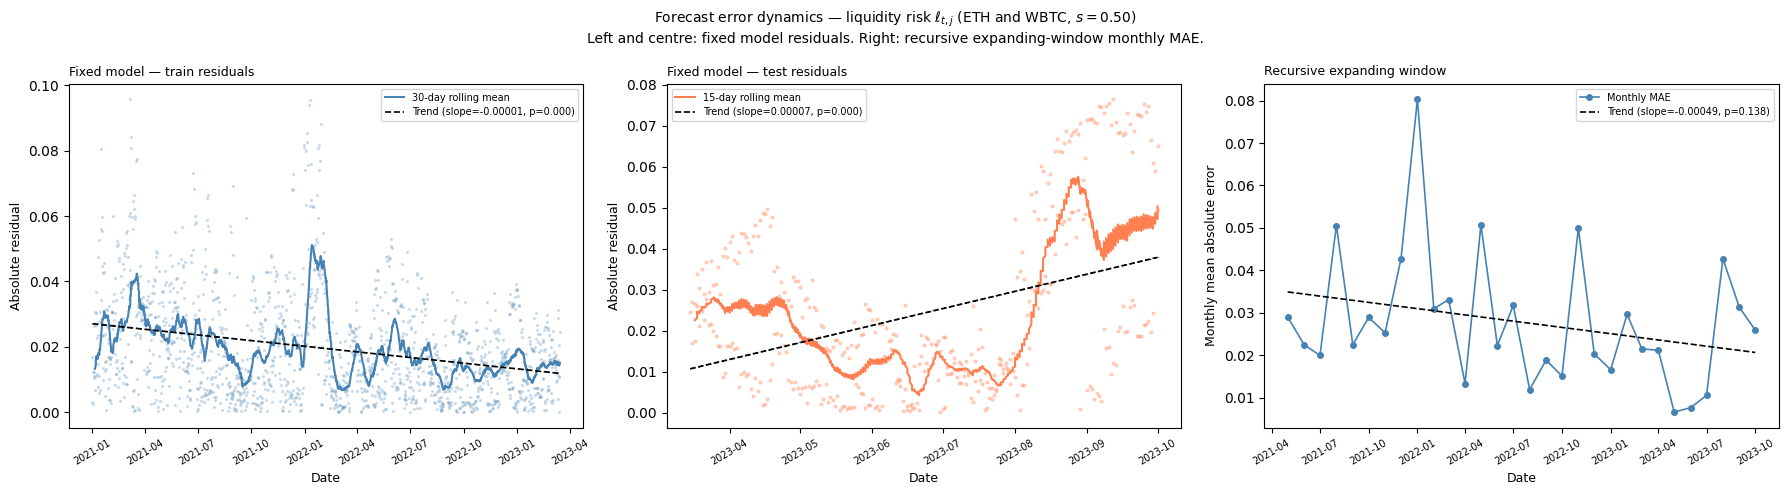

Saved: forecast_errors_combined.pdf


In [74]:
# ══════════════════════════════════════════════════════════════════
# Forecast error analysis — s = 0.50 only
# Does prediction accuracy improve over time?
# Two approaches:
#   1. SIMPLE:    absolute residuals from the fixed model + trend
#   2. RECURSIVE: expanding window refits, monthly MAE
# ══════════════════════════════════════════════════════════════════

import matplotlib.dates as mdates
from scipy import stats

FOCUS_SIZE   = 0.5
ROLLING_DAYS = 30
MIN_TRAIN    = 200

# ── Retrieve stored model and sig_vars ────────────────────────────
res        = results_by_size[FOCUS_SIZE]
sig_vars   = res['sig_vars']
model_trim = res['model_trim']

# ── Rebuild X, y, dates ───────────────────────────────────────────
regr = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['size']             == FOCUS_SIZE) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == HEALTH_THRESHOLD)
].copy()

theory_vars = [v for g in GROUPS_flat for v in features[g]]
available   = [v for v in theory_vars if v in regr.columns]

X  = regr[available].copy()
y  = regr['shareT_pool'].copy()
dt = regr['date'].copy()

row_mask = X.notna().all(axis=1) & y.notna()
X  = X.loc[row_mask]; y = y.loc[row_mask]; dt = dt.loc[row_mask]
X  = X.loc[:, X.std() > 0]; available = list(X.columns)

end_mask = dt.values <= pd.Timestamp(TEST_END_DATE)
X  = X[end_mask]; y = y[end_mask]; dt = dt[end_mask]

n_total = len(y)
n_test  = int(n_total * TEST_SIZE)
n_train = n_total - n_test

X_tr_raw = X.iloc[:n_train]; X_te_raw = X.iloc[n_train:]
y_tr     = y.iloc[:n_train]; y_te     = y.iloc[n_train:]
dates_tr = dt.iloc[:n_train]; dates_te = dt.iloc[n_train:]

scaler  = StandardScaler()
X_tr_sc = pd.DataFrame(
    scaler.fit_transform(X_tr_raw),
    columns=available, index=X_tr_raw.index
)
X_te_sc = pd.DataFrame(
    scaler.transform(X_te_raw),
    columns=available, index=X_te_raw.index
)

# ══════════════════════════════════════════════════════════════════
# 1. SIMPLE: absolute residuals over time from the fixed model
# ══════════════════════════════════════════════════════════════════
resid_tr = pd.Series(model_trim.resid.values, index=dates_tr.values)
y_pred_te = model_trim.predict(
    sm.add_constant(X_te_sc[sig_vars], has_constant='add')
)
resid_te = pd.Series(
    y_te.values - y_pred_te.values, index=dates_te.values
)

abs_resid_tr = resid_tr.abs()
abs_resid_te = resid_te.abs()

roll_tr = abs_resid_tr.sort_index().rolling(ROLLING_DAYS, min_periods=10).mean()
roll_te = abs_resid_te.sort_index().rolling(15, min_periods=5).mean()

tr_idx = np.arange(len(abs_resid_tr))
slope_tr, intercept_tr, _, p_tr, _ = stats.linregress(
    tr_idx, abs_resid_tr.sort_index().values
)
trend_tr = intercept_tr + slope_tr * tr_idx

te_idx = np.arange(len(abs_resid_te))
slope_te, intercept_te, _, p_te, _ = stats.linregress(
    te_idx, abs_resid_te.sort_index().values
)
trend_te = intercept_te + slope_te * te_idx

print("=== Simple: OLS trend on absolute residuals ===")
print(f"Train: slope={slope_tr:.6f}  p={p_tr:.4f}  "
      f"({'declining' if slope_tr < 0 else 'increasing'})")
print(f"Test:  slope={slope_te:.6f}  p={p_te:.4f}  "
      f"({'declining' if slope_te < 0 else 'increasing'})")

# ══════════════════════════════════════════════════════════════════
# 2. RECURSIVE: expanding window, refit each month
# ══════════════════════════════════════════════════════════════════
print("\n=== Recursive: expanding window refits ===")

all_months = pd.DatetimeIndex(dt.sort_values().values).to_period('M').unique()
recursive_rows = []

for month in all_months:
    cutoff  = month.to_timestamp()
    tr_mask = dt.values < cutoff
    te_mask = (dt.values >= cutoff) & \
              (dt.values < (month + 1).to_timestamp())

    n_tr = tr_mask.sum()
    n_te = te_mask.sum()
    if n_tr < MIN_TRAIN or n_te == 0:
        continue

    X_tr_r = X[available].loc[tr_mask]
    y_tr_r = y.loc[tr_mask]
    X_te_r = X[available].loc[te_mask]
    y_te_r = y.loc[te_mask]
    dt_te_r = dt.loc[te_mask]

    try:
        sc_r   = StandardScaler()
        Xtr_sc = pd.DataFrame(
            sc_r.fit_transform(X_tr_r),
            columns=available, index=X_tr_r.index
        )
        Xte_sc = pd.DataFrame(
            sc_r.transform(X_te_r),
            columns=available, index=X_te_r.index
        )

        tscv  = TimeSeriesSplit(n_splits=N_SPLITS)
        lasso = LassoCV(
            cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
            max_iter=10_000, random_state=42
        )
        lasso.fit(Xtr_sc, y_tr_r)
        coefs    = pd.Series(lasso.coef_, index=available)
        selected = coefs[coefs != 0].index.tolist() or available

        Xtr_l   = sm.add_constant(Xtr_sc[selected])
        model_r = sm.OLS(y_tr_r, Xtr_l).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )

        sig_r = [v for v in selected if model_r.pvalues.get(v, 1.0) < ALPHA]
        if not sig_r:
            sig_r = [v for v in selected if model_r.pvalues.get(v, 1.0) < 0.05]
        if not sig_r:
            continue

        Xtr_trim    = sm.add_constant(Xtr_sc[sig_r])
        model_trim_r = sm.OLS(y_tr_r, Xtr_trim).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )

        Xte_trim = sm.add_constant(Xte_sc[sig_r], has_constant='add')
        y_pred_r = model_trim_r.predict(Xte_trim)
        errors_r = y_te_r.values - y_pred_r.values

        for date_val, err in zip(dt_te_r.values, errors_r):
            recursive_rows.append({
                'date':      pd.Timestamp(date_val),
                'abs_error': abs(err),
                'n_train':   n_tr,
                'n_vars':    len(sig_r),
            })

        print(f"  {month}  n_train={n_tr:>4}  "
              f"n_vars={len(sig_r):>2}  "
              f"MAE={np.abs(errors_r).mean():.4f}")

    except Exception as e:
        print(f"  {month}  FAILED: {e}")
        continue

rec_df = pd.DataFrame(recursive_rows).sort_values('date')
print(f"\nRecursive rows: {len(rec_df)}")

# Monthly MAE + trend
rec_df['month_period'] = rec_df['date'].dt.to_period('M')
monthly_mae   = rec_df.groupby('month_period')['abs_error'].mean()
monthly_dates = monthly_mae.index.to_timestamp()

m_idx = np.arange(len(monthly_mae))
slope_rec, intercept_rec, _, p_rec, _ = stats.linregress(
    m_idx, monthly_mae.values
)
trend_rec = intercept_rec + slope_rec * m_idx

print(f"\nRecursive MAE trend: slope={slope_rec:.6f}  p={p_rec:.4f}  "
      f"({'declining' if slope_rec < 0 else 'increasing'})")

# ══════════════════════════════════════════════════════════════════
# Combined 3-panel figure
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: train absolute residuals
ax = axes[0]
sorted_tr = abs_resid_tr.sort_index()
ax.scatter(sorted_tr.index, sorted_tr.values,
           s=2, alpha=0.2, color='steelblue')
ax.plot(sorted_tr.index, roll_tr.sort_index().values,
        color='steelblue', lw=1.5,
        label=f'{ROLLING_DAYS}-day rolling mean')
ax.plot(sorted_tr.index, trend_tr,
        color='black', lw=1.2, ls='--',
        label=f'Trend (slope={slope_tr:.5f}, p={p_tr:.3f})')
ax.set_xlabel('Date', fontsize=9)
ax.set_ylabel('Absolute residual', fontsize=9)
ax.set_title('Fixed model — train residuals', fontsize=9, loc='left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30, labelsize=7)
ax.legend(fontsize=7)

# Panel 2: test absolute residuals
ax = axes[1]
sorted_te = abs_resid_te.sort_index()
ax.scatter(sorted_te.index, sorted_te.values,
           s=4, alpha=0.3, color='coral')
ax.plot(sorted_te.index, roll_te.sort_index().values,
        color='coral', lw=1.5, label='15-day rolling mean')
ax.plot(sorted_te.index, trend_te,
        color='black', lw=1.2, ls='--',
        label=f'Trend (slope={slope_te:.5f}, p={p_te:.3f})')
ax.set_xlabel('Date', fontsize=9)
ax.set_ylabel('Absolute residual', fontsize=9)
ax.set_title('Fixed model — test residuals', fontsize=9, loc='left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30, labelsize=7)
ax.legend(fontsize=7)

# Panel 3: recursive monthly MAE
ax = axes[2]
ax.plot(monthly_dates, monthly_mae.values,
        marker='o', ms=4, lw=1.2, color='steelblue',
        label='Monthly MAE')
ax.plot(monthly_dates, trend_rec,
        color='black', lw=1.2, ls='--',
        label=f'Trend (slope={slope_rec:.5f}, p={p_rec:.3f})')
ax.set_xlabel('Date', fontsize=9)
ax.set_ylabel('Monthly mean absolute error', fontsize=9)
ax.set_title('Recursive expanding window', fontsize=9, loc='left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30, labelsize=7)
ax.legend(fontsize=7)

fig.suptitle(
    f'Forecast error dynamics — liquidity risk $\\ell_{{t,j}}$ '
    f'(ETH and WBTC, $s=0.50$)\n'
    f'Left and centre: fixed model residuals. '
    f'Right: recursive expanding-window monthly MAE.',
    fontsize=10
)
plt.tight_layout()
plt.savefig('forecast_errors_combined.pdf',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: forecast_errors_combined.pdf")

In [75]:
print(f"Mean absolute train residual: {abs_resid_tr.mean():.4f}")
print(f"Total trend decline over training: {abs(slope_tr) * n_train:.4f}")
print(f"As % of mean: {abs(slope_tr) * n_train / abs_resid_tr.mean() * 100:.1f}%")

Mean absolute train residual: 0.0195
Total trend decline over training: 0.0152
As % of mean: 78.3%


In [76]:
# ══════════════════════════════════════════════════════════════════
# Verification — Liquidity model comparison table (tab:model_comparison)
# Paste AFTER the main liquidity loop has run
# (results_by_size populated from Regressions_May06_T_all_size_shocks.ipynb)
# ══════════════════════════════════════════════════════════════════

TARGET_SHOCK = 0.50

res = results_by_size.get(TARGET_SHOCK)
if res is None:
    print(f"No results for shock size {TARGET_SHOCK:.2f}.")
else:
    # ── Values from the LaTeX table ───────────────────────────────
    TABLE = {
        'Full OLS':   (0.855, 0.784, 0.0263, 30),
        'LASSO':      (0.839, 0.878, 0.0198, 20),
        'Trimmed':    (0.835, 0.868, 0.0205, 14),
        'Trimmed+FE': (0.836, 0.871, 0.0203, 15),
    }
    actual = {
        'Full OLS':   (res['r2_train_full'],    res['r2_test_full'],    res['rmse_full'],    res['n_vars_full']),
        'LASSO':      (res['r2_train_lasso'],   res['r2_test_lasso'],   res['rmse_lasso'],   res['n_vars_lasso']),
        'Trimmed':    (res['r2_train_trim'],    res['r2_test_trim'],    res['rmse_trim'],    res['n_vars_trim']),
        'Trimmed+FE': (res['r2_train_trim_fe'], res['r2_test_trim_fe'], res['rmse_trim_fe'], res['n_vars_trim_fe']),
    }

    tol_r2   = 0.002
    tol_rmse = 0.0002

    print("=" * 85)
    print("  TABLE CHECK — liquidity model comparison (s=0.50)")
    print("=" * 85)
    print(f"  {'Model':<14} {'TR²':>7} {'TeR²':>7} {'RMSE':>8} {'Vars':>5}  "
          f"{'Tbl TR²':>7} {'Tbl TeR²':>8} {'Tbl RMSE':>9} {'Match?'}")
    print("  " + "-" * 80)

    any_mismatch = False
    for name, (tr2, te2, rmse, nv) in actual.items():
        t_tr2, t_te2, t_rmse, t_nv = TABLE[name]
        ok = (abs(tr2  - t_tr2)  < tol_r2 and
              abs(te2  - t_te2)  < tol_r2 and
              abs(rmse - t_rmse) < tol_rmse and
              nv == t_nv)
        flag = "✓" if ok else "✗ MISMATCH"
        if not ok:
            any_mismatch = True
        print(f"  {name:<14} {tr2:>7.3f} {te2:>7.3f} {rmse:>8.4f} {nv:>5}  "
              f"{t_tr2:>7.3f} {t_te2:>8.3f} {t_rmse:>9.4f}  {flag}")

    print("  " + ("⚠️  Mismatches — update the LaTeX table."
                  if any_mismatch else "✅  All values match."))

  TABLE CHECK — liquidity model comparison (s=0.50)
  Model              TR²    TeR²     RMSE  Vars  Tbl TR² Tbl TeR²  Tbl RMSE Match?
  --------------------------------------------------------------------------------
  Full OLS         0.888   0.768   0.0376    30    0.855    0.784    0.0263  ✗ MISMATCH
  LASSO            0.875   0.862   0.0290    16    0.839    0.878    0.0198  ✗ MISMATCH
  Trimmed          0.872   0.831   0.0321    12    0.835    0.868    0.0205  ✗ MISMATCH
  Trimmed+FE       0.873   0.830   0.0322    13    0.836    0.871    0.0203  ✗ MISMATCH
  ⚠️  Mismatches — update the LaTeX table.


In [77]:
# ══════════════════════════════════════════════════════════════════
# Verification — Liquidity all shock sizes table
# (tab:model_comparison_allsizes)
# Paste AFTER the main liquidity loop has run.
# ══════════════════════════════════════════════════════════════════

# ── Values from the LaTeX table (s=1.00 omitted in table) ────────
TABLE_ALL = {
    0.10: (2008, 0.079, 0.116, 0.0003,  1),
    0.20: (2008, 0.460, 0.463, 0.0151,  7),
    0.30: (2008, 0.666, 0.661, 0.0261, 11),
    0.40: (2008, 0.816, 0.799, 0.0228, 13),
    0.50: (2008, 0.835, 0.868, 0.0205, 14),
    0.60: (2008, 0.835, 0.834, 0.0215, 14),
    0.70: (2008, 0.868, 0.672, 0.0247,  7),
    0.80: (2008, 0.887, 0.722, 0.0107,  9),
    0.90: (2008, 0.920, 0.472, 0.0055, 15),
}

tol_r2   = 0.002
tol_rmse = 0.0002

print("=" * 95)
print("  TABLE CHECK — liquidity all shock sizes (trimmed no FE)")
print("=" * 95)
print(f"  {'s':>5}  {'N':>5}  {'TR²':>7} {'TeR²':>7} {'RMSE':>8} {'Vars':>5}  "
      f"{'Tbl N':>5} {'Tbl TR²':>7} {'Tbl TeR²':>8} {'Tbl RMSE':>9} {'Tbl V':>5}  Match?")
print("  " + "-" * 93)

any_mismatch = False
for sz, (t_n, t_tr2, t_te2, t_rmse, t_nv) in TABLE_ALL.items():
    res = results_by_size.get(sz)
    if res is None or res['model_trim'] is None:
        print(f"  {sz:>5.2f}  *** no result in results_by_size")
        any_mismatch = True
        continue

    tr2  = res['r2_train_trim']
    te2  = res['r2_test_trim']
    rmse = res['rmse_trim']
    nv   = res['n_vars_trim']
    n    = res['n_obs']

    ok = (n   == t_n   and
          abs(tr2  - t_tr2)  < tol_r2   and
          abs(te2  - t_te2)  < tol_r2   and
          abs(rmse - t_rmse) < tol_rmse and
          nv  == t_nv)
    flag = "✓" if ok else "✗ MISMATCH"
    if not ok:
        any_mismatch = True

    print(f"  {sz:>5.2f}  {n:>5}  {tr2:>7.3f} {te2:>7.3f} {rmse:>8.4f} {nv:>5}  "
          f"{t_n:>5} {t_tr2:>7.3f} {t_te2:>8.3f} {t_rmse:>9.4f} {t_nv:>5}  {flag}")

print("  " + ("⚠️  Mismatches — update the LaTeX table."
              if any_mismatch else "✅  All values match."))

  TABLE CHECK — liquidity all shock sizes (trimmed no FE)
      s      N      TR²    TeR²     RMSE  Vars  Tbl N Tbl TR² Tbl TeR²  Tbl RMSE Tbl V  Match?
  ---------------------------------------------------------------------------------------------
   0.10   2008    0.084   0.064   0.0020     3   2008   0.079    0.116    0.0003     1  ✗ MISMATCH
   0.20   2008    0.398   0.388   0.0222     7   2008   0.460    0.463    0.0151     7  ✗ MISMATCH
   0.30   2008    0.746   0.819   0.0213    13   2008   0.666    0.661    0.0261    11  ✗ MISMATCH
   0.40   2008    0.815   0.849   0.0258    11   2008   0.816    0.799    0.0228    13  ✗ MISMATCH
   0.50   2008    0.872   0.831   0.0321    12   2008   0.835    0.868    0.0205    14  ✗ MISMATCH
   0.60   2008    0.927   0.821   0.0352    12   2008   0.835    0.834    0.0215    14  ✗ MISMATCH
   0.70   2008    0.952   0.844   0.0310    15   2008   0.868    0.672    0.0247     7  ✗ MISMATCH
   0.80   2008    0.959   0.907   0.0200    14   2008   0.

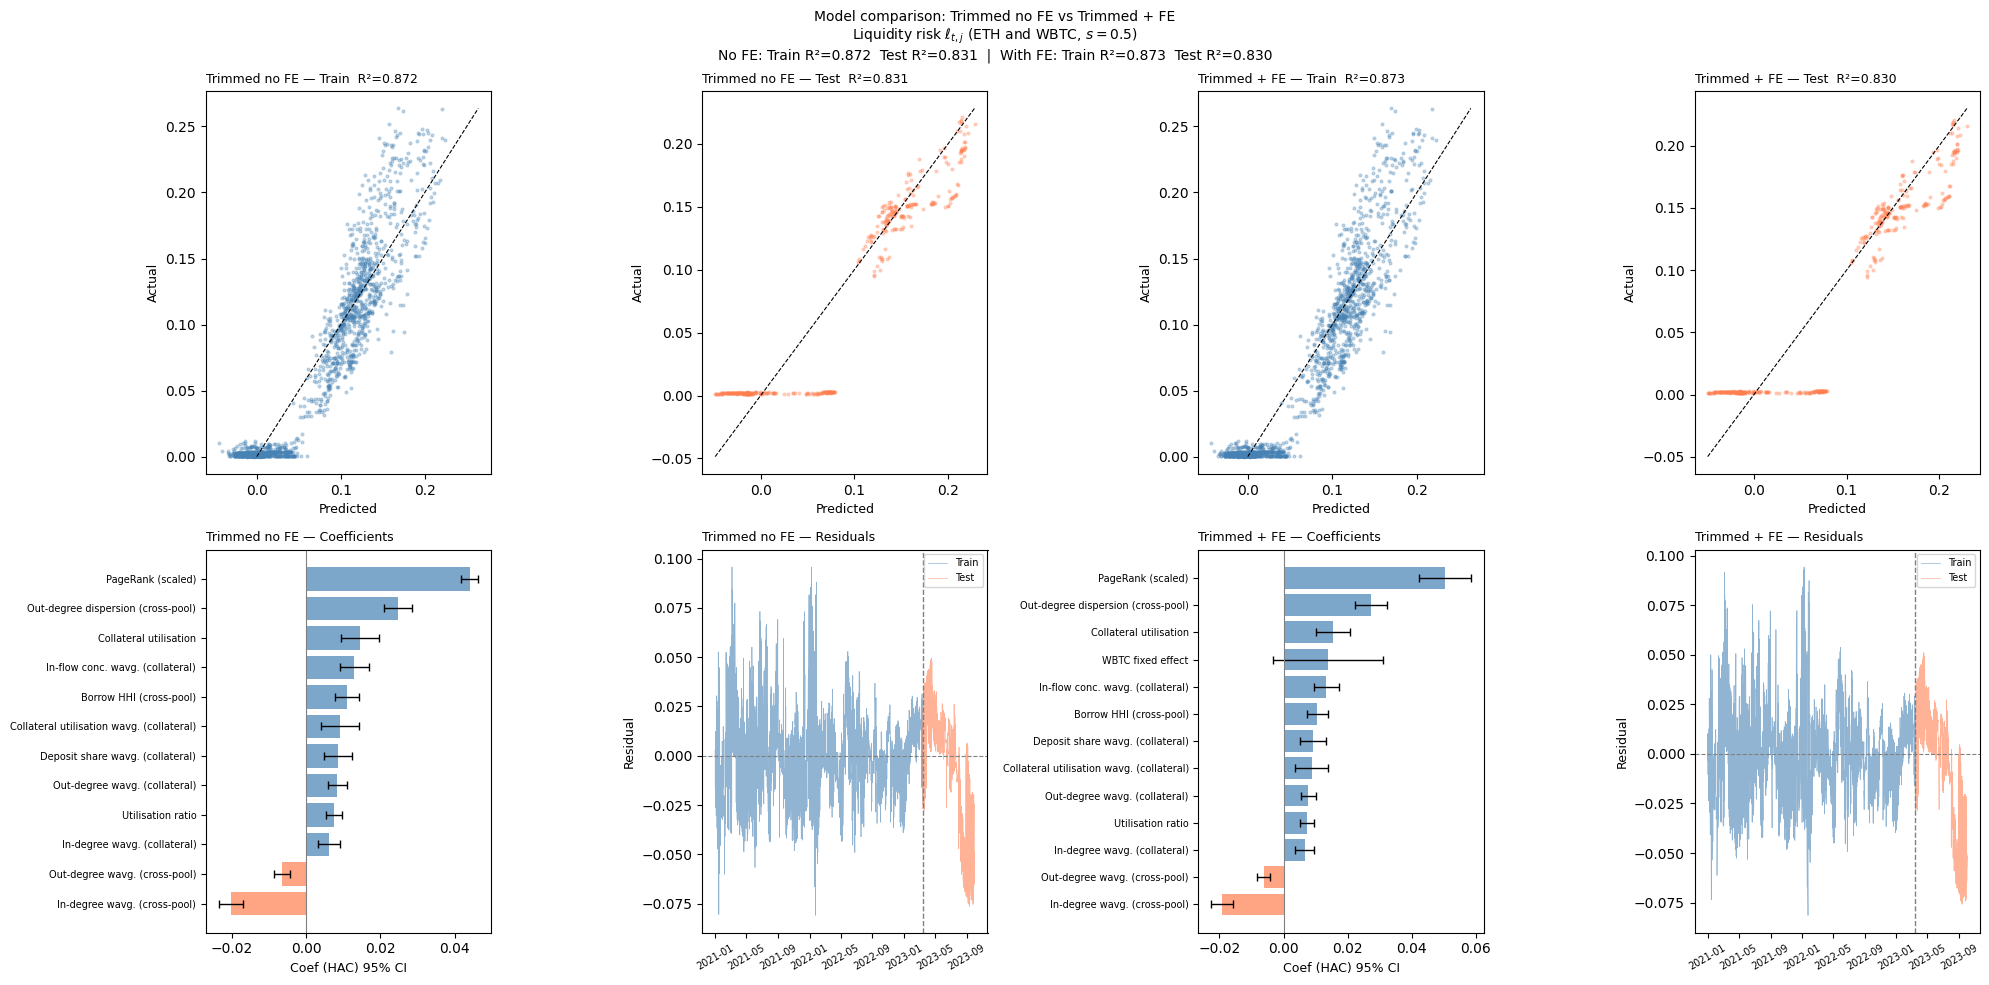

Saved: liquidity_risk_predictions_comp.png


In [78]:
# ══════════════════════════════════════════════════════════════════
# 2×4 comparison figure — Trimmed no FE vs Trimmed + FE
# Liquidity risk (shareT_pool), ETH & WBTC, s = 0.50
#
# Reproduces liquidity_risk_predictions_comp.png
# Paste AFTER the main liquidity loop has run.
# ══════════════════════════════════════════════════════════════════

TARGET_SHOCK = 0.50

res = results_by_size.get(TARGET_SHOCK)
if res is None or res['model_trim'] is None or res['model_trim_fe'] is None:
    print(f"Models not available for s={TARGET_SHOCK:.2f}.")
else:
    model_trim    = res['model_trim']
    model_trim_fe = res['model_trim_fe']
    sig_vars      = res['sig_vars']
    sig_vars_fe   = res['sig_vars_fe']

    # ── Rebuild train/test split ──────────────────────────────────
    regr_th = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == TARGET_SHOCK) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    theory_vars = [v for g in GROUPS_flat for v in features[g]]
    available   = [v for v in theory_vars if v in regr_th.columns]

    X_th  = regr_th[available].copy()
    y_th  = regr_th['shareT_pool'].copy()
    dt_th = regr_th['date'].copy()

    mask  = X_th.notna().all(axis=1) & y_th.notna()
    X_th  = X_th.loc[mask]; y_th = y_th.loc[mask]; dt_th = dt_th.loc[mask]
    X_th  = X_th.loc[:, X_th.std() > 0]; available = list(X_th.columns)

    end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
    X_th = X_th[end_mask]; y_th = y_th[end_mask]; dt_th = dt_th[end_mask]

    n_test  = int(len(y_th) * TEST_SIZE)
    n_train = len(y_th) - n_test

    X_tr_raw = X_th.iloc[:n_train]; X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]; y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]; dates_te = dt_th.iloc[n_train:]

    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    # Add FE column for trim+FE prediction
    X_te_sc['fe_WBTC'] = (
        regr_th.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
    ).astype(float).values

    # Predictions & residuals
    y_pred_trim    = model_trim.predict(
        sm.add_constant(X_te_sc[sig_vars], has_constant='add')
    )
    y_pred_trim_fe = model_trim_fe.predict(
        sm.add_constant(X_te_sc[sig_vars_fe].astype(float), has_constant='add')
    )
    res_trim    = y_te - y_pred_trim
    res_trim_fe = y_te - y_pred_trim_fe
    r2_trim     = 1 - (res_trim**2).sum()    / ((y_te - y_te.mean())**2).sum()
    r2_trim_fe  = 1 - (res_trim_fe**2).sum() / ((y_te - y_te.mean())**2).sum()

    # ── 2 × 4 figure ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for col_idx, (model, y_pred, resid, label, r2_te_) in enumerate([
        (model_trim,    y_pred_trim,    res_trim,    'Trimmed no FE', r2_trim),
        (model_trim_fe, y_pred_trim_fe, res_trim_fe, 'Trimmed + FE',  r2_trim_fe),
    ]):
        # Panel top-left / top-third: train actual vs predicted
        ax = axes[0, col_idx * 2]
        ax.scatter(model.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')
        lims = [y_tr.min(), y_tr.max()]
        ax.plot(lims, lims, 'k--', lw=0.8)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)
        ax.set_title(f'{label} — Train  R²={model.rsquared:.3f}', fontsize=9, loc='left')

        # Panel top-second / top-fourth: test actual vs predicted
        ax = axes[0, col_idx * 2 + 1]
        ax.scatter(y_pred, y_te, s=4, alpha=0.3, color='coral')
        lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
        ax.plot(lims, lims, 'k--', lw=0.8)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)
        ax.set_title(f'{label} — Test  R²={r2_te_:.3f}', fontsize=9, loc='left')

        # Panel bottom-left / bottom-third: coefficients
        ax = axes[1, col_idx * 2]
        params_r, ci_r = get_renamed_params(model)
        order_r = params_r.sort_values().index
        y_pos   = range(len(order_r))
        ax.barh(y_pos, params_r[order_r],
                color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
                alpha=0.7)
        ax.errorbar(
            params_r[order_r], y_pos,
            xerr=[params_r[order_r] - ci_r.loc[order_r, 0],
                  ci_r.loc[order_r, 1] - params_r[order_r]],
            fmt='none', color='black', capsize=3, lw=1
        )
        ax.set_yticks(y_pos)
        ax.set_yticklabels(order_r, fontsize=7)
        ax.axvline(0, color='gray', lw=0.8)
        ax.set_xlabel('Coef (HAC) 95% CI', fontsize=9)
        ax.set_title(f'{label} — Coefficients', fontsize=9, loc='left')

        # Panel bottom-second / bottom-fourth: residuals over time
        ax = axes[1, col_idx * 2 + 1]
        ax.plot(dates_tr, model.resid.values,
                color='steelblue', lw=0.5, alpha=0.6, label='Train')
        ax.plot(dates_te, resid.values,
                color='coral', lw=0.5, alpha=0.6, label='Test')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
        ax.set_ylabel('Residual', fontsize=9)
        ax.set_title(f'{label} — Residuals', fontsize=9, loc='left')
        ax.legend(fontsize=7)
        ax.tick_params(axis='x', rotation=30, labelsize=7)

    fig.suptitle(
        f'Model comparison: Trimmed no FE vs Trimmed + FE\n'
        f'Liquidity risk $\\ell_{{t,j}}$ (ETH and WBTC, $s = {TARGET_SHOCK:.1f}$)\n'
        f'No FE: Train R²={model_trim.rsquared:.3f}  Test R²={r2_trim:.3f}  |  '
        f'With FE: Train R²={model_trim_fe.rsquared:.3f}  Test R²={r2_trim_fe:.3f}',
        fontsize=10
    )

    plt.tight_layout()
    fname = f'liquidity_risk_predictions_comp.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {fname}")

In [79]:
# ══════════════════════════════════════════════════════════════════
# SOLVENCY RISK REGRESSIONS  —  outcome: share_B  (B / assets)
#
# Paste this block AFTER the existing liquidity-risk loop and after
# results_by_size, rename_map, features, break_date, etc. are all
# defined.  Produces:
#   results_by_size_B   — same structure as results_by_size
#   summary_df_B        — summary DataFrame across shock sizes
# ══════════════════════════════════════════════════════════════════

from sklearn.model_selection import TimeSeriesSplit   # already imported above, safe to re-import

# ── Configuration (inherits all globals from the liquidity loop) ──
TARGET_SHOCK_B  = 0.50   # shock size for the two LaTeX tables
N_SPLITS        = 5      # same as liquidity loop
LAMBDA_GRID_SIZE = 100   # same as liquidity loop

results_by_size_B = {}

for SHOCK_SIZE in SHOCK_SIZES:
    sep = "=" * 70
    print(f"\n{sep}")
    print(f"  [SOLVENCY]  SHOCK SIZE = {SHOCK_SIZE:.2f}")
    print(f"{sep}")

    # ------------------------------------------------------------------
    # 1. Build sample
    # ------------------------------------------------------------------
    regr_postbreak_B = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == SHOCK_SIZE) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    # Outcome: solvency risk = bad debt / total assets
    regr_postbreak_B['share_B'] = (
        regr_postbreak_B['B'] / regr_postbreak_B['assets']
    )

    n_eth  = (regr_postbreak_B['shockAsset'] == 'ETH').sum()
    n_wbtc = (regr_postbreak_B['shockAsset'] == 'WBTC').sum()
    print(f"  Post-break sample: N={len(regr_postbreak_B)}  "
          f"(ETH={n_eth}, WBTC={n_wbtc})")

    if len(regr_postbreak_B) < 20:
        print(f"  *** Too few observations — skipping size {SHOCK_SIZE:.2f}")
        results_by_size_B[SHOCK_SIZE] = None
        continue

    # ------------------------------------------------------------------
    # 2. Build X / y
    # ------------------------------------------------------------------
    theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
    available        = [v for v in theory_vars_flat if v in regr_postbreak_B.columns]
    missing          = [v for v in theory_vars_flat if v not in regr_postbreak_B.columns]
    if missing:
        print(f"  *** Missing predictors: {missing}")

    X_th  = regr_postbreak_B[available].copy()
    y_th  = regr_postbreak_B['share_B'].copy()
    dt_th = regr_postbreak_B['date'].copy()

    row_mask = X_th.notna().all(axis=1) & y_th.notna()
    X_th     = X_th.loc[row_mask]
    y_th     = y_th.loc[row_mask]
    dt_th    = dt_th.loc[row_mask]

    X_th      = X_th.loc[:, X_th.std() > 0]
    available = list(X_th.columns)

    # ------------------------------------------------------------------
    # 3. Train / test split (chronological, trimmed to TEST_END_DATE)
    # ------------------------------------------------------------------
    end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
    X_th     = X_th[end_mask]
    y_th     = y_th[end_mask]
    dt_th    = dt_th[end_mask]

    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    if n_train < 10 or n_test < 5:
        print(f"  *** Train={n_train} / Test={n_test} — too small, skipping.")
        results_by_size_B[SHOCK_SIZE] = None
        continue

    X_tr_raw = X_th.iloc[:n_train]
    X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]
    y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]
    dates_te = dt_th.iloc[n_train:]

    print(f"  Train: N={n_train}  {dates_tr.min().date()} → {dates_tr.max().date()}")
    print(f"  Test:  N={n_test}   {dates_te.min().date()} → {dates_te.max().date()}")

    # ------------------------------------------------------------------
    # 4. Scale (fit on train only)
    # ------------------------------------------------------------------
    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    # ------------------------------------------------------------------
    # 5. Full OLS
    # ------------------------------------------------------------------
    X_tr_const = sm.add_constant(X_tr_sc)
    model_hac  = sm.OLS(y_tr, X_tr_const).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    y_pred_full = model_hac.predict(sm.add_constant(X_te_sc, has_constant='add'))
    res_full    = y_te - y_pred_full
    r2_full     = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse_full   = np.sqrt((res_full**2).mean())
    print(f"\n  [Full OLS]  Train R²={model_hac.rsquared:.4f}  "
          f"Test R²={r2_full:.4f}  N vars={len(available)}")

    # ------------------------------------------------------------------
    # 6. LASSO
    # ------------------------------------------------------------------
    tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_cv = LassoCV(
        cv=tscv, n_alphas=LAMBDA_GRID_SIZE, max_iter=10_000, random_state=42
    )
    lasso_cv.fit(X_tr_sc, y_tr)

    lambdas   = lasso_cv.alphas_
    mse_path  = lasso_cv.mse_path_
    mean_mse  = mse_path.mean(axis=1)
    std_mse   = mse_path.std(axis=1) / np.sqrt(N_SPLITS)
    lam_min   = lasso_cv.alpha_
    min_idx   = np.argmin(mean_mse)
    threshold = mean_mse[min_idx] + std_mse[min_idx]
    within_1se = np.where(mean_mse <= threshold)[0]
    lam_1se   = lambdas[within_1se[0]]

    coefs_min    = pd.Series(lasso_cv.coef_, index=available)
    selected_min = coefs_min[coefs_min != 0].index.tolist()
    coefs_1se    = pd.Series(
        Lasso(alpha=lam_1se, max_iter=10_000).fit(X_tr_sc, y_tr).coef_,
        index=available
    )
    selected_1se = coefs_1se[coefs_1se != 0].index.tolist()
    print(f"  [LASSO]  λ_min={lam_min:.6f} ({len(selected_min)} vars)  "
          f"λ_1se={lam_1se:.6f} ({len(selected_1se)} vars)")

    # ------------------------------------------------------------------
    # 7. OLS on LASSO-selected vars
    # ------------------------------------------------------------------
    if not selected_min:
        print("  *** LASSO selected 0 vars — using all available.")
        selected_min = available

    X_tr_lasso  = sm.add_constant(X_tr_sc[selected_min])
    model_lasso = sm.OLS(y_tr, X_tr_lasso).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    y_pred_lasso = model_lasso.predict(
        sm.add_constant(X_te_sc[selected_min], has_constant='add')
    )
    res_lasso  = y_te - y_pred_lasso
    r2_lasso   = 1 - (res_lasso**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse_lasso = np.sqrt((res_lasso**2).mean())
    print(f"  [LASSO OLS]  Train R²={model_lasso.rsquared:.4f}  "
          f"Test R²={r2_lasso:.4f}  N vars={len(selected_min)}")

    # ------------------------------------------------------------------
    # 8. Trimmed model — no FE
    # ------------------------------------------------------------------
    sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < ALPHA]
    if not sig_vars:
        print("  *** No significant vars at ALPHA — relaxing to p<0.05.")
        sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < 0.05]

    if sig_vars:
        X_tr_trim  = sm.add_constant(X_tr_sc[sig_vars])
        model_trim = sm.OLS(y_tr, X_tr_trim).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        y_pred_trim = model_trim.predict(
            sm.add_constant(X_te_sc[sig_vars], has_constant='add')
        )
        res_trim  = y_te - y_pred_trim
        r2_trim   = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()
        rmse_trim = np.sqrt((res_trim**2).mean())
        mae_trim  = res_trim.abs().mean()
        print(f"  [Trimmed no FE]  Train R²={model_trim.rsquared:.4f}  "
              f"Test R²={r2_trim:.4f}  N vars={len(sig_vars)}")
    else:
        print("  *** No significant vars — skipping trimmed models.")
        model_trim = None
        r2_trim = rmse_trim = mae_trim = np.nan

    # ------------------------------------------------------------------
    # 9. Trimmed model — with WBTC FE, then re-trim at ALPHA
    # ------------------------------------------------------------------
    if model_trim is not None:
        X_tr_sc['fe_WBTC'] = (
            regr_postbreak_B.loc[X_tr_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values
        X_te_sc['fe_WBTC'] = (
            regr_postbreak_B.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values

        # First pass: add FE to the trimmed set
        sig_vars_fe_pass1 = list(dict.fromkeys(sig_vars + ['fe_WBTC']))
        m_fe_pass1 = sm.OLS(
            y_tr.astype(float),
            sm.add_constant(X_tr_sc[sig_vars_fe_pass1].astype(float))
        ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})

        # Re-trim at ALPHA (drop vars no longer significant after FE inclusion)
        sig_vars_fe = [
            v for v in sig_vars_fe_pass1
            if m_fe_pass1.pvalues[v] < ALPHA
        ]
        # Always keep fe_WBTC if it was significant
        if 'fe_WBTC' not in sig_vars_fe and m_fe_pass1.pvalues.get('fe_WBTC', 1) < ALPHA:
            sig_vars_fe.append('fe_WBTC')

        X_tr_trim_fe  = sm.add_constant(X_tr_sc[sig_vars_fe].astype(float))
        model_trim_fe = sm.OLS(y_tr.astype(float), X_tr_trim_fe).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        X_te_trim_fe  = sm.add_constant(
            X_te_sc[sig_vars_fe].astype(float), has_constant='add'
        )
        y_pred_trim_fe = model_trim_fe.predict(X_te_trim_fe.astype(float))
        res_trim_fe    = y_te - y_pred_trim_fe
        r2_trim_fe     = 1 - (res_trim_fe**2).sum() / ((y_te - y_te.mean())**2).sum()
        rmse_trim_fe   = np.sqrt((res_trim_fe**2).mean())
        mae_trim_fe    = res_trim_fe.abs().mean()
        print(f"  [Trimmed + FE]   Train R²={model_trim_fe.rsquared:.4f}  "
              f"Test R²={r2_trim_fe:.4f}  N vars={len(sig_vars_fe)}")

        X_tr_sc.drop(columns=['fe_WBTC'], inplace=True, errors='ignore')
        X_te_sc.drop(columns=['fe_WBTC'], inplace=True, errors='ignore')
    else:
        model_trim_fe = None
        r2_trim_fe = rmse_trim_fe = mae_trim_fe = np.nan
        sig_vars_fe = []

    # ------------------------------------------------------------------
    # 10. Store results
    # ------------------------------------------------------------------
    results_by_size_B[SHOCK_SIZE] = {
        'n_obs':             len(y_th),
        'n_train':           n_train,
        'n_test':            n_test,
        'n_vars_full':       len(available),
        'n_vars_lasso':      len(selected_min),
        'n_vars_trim':       len(sig_vars)       if sig_vars    else 0,
        'n_vars_trim_fe':    len(sig_vars_fe)    if sig_vars_fe else 0,
        'r2_train_full':     model_hac.rsquared,
        'r2_train_lasso':    model_lasso.rsquared,
        'r2_train_trim':     model_trim.rsquared    if model_trim    else np.nan,
        'r2_train_trim_fe':  model_trim_fe.rsquared if model_trim_fe else np.nan,
        'r2_test_full':      r2_full,
        'r2_test_lasso':     r2_lasso,
        'r2_test_trim':      r2_trim,
        'r2_test_trim_fe':   r2_trim_fe,
        'rmse_full':         rmse_full,
        'rmse_lasso':        rmse_lasso,
        'rmse_trim':         rmse_trim,
        'rmse_trim_fe':      rmse_trim_fe,
        'sig_vars':          sig_vars,
        'sig_vars_fe':       sig_vars_fe,
        'model_full':        model_hac,
        'model_lasso':       model_lasso,
        'model_trim':        model_trim,
        'model_trim_fe':     model_trim_fe,
    }

# ── Summary table ─────────────────────────────────────────────────
print("\n\n" + "=" * 95)
print("  SOLVENCY — summary across all shock sizes")
print("=" * 95)
print(f"  {'Size':>5}  {'N':>5}  "
      f"{'Full TR²':>9} {'Full TeR²':>10}  "
      f"{'Lasso TR²':>10} {'Lasso TeR²':>11}  "
      f"{'Trim TR²':>9} {'Trim TeR²':>10}  "
      f"{'TrimFE TR²':>11} {'TrimFE TeR²':>12}  "
      f"{'Vars(trim)':>11}")
print("  " + "-" * 93)

summary_rows_B = []
for sz, res in results_by_size_B.items():
    if res is None:
        print(f"  {sz:>5.2f}  (skipped)")
        continue
    print(f"  {sz:>5.2f}  {res['n_obs']:>5}  "
          f"{res['r2_train_full']:>9.4f} {res['r2_test_full']:>10.4f}  "
          f"{res['r2_train_lasso']:>10.4f} {res['r2_test_lasso']:>11.4f}  "
          f"{res['r2_train_trim']:>9.4f} {res['r2_test_trim']:>10.4f}  "
          f"{res['r2_train_trim_fe']:>11.4f} {res['r2_test_trim_fe']:>12.4f}  "
          f"{res['n_vars_trim']:>11}")
    summary_rows_B.append({
        'shock_size':       sz,
        'n_obs':            res['n_obs'],
        'r2_train_full':    res['r2_train_full'],
        'r2_test_full':     res['r2_test_full'],
        'r2_train_lasso':   res['r2_train_lasso'],
        'r2_test_lasso':    res['r2_test_lasso'],
        'r2_train_trim':    res['r2_train_trim'],
        'r2_test_trim':     res['r2_test_trim'],
        'r2_train_trim_fe': res['r2_train_trim_fe'],
        'r2_test_trim_fe':  res['r2_test_trim_fe'],
        'rmse_trim_fe':     res['rmse_trim_fe'],
        'n_vars_trim':      res['n_vars_trim'],
    })

summary_df_B = pd.DataFrame(summary_rows_B)
print("\n  summary_df_B available for further use.")


# ══════════════════════════════════════════════════════════════════
# Verification cell — check s=0.50 against the two LaTeX tables
# ══════════════════════════════════════════════════════════════════

res = results_by_size_B.get(TARGET_SHOCK_B)
if res is None or res['model_trim'] is None:
    print(f"No trimmed model for shock size {TARGET_SHOCK_B:.2f}.")
else:
    model_trim    = res['model_trim']
    model_trim_fe = res['model_trim_fe']

    # ── Table 1: model-level summary ──────────────────────────────
    TABLE1 = {
        'Full OLS':   (0.867, 0.835, 0.0072, res['n_vars_full']),
        'LASSO':      (0.836, 0.822, 0.0075, res['n_vars_lasso']),
        'Trimmed':    (0.834, 0.819, 0.0076, res['n_vars_trim']),
        'Trimmed+FE': (0.838, 0.834, 0.0072, res['n_vars_trim_fe']),
    }
    actual1 = {
        'Full OLS':   (res['r2_train_full'],    res['r2_test_full'],    res['rmse_full'],    res['n_vars_full']),
        'LASSO':      (res['r2_train_lasso'],   res['r2_test_lasso'],   res['rmse_lasso'],   res['n_vars_lasso']),
        'Trimmed':    (res['r2_train_trim'],    res['r2_test_trim'],    res['rmse_trim'],    res['n_vars_trim']),
        'Trimmed+FE': (res['r2_train_trim_fe'], res['r2_test_trim_fe'], res['rmse_trim_fe'], res['n_vars_trim_fe']),
    }

    print("\n" + "=" * 80)
    print("  TABLE 1 CHECK — model comparison (s=0.50, solvency risk share_B)")
    print("=" * 80)
    print(f"  {'Model':<18} {'TrainR²':>8} {'TestR²':>8} {'RMSE':>8} {'Vars':>5}  "
          f"{'Tbl TR²':>8} {'Tbl TeR²':>9} {'Tbl RMSE':>9} {'Match?'}")
    print("  " + "-" * 90)
    any_mismatch1 = False
    for name, (tr2, te2, rmse, nv) in actual1.items():
        t_tr2, t_te2, t_rmse, _ = TABLE1[name]
        tol_r2   = 0.002
        tol_rmse = 0.0002
        ok = (abs(tr2 - t_tr2) < tol_r2 and abs(te2 - t_te2) < tol_r2
              and abs(rmse - t_rmse) < tol_rmse)
        flag = "✓" if ok else "✗ MISMATCH"
        if not ok:
            any_mismatch1 = True
        print(f"  {name:<18} {tr2:>8.3f} {te2:>8.3f} {rmse:>8.4f} {nv:>5}  "
              f"{t_tr2:>8.3f} {t_te2:>9.3f} {t_rmse:>9.4f}  {flag}")
    print("  " + ("⚠️  Mismatches in Table 1." if any_mismatch1 else "✅  Table 1 all match."))

    # ── Table 2: coefficient comparison ───────────────────────────
    # Values from the LaTeX tab:coefs_comparison_solv
    TABLE2_COEFS = {
        'pagerank':                          (+0.0033, +0.0069),
        'pools_hhiDeposit':                  (+0.0013, +0.0015),
        'utilization_ratio':                 (+0.0011, None),
        'pools_out_degree_wavg':             (-0.0006, -0.0010),
        'pools_pctSelfBorrow_wavg':          (-0.0013, -0.0015),
        'pools_pctSelfBorrow_std':           (-0.0021, None),
        'in_weight_hhi':                     (+0.0005, None),
        'collaterals-in_weight_hhi-wavg':    (+0.0015, +0.0011),
        'collaterals-out_weight-wavg':       (-0.0017, -0.0023),
        'collaterals-pctSelfBorrow-wavg':    (-0.0018, -0.0017),
        'collaterals-pctUsedCollateral-wavg':(+0.0067, +0.0071),
        'collaterals-health-wavg':           (+0.0026, +0.0028),
        'collaterals-pctDeposit-wavg':       (-0.0014, None),
        'fe_WBTC':                           (None,    +0.0086),
        'const':                             (+0.0115, +0.0071),
    }

    print("\n" + "=" * 130)
    print("  TABLE 2 CHECK — coefficient comparison (s=0.50, solvency risk share_B)")
    print("=" * 130)
    print(f"  {'Variable':<45} {'NoFE coef':>10} {'NoFE p':>8}  "
          f"{'FE coef':>10} {'FE p':>8}  {'Tbl NoFE':>10} {'Tbl FE':>10}  Match?")
    print("  " + "-" * 128)

    all_vars = list(dict.fromkeys(
        list(model_trim.params.index) +
        (list(model_trim_fe.params.index) if model_trim_fe else [])
    ))

    tol = 5e-4
    any_mismatch2 = False
    for var in all_vars:
        label = rename_map.get(var, var)

        c0 = model_trim.params.get(var, None)
        p0 = model_trim.pvalues.get(var, None)
        c0_str = f"{c0:+.4f}" if c0 is not None else "---"
        p0_str = ("<0.001" if p0 < 0.001 else f"{p0:.3f}") if p0 is not None else "---"

        if model_trim_fe is not None and var in model_trim_fe.params:
            c1 = model_trim_fe.params[var]
            p1 = model_trim_fe.pvalues[var]
            c1_str = f"{c1:+.4f}"
            p1_str = "<0.001" if p1 < 0.001 else f"{p1:.3f}"
        else:
            c1, p1 = None, None
            c1_str, p1_str = "---", "---"

        t0, t1 = TABLE2_COEFS.get(var, (None, None))
        t0_str = f"{t0:+.4f}" if t0 is not None else "---"
        t1_str = f"{t1:+.4f}" if t1 is not None else "---"

        match0 = (c0 is None and t0 is None) or (
            c0 is not None and t0 is not None and abs(c0 - t0) < tol)
        match1 = (c1 is None and t1 is None) or (
            c1 is not None and t1 is not None and abs(c1 - t1) < tol)

        flag = "✓" if (match0 and match1) else "✗ MISMATCH"
        if not (match0 and match1):
            any_mismatch2 = True

        print(f"  {label:<45} {c0_str:>10} {p0_str:>8}  "
              f"{c1_str:>10} {p1_str:>8}  {t0_str:>10} {t1_str:>10}  {flag}")

    print("  " + "-" * 128)
    print("  " + ("⚠️  Mismatches in Table 2 — update the LaTeX."
                  if any_mismatch2 else "✅  Table 2 all match."))


  [SOLVENCY]  SHOCK SIZE = 0.10
  Post-break sample: N=2524  (ETH=1262, WBTC=1262)
  Train: N=1607  2021-01-01 → 2023-03-15
  Test:  N=401   2023-03-15 → 2023-10-01

  [Full OLS]  Train R²=0.6206  Test R²=-676.4678  N vars=30
  [LASSO]  λ_min=0.000244 (2 vars)  λ_1se=0.000491 (0 vars)
  [LASSO OLS]  Train R²=0.3736  Test R²=-143.6749  N vars=2
  [Trimmed no FE]  Train R²=0.3736  Test R²=-143.6749  N vars=2
  [Trimmed + FE]   Train R²=0.3736  Test R²=-143.6749  N vars=2

  [SOLVENCY]  SHOCK SIZE = 0.20
  Post-break sample: N=2524  (ETH=1262, WBTC=1262)
  Train: N=1607  2021-01-01 → 2023-03-15
  Test:  N=401   2023-03-15 → 2023-10-01

  [Full OLS]  Train R²=0.6292  Test R²=-390.0160  N vars=30
  [LASSO]  λ_min=0.000295 (1 vars)  λ_1se=0.000481 (0 vars)
  [LASSO OLS]  Train R²=0.3258  Test R²=-89.6778  N vars=1
  [Trimmed no FE]  Train R²=0.3258  Test R²=-89.6778  N vars=1
  [Trimmed + FE]   Train R²=0.3298  Test R²=-90.7077  N vars=2

  [SOLVENCY]  SHOCK SIZE = 0.30
  Post-break sample:

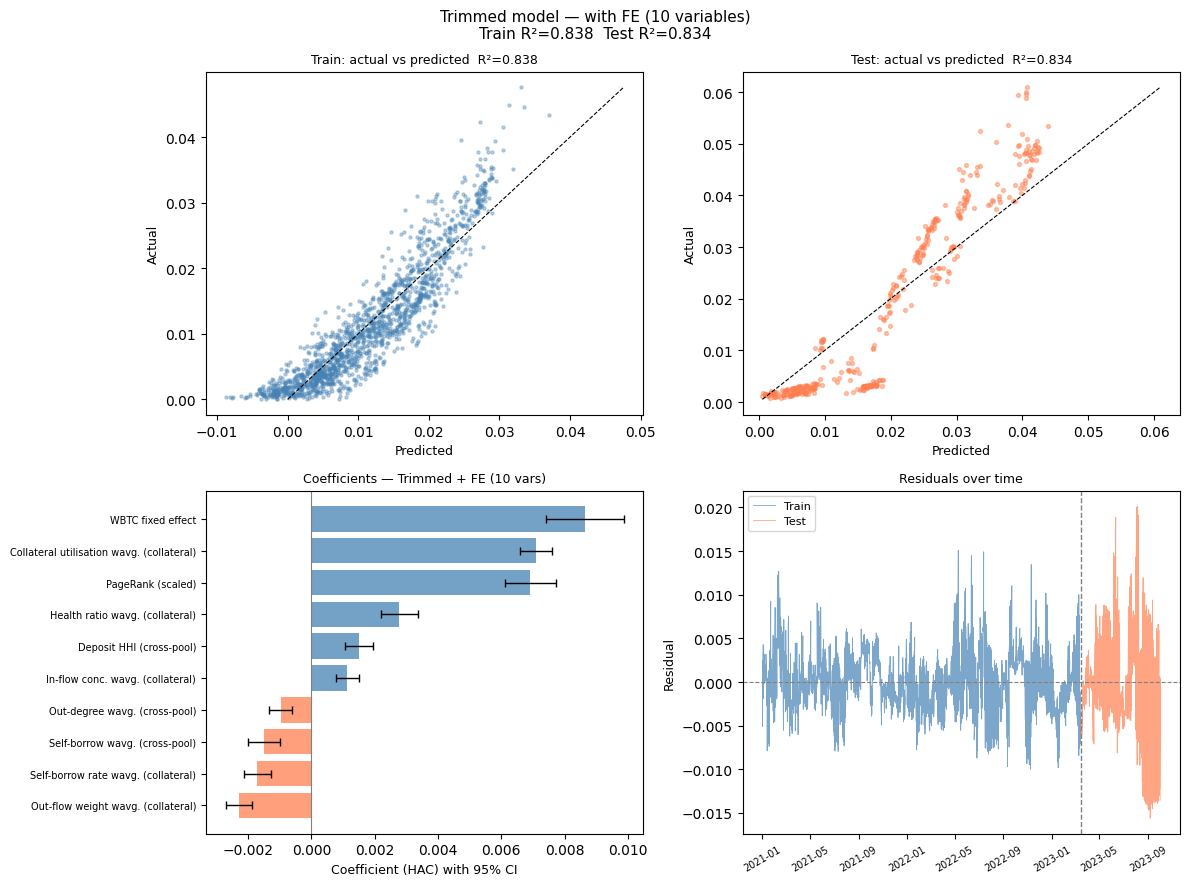

Saved: summary_trimmed_FE_solv_size050.pdf


In [80]:
# ══════════════════════════════════════════════════════════════════
# Summary figure — Trimmed + FE model — solvency risk (share_B)
# shock size s = 0.50
#
# Paste this cell AFTER the solvency loop has run
# (i.e. after results_by_size_B is populated).
# ══════════════════════════════════════════════════════════════════

TARGET_SHOCK_B = 0.50   # ← change here if you want a different size

res = results_by_size_B.get(TARGET_SHOCK_B)
if res is None or res['model_trim_fe'] is None:
    print(f"No trimmed+FE model available for shock size {TARGET_SHOCK_B:.2f}.")
else:
    model_trim_fe = res['model_trim_fe']
    sig_vars_fe   = res['sig_vars_fe']

    # ── Re-build train/test split for this shock size ─────────────
    regr_th = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == TARGET_SHOCK_B) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    regr_th['share_B'] = regr_th['B'] / regr_th['assets']

    theory_vars = [v for g in GROUPS_flat for v in features[g]]
    available   = [v for v in theory_vars if v in regr_th.columns]

    X_th  = regr_th[available].copy()
    y_th  = regr_th['share_B'].copy()
    dt_th = regr_th['date'].copy()

    mask  = X_th.notna().all(axis=1) & y_th.notna()
    X_th  = X_th.loc[mask]
    y_th  = y_th.loc[mask]
    dt_th = dt_th.loc[mask]

    X_th      = X_th.loc[:, X_th.std() > 0]
    available = list(X_th.columns)

    end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
    X_th     = X_th[end_mask]
    y_th     = y_th[end_mask]
    dt_th    = dt_th[end_mask]

    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    X_tr_raw = X_th.iloc[:n_train]
    X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]
    y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]
    dates_te = dt_th.iloc[n_train:]

    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    # Add WBTC FE column
    X_tr_sc['fe_WBTC'] = (
        regr_th.loc[X_tr_raw.index, 'shockAsset'] == 'WBTC'
    ).astype(float).values
    X_te_sc['fe_WBTC'] = (
        regr_th.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
    ).astype(float).values

    # Predictions & residuals
    y_pred_fe = model_trim_fe.predict(
        sm.add_constant(X_te_sc[sig_vars_fe], has_constant='add')
    )
    res_fe  = y_te - y_pred_fe
    r2_fe   = 1 - (res_fe**2).sum() / ((y_te - y_te.mean())**2).sum()
    n_vars  = len(sig_vars_fe)

    # ── 2 × 2 figure ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(
        f'Trimmed model — with FE ({n_vars} variables)\n'
        f'Train R²={model_trim_fe.rsquared:.3f}  '
        f'Test R²={r2_fe:.3f}',
        fontsize=11
    )

    # ── Panel A: Train actual vs predicted ───────────────────────
    ax = axes[0, 0]
    ax.scatter(model_trim_fe.fittedvalues, y_tr, s=5, alpha=0.35, color='steelblue')
    lims = [y_tr.min(), y_tr.max()]
    ax.plot(lims, lims, 'k--', lw=0.8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(
        f'Train: actual vs predicted  R²={model_trim_fe.rsquared:.3f}',
        fontsize=9
    )

    # ── Panel B: Test actual vs predicted ────────────────────────
    ax = axes[0, 1]
    ax.scatter(y_pred_fe, y_te, s=8, alpha=0.45, color='coral')
    lims = [
        min(y_te.min(), y_pred_fe.min()),
        max(y_te.max(), y_pred_fe.max())
    ]
    ax.plot(lims, lims, 'k--', lw=0.8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(
        f'Test: actual vs predicted  R²={r2_fe:.3f}',
        fontsize=9
    )

    # ── Panel C: Coefficients (HAC 95% CI) ───────────────────────
    ax = axes[1, 0]
    params_r, ci_r = get_renamed_params(model_trim_fe)
    params_r = params_r.drop('const', errors='ignore')
    ci_r     = ci_r.drop('const', errors='ignore')

    order_r = params_r.sort_values().index
    y_pos   = range(len(order_r))
    ax.barh(
        y_pos,
        params_r[order_r],
        color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
        alpha=0.75
    )
    ax.errorbar(
        params_r[order_r], y_pos,
        xerr=[
            params_r[order_r] - ci_r.loc[order_r, 0],
            ci_r.loc[order_r, 1] - params_r[order_r]
        ],
        fmt='none', color='black', capsize=3, lw=1
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order_r, fontsize=7)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=9)
    ax.set_title(
        f'Coefficients — Trimmed + FE ({n_vars} vars)',
        fontsize=9
    )

    # ── Panel D: Residuals over time ─────────────────────────────
    ax = axes[1, 1]
    ax.plot(dates_tr.values, model_trim_fe.resid.values,
            color='steelblue', lw=0.6, alpha=0.7, label='Train')
    ax.plot(dates_te.values, res_fe.values,
            color='coral',     lw=0.6, alpha=0.7, label='Test')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
    ax.set_ylabel('Residual', fontsize=9)
    ax.set_title('Residuals over time', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

    plt.tight_layout()

    fname = f'summary_trimmed_FE_solv_size{int(TARGET_SHOCK_B * 100):03d}.pdf'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {fname}")

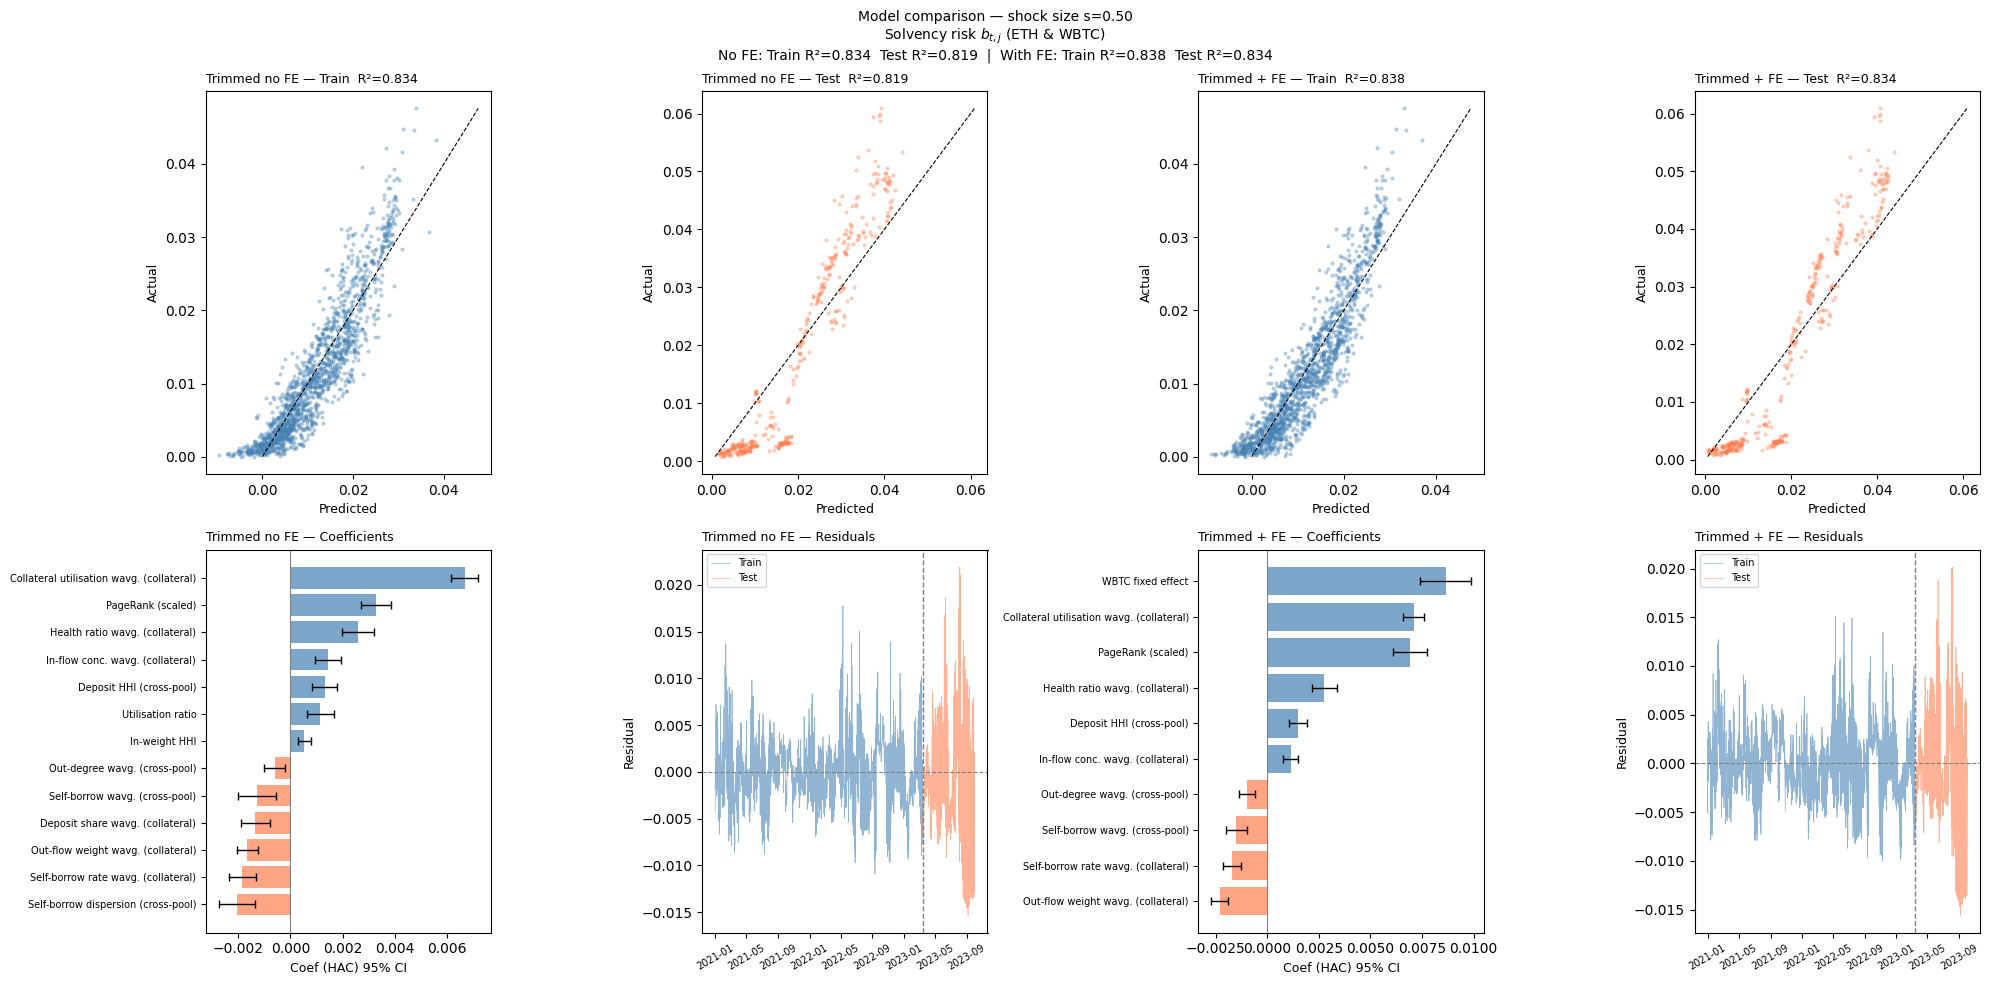

Saved: solvency_risk_comp.png

  COEFFICIENT TABLE — Solvency risk b_{t,j} (ETH & WBTC, s=0.50)
  Variable                                       NoFE coef   NoFE p     FE coef     FE p
  -------------------------------------------------------------------------------------
  const                                            +0.0115   <0.001     +0.0071   <0.001
  Utilisation ratio                                +0.0011   <0.001         ---      ---
  In-weight HHI                                    +0.0005   <0.001         ---      ---
  Deposit HHI (cross-pool)                         +0.0013   <0.001     +0.0015   <0.001
  Self-borrow dispersion (cross-pool)              -0.0021   <0.001         ---      ---
  Out-degree wavg. (cross-pool)                    -0.0006    0.003     -0.0010   <0.001
  Self-borrow wavg. (cross-pool)                   -0.0013   <0.001     -0.0015   <0.001
  PageRank (scaled)                                +0.0033   <0.001     +0.0069   <0.001
  In-flow conc.

In [81]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ── Config ────────────────────────────────────────────────────────
SHOCK_SIZE       = 0.50
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['ETH', 'WBTC']
TEST_SIZE        = 0.2

# ── Retrieve stored models from the main loop ─────────────────────
res           = results_by_size_B[SHOCK_SIZE]
model_trim    = res['model_trim']
model_trim_fe = res['model_trim_fe']
sig_vars      = res['sig_vars']
sig_vars_fe   = res['sig_vars_fe']

if model_trim is None or model_trim_fe is None:
    print(f"Models not available for s={SHOCK_SIZE:.2f}.")
else:
    # ── Rebuild train/test split (identical to main loop) ─────────
    regr_postbreak = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == SHOCK_SIZE) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
    available        = [v for v in theory_vars_flat if v in regr_postbreak.columns]

    X_th  = regr_postbreak[available].copy()
    y_th  = regr_postbreak['share_B'].copy()
    dt_th = regr_postbreak['date'].copy()

    row_mask = X_th.notna().all(axis=1) & y_th.notna()
    X_th  = X_th.loc[row_mask]
    y_th  = y_th.loc[row_mask]
    dt_th = dt_th.loc[row_mask]

    X_th      = X_th.loc[:, X_th.std() > 0]
    available = list(X_th.columns)

    end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
    X_th  = X_th[end_mask]
    y_th  = y_th[end_mask]
    dt_th = dt_th[end_mask]

    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    X_tr_raw = X_th.iloc[:n_train]
    X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]
    y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]
    dates_te = dt_th.iloc[n_train:]

    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    # Add WBTC FE column for trim+FE prediction
    X_te_sc['fe_WBTC'] = (
        regr_postbreak.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
    ).astype(float).values

    # ── Predictions & residuals ───────────────────────────────────
    y_pred_trim = model_trim.predict(
        sm.add_constant(X_te_sc[sig_vars], has_constant='add')
    )
    y_pred_trim_fe = model_trim_fe.predict(
        sm.add_constant(X_te_sc[sig_vars_fe].astype(float), has_constant='add')
    )
    res_trim    = y_te - y_pred_trim
    res_trim_fe = y_te - y_pred_trim_fe
    r2_trim     = 1 - (res_trim**2).sum()    / ((y_te - y_te.mean())**2).sum()
    r2_trim_fe  = 1 - (res_trim_fe**2).sum() / ((y_te - y_te.mean())**2).sum()

    # ── 2 × 4 figure ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for col_idx, (model, y_pred, res_plot, label, r2_te_) in enumerate([
        (model_trim,    y_pred_trim,    res_trim,    'Trimmed no FE', r2_trim),
        (model_trim_fe, y_pred_trim_fe, res_trim_fe, 'Trimmed + FE',  r2_trim_fe),
    ]):
        # actual vs predicted — train
        ax = axes[0, col_idx * 2]
        ax.scatter(model.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')
        lims = [y_tr.min(), y_tr.max()]
        ax.plot(lims, lims, 'k--', lw=0.8)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)
        ax.set_title(f'{label} — Train  R²={model.rsquared:.3f}', fontsize=9, loc='left')

        # actual vs predicted — test
        ax = axes[0, col_idx * 2 + 1]
        ax.scatter(y_pred, y_te, s=4, alpha=0.3, color='coral')
        lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
        ax.plot(lims, lims, 'k--', lw=0.8)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)
        ax.set_title(f'{label} — Test  R²={r2_te_:.3f}', fontsize=9, loc='left')

        # coefficients
        ax = axes[1, col_idx * 2]
        params_r, ci_r = get_renamed_params(model)
        order_r = params_r.sort_values().index
        y_pos   = range(len(order_r))
        ax.barh(y_pos, params_r[order_r],
                color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
                alpha=0.7)
        ax.errorbar(
            params_r[order_r], y_pos,
            xerr=[params_r[order_r] - ci_r.loc[order_r, 0],
                  ci_r.loc[order_r, 1] - params_r[order_r]],
            fmt='none', color='black', capsize=3, lw=1
        )
        ax.set_yticks(y_pos)
        ax.set_yticklabels(order_r, fontsize=7)
        ax.axvline(0, color='gray', lw=0.8)
        ax.set_xlabel('Coef (HAC) 95% CI', fontsize=9)
        ax.set_title(f'{label} — Coefficients', fontsize=9, loc='left')

        # residuals over time
        ax = axes[1, col_idx * 2 + 1]
        ax.plot(dates_tr, model.resid.values,
                color='steelblue', lw=0.5, alpha=0.6, label='Train')
        ax.plot(dates_te, res_plot.values,
                color='coral', lw=0.5, alpha=0.6, label='Test')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
        ax.set_ylabel('Residual', fontsize=9)
        ax.set_title(f'{label} — Residuals', fontsize=9, loc='left')
        ax.legend(fontsize=7)
        ax.tick_params(axis='x', rotation=30, labelsize=7)

    fig.suptitle(
        f'Model comparison — shock size s={SHOCK_SIZE:.2f}\n'
        f'Solvency risk $b_{{t,j}}$ (ETH & WBTC)\n'
        f'No FE: Train R²={model_trim.rsquared:.3f}  Test R²={r2_trim:.3f}  |  '
        f'With FE: Train R²={model_trim_fe.rsquared:.3f}  Test R²={r2_trim_fe:.3f}',
        fontsize=10
    )
    plt.tight_layout()
    fname = 'solvency_risk_comp.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {fname}")

    # ── Coefficient table ─────────────────────────────────────────
    print("\n" + "=" * 90)
    print(f"  COEFFICIENT TABLE — Solvency risk b_{{t,j}} (ETH & WBTC, s={SHOCK_SIZE:.2f})")
    print("=" * 90)
    print(f"  {'Variable':<45} {'NoFE coef':>10} {'NoFE p':>8}  {'FE coef':>10} {'FE p':>8}")
    print("  " + "-" * 85)

    # collect all variables across both models
    all_vars = list(dict.fromkeys(
        list(model_trim.params.index) +
        list(model_trim_fe.params.index)
    ))

    for var in all_vars:
        label = rename_map.get(var, var)

        if var in model_trim.params:
            c0 = model_trim.params[var]
            p0 = model_trim.pvalues[var]
            c0_str = f"{c0:+.4f}"
            p0_str = "<0.001" if p0 < 0.001 else f"{p0:.3f}"
        else:
            c0_str, p0_str = "---", "---"

        if var in model_trim_fe.params:
            c1 = model_trim_fe.params[var]
            p1 = model_trim_fe.pvalues[var]
            c1_str = f"{c1:+.4f}"
            p1_str = "<0.001" if p1 < 0.001 else f"{p1:.3f}"
        else:
            c1_str, p1_str = "---", "---"

        print(f"  {label:<45} {c0_str:>10} {p0_str:>8}  {c1_str:>10} {p1_str:>8}")

    print("  " + "-" * 85)

    # R² and RMSE
    rmse_trim    = np.sqrt((res_trim**2).mean())
    rmse_trim_fe = np.sqrt((res_trim_fe**2).mean())

    print(f"  {'Train R²':<45} {model_trim.rsquared:>10.3f} {'':>8}  {model_trim_fe.rsquared:>10.3f}")
    print(f"  {'Test R²':<45} {r2_trim:>10.3f} {'':>8}  {r2_trim_fe:>10.3f}")
    print(f"  {'RMSE':<45} {rmse_trim:>10.4f} {'':>8}  {rmse_trim_fe:>10.4f}")
    print("=" * 90)

    # ── Coefficient table ─────────────────────────────────────────
    print("\n" + "=" * 90)
    print(f"  COEFFICIENT TABLE — Solvency risk b_{{t,j}} (ETH & WBTC, s={SHOCK_SIZE:.2f})")
    print("=" * 90)
    print(f"  {'Variable':<45} {'NoFE coef':>10} {'NoFE p':>8}  {'FE coef':>10} {'FE p':>8}")
    print("  " + "-" * 85)

    all_vars = list(dict.fromkeys(
        list(model_trim.params.index) +
        list(model_trim_fe.params.index)
    ))

    for var in all_vars:
        label = rename_map.get(var, var)

        if var in model_trim.params:
            c0 = model_trim.params[var]
            p0 = model_trim.pvalues[var]
            c0_str = f"{c0:+.4f}"
            p0_str = "<0.001" if p0 < 0.001 else f"{p0:.3f}"
        else:
            c0_str, p0_str = "---", "---"

        if var in model_trim_fe.params:
            c1 = model_trim_fe.params[var]
            p1 = model_trim_fe.pvalues[var]
            c1_str = f"{c1:+.4f}"
            p1_str = "<0.001" if p1 < 0.001 else f"{p1:.3f}"
        else:
            c1_str, p1_str = "---", "---"

        print(f"  {label:<45} {c0_str:>10} {p0_str:>8}  {c1_str:>10} {p1_str:>8}")

    print("  " + "-" * 85)
    rmse_trim    = np.sqrt((res_trim**2).mean())
    rmse_trim_fe = np.sqrt((res_trim_fe**2).mean())
    print(f"  {'Train R²':<45} {model_trim.rsquared:>10.3f} {'':>8}  {model_trim_fe.rsquared:>10.3f}")
    print(f"  {'Test R²':<45} {r2_trim:>10.3f} {'':>8}  {r2_trim_fe:>10.3f}")
    print(f"  {'RMSE':<45} {rmse_trim:>10.4f} {'':>8}  {rmse_trim_fe:>10.4f}")
    print("=" * 90)

Sample: N=2524  (DAI=1262, USDC=1262)
Train: N=1607  2021-01-01 → 2023-03-15
Test:  N=401   2023-03-15 → 2023-10-01
[Full OLS]  Train R²=0.9671  N vars=30
[LASSO]  λ_min=0.000480  (13 vars)
[LASSO OLS]  Train R²=0.9306  N vars=13
[Trimmed no FE]  Train R²=0.9198  Test R²=0.7670  N vars=7


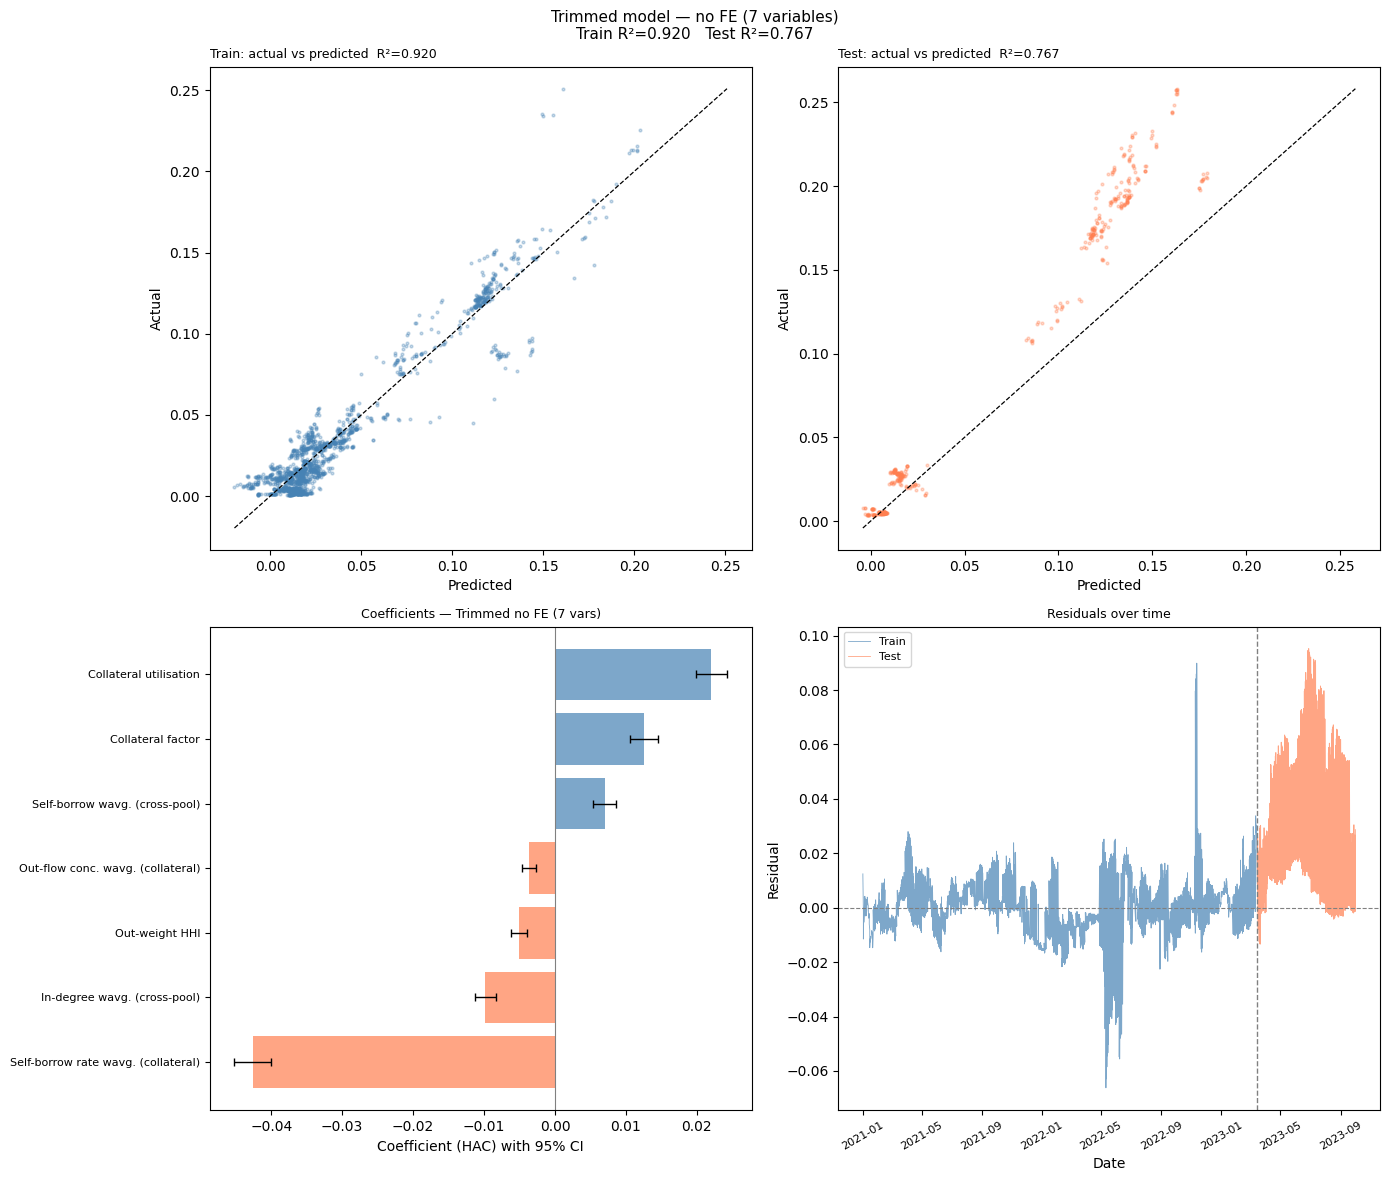

Saved: summary_trim_nofe_size100_stablecoins.pdf


In [82]:
# ══════════════════════════════════════════════════════════════════
# Summary figure — Trimmed model no FE — solvency risk (share_B)
# DAI & USDC, shock size s = 1.00
#
# Matches exactly the pipeline in:
#   Regressions_april29_B_all_size_shocks_stablecoins_fig100.ipynb
#
# Key differences from the ETH/WBTC version:
#   - CRYPTO_ASSETS = ['DAI', 'USDC']
#   - LAMBDA_GRID_SIZE = 200
#   - share_B already exists in final_updated (no recomputation needed)
#   - Preferred spec is no FE
#   - FOCUS_SIZE = 1.0
# ══════════════════════════════════════════════════════════════════

import copy
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import TimeSeriesSplit

# ── Config ────────────────────────────────────────────────────────
FOCUS_SIZE       = 1.0
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['DAI', 'USDC']   # stablecoins
ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200               # 200, not 100

GROUPS_flat = [
    'pool_own', 'pool_cross', 'pool_centrality',
    'collaterals_network', 'collaterals_financial',
    #'borrowers_network',   'borrowers_financial',
]

rename_map = {
    'pctUsedCollateral':               'Collateral utilisation',
    'self_borrow_2':                   'Self-borrowing rate',
    'utilization_ratio':               'Utilisation ratio',
    'collateralFactor':                'Collateral factor',
    'in_degree':                       'In-degree',
    'in_weight_hhi':                   'In-weight HHI',
    'out_degree':                      'Out-degree',
    'out_weight_hhi':                  'Out-weight HHI',
    'pagerank':                        'PageRank',
    'pagerank_scaled':                 'PageRank (scaled)',
    'hub':                             'Hub score',
    'hub_scaled':                      'Hub score (scaled)',
    'pools_hhiDeposit':                'Deposit HHI (cross-pool)',
    'pools_hhiBorrow':                 'Borrow HHI (cross-pool)',
    'pools_in_degree_std':             'In-degree dispersion (cross-pool)',
    'pools_out_degree_std':            'Out-degree dispersion (cross-pool)',
    'pools_pctSelfBorrow_std':         'Self-borrow dispersion (cross-pool)',
    'pools_out_degree_wavg':           'Out-degree wavg. (cross-pool)',
    'pools_in_degree_wavg':            'In-degree wavg. (cross-pool)',
    'pools_pctSelfBorrow_wavg':        'Self-borrow wavg. (cross-pool)',
    'collaterals-in_degree-wavg':      'In-degree wavg. (collateral)',
    'collaterals-in_weight-wavg':      'In-flow weight wavg. (collateral)',
    'collaterals-in_weight_hhi-wavg':  'In-flow conc. wavg. (collateral)',
    'collaterals-out_degree-wavg':     'Out-degree wavg. (collateral)',
    'collaterals-out_weight-wavg':     'Out-flow weight wavg. (collateral)',
    'collaterals-out_weight_hhi-wavg': 'Out-flow conc. wavg. (collateral)',
    'collaterals-pctSelfBorrow-wavg':  'Self-borrow rate wavg. (collateral)',
    'collaterals-pctUsedCollateral-wavg': 'Collateral utilisation wavg. (collateral)',
    'collaterals-health-wavg':         'Health ratio wavg. (collateral)',
    'collaterals-pctDeposit-wavg':     'Deposit share wavg. (collateral)',
    'borrowers-in_degree-wavg':        'In-degree wavg. (borrower)',
    'borrowers-in_weight-wavg':        'In-flow weight wavg. (borrower)',
    'borrowers-in_weight_hhi-wavg':    'In-flow conc. wavg. (borrower)',
    'borrowers-out_degree-wavg':       'Out-degree wavg. (borrower)',
    'borrowers-out_weight-wavg':       'Out-flow weight wavg. (borrower)',
    'borrowers-out_weight_hhi-wavg':   'Out-flow conc. wavg. (borrower)',
    'borrowers-pctSelfBorrow-wavg':    'Self-borrow rate wavg. (borrower)',
    'borrowers-pctUsedCollateral-wavg':'Collateral utilisation wavg. (borrower)',
    'borrowers-health-wavg':           'Health ratio wavg. (borrower)',
    'borrowers-pctDeposit-wavg':       'Deposit share wavg. (borrower)',
    'fe_DAI':                          'DAI fixed effect',
}

def get_renamed_params(model):
    params   = model.params.drop('const')
    ci       = model.conf_int().drop('const')
    params_r = params.rename(index=lambda v: rename_map.get(v, v))
    ci_r     = ci.rename(index=lambda v: rename_map.get(v, v))
    return params_r, ci_r

# ── 1. Build sample ───────────────────────────────────────────────
regr100 = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['size']             == FOCUS_SIZE) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == HEALTH_THRESHOLD)
].copy()

# share_B already exists in final_updated
n_dai  = (regr100['shockAsset'] == 'DAI').sum()
n_usdc = (regr100['shockAsset'] == 'USDC').sum()
print(f"Sample: N={len(regr100)}  (DAI={n_dai}, USDC={n_usdc})")

# ── 2. Build X / y ────────────────────────────────────────────────
theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
available        = [v for v in theory_vars_flat if v in regr100.columns]

X_th  = regr100[available].copy()
y_th  = regr100['share_B'].copy()
dt_th = regr100['date'].copy()

row_mask = X_th.notna().all(axis=1) & y_th.notna()
X_th  = X_th.loc[row_mask]; y_th = y_th.loc[row_mask]; dt_th = dt_th.loc[row_mask]
X_th  = X_th.loc[:, X_th.std() > 0]; available = list(X_th.columns)

# ── 3. Train / test split ─────────────────────────────────────────
end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
X_th = X_th[end_mask]; y_th = y_th[end_mask]; dt_th = dt_th[end_mask]

n_total = len(y_th)
n_test  = int(n_total * TEST_SIZE)
n_train = n_total - n_test

X_tr_raw = X_th.iloc[:n_train]; X_te_raw = X_th.iloc[n_train:]
y_tr     = y_th.iloc[:n_train]; y_te     = y_th.iloc[n_train:]
dates_tr = dt_th.iloc[:n_train]; dates_te = dt_th.iloc[n_train:]

print(f"Train: N={n_train}  {dates_tr.min().date()} → {dates_tr.max().date()}")
print(f"Test:  N={n_test}   {dates_te.min().date()} → {dates_te.max().date()}")

# ── 4. Scale ──────────────────────────────────────────────────────
scaler  = StandardScaler()
X_tr_sc = pd.DataFrame(
    scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
)
X_te_sc = pd.DataFrame(
    scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
)

# ── 5. Full OLS ───────────────────────────────────────────────────
model_hac = sm.OLS(y_tr, sm.add_constant(X_tr_sc)).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)
print(f"[Full OLS]  Train R²={model_hac.rsquared:.4f}  N vars={len(available)}")

# ── 6. LASSO ──────────────────────────────────────────────────────
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
lasso_cv = LassoCV(
    cv=tscv, n_alphas=LAMBDA_GRID_SIZE, max_iter=10_000, random_state=42
)
lasso_cv.fit(X_tr_sc, y_tr)

coefs_min    = pd.Series(lasso_cv.coef_, index=available)
selected_min = coefs_min[coefs_min != 0].index.tolist()
if not selected_min:
    selected_min = available
print(f"[LASSO]  λ_min={lasso_cv.alpha_:.6f}  ({len(selected_min)} vars)")

# ── 7. OLS on LASSO-selected vars ────────────────────────────────
model_lasso = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected_min])).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)
print(f"[LASSO OLS]  Train R²={model_lasso.rsquared:.4f}  N vars={len(selected_min)}")

# ── 8. Trimmed model — no FE ──────────────────────────────────────
sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < ALPHA]
if not sig_vars:
    print("*** No significant vars at ALPHA — relaxing to p<0.05.")
    sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < 0.05]

model_trim = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig_vars])).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)
y_pred_te = model_trim.predict(
    sm.add_constant(X_te_sc[sig_vars], has_constant='add')
)
res_te  = y_te - y_pred_te
r2_test = 1 - (res_te**2).sum() / ((y_te - y_te.mean())**2).sum()
n_vars  = len(sig_vars)

print(f"[Trimmed no FE]  Train R²={model_trim.rsquared:.4f}  "
      f"Test R²={r2_test:.4f}  N vars={n_vars}")

# ── 9. 2 × 2 figure ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    f'Trimmed model — no FE ({n_vars} variables)\n'
    f'Train R²={model_trim.rsquared:.3f}   Test R²={r2_test:.3f}',
    fontsize=11
)

# Panel A: Train actual vs predicted
ax = axes[0, 0]
ax.scatter(model_trim.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')
lims = [min(y_tr.min(), model_trim.fittedvalues.min()),
        max(y_tr.max(), model_trim.fittedvalues.max())]
ax.plot(lims, lims, 'k--', lw=0.9)
ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('Actual', fontsize=10)
ax.set_title(f'Train: actual vs predicted  R²={model_trim.rsquared:.3f}',
             fontsize=9, loc='left')

# Panel B: Test actual vs predicted
ax = axes[0, 1]
ax.scatter(y_pred_te, y_te, s=4, alpha=0.3, color='coral')
lims = [min(y_te.min(), y_pred_te.min()), max(y_te.max(), y_pred_te.max())]
ax.plot(lims, lims, 'k--', lw=0.9)
ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('Actual', fontsize=10)
ax.set_title(f'Test: actual vs predicted  R²={r2_test:.3f}',
             fontsize=9, loc='left')

# Panel C: Coefficients
ax = axes[1, 0]
params_r, ci_r = get_renamed_params(model_trim)
order_r = params_r.sort_values().index
y_pos   = range(len(order_r))
ax.barh(y_pos, params_r[order_r],
        color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
        alpha=0.7)
ax.errorbar(
    params_r[order_r], y_pos,
    xerr=[params_r[order_r] - ci_r.loc[order_r, 0],
          ci_r.loc[order_r, 1] - params_r[order_r]],
    fmt='none', color='black', capsize=3, lw=1
)
ax.set_yticks(y_pos); ax.set_yticklabels(order_r, fontsize=8)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=10)
ax.set_title(f'Coefficients — Trimmed no FE ({n_vars} vars)',
             fontsize=9, loc='center')

# Panel D: Residuals over time
ax = axes[1, 1]
ax.plot(dates_tr, model_trim.resid.values,
        color='steelblue', lw=0.6, alpha=0.7, label='Train')
ax.plot(dates_te, res_te.values,
        color='coral', lw=0.6, alpha=0.7, label='Test')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
ax.set_ylabel('Residual', fontsize=10); ax.set_xlabel('Date', fontsize=10)
ax.set_title('Residuals over time', fontsize=9, loc='center')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig('summary_trim_nofe_size100_stablecoins.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: summary_trim_nofe_size100_stablecoins.pdf")

Sample: N=2524  (DAI=1262, USDC=1262)
Train: N=1607  2021-01-01 → 2023-03-15
Test:  N=401   2023-03-15 → 2023-10-01
[Full OLS]  Train R²=0.9671  N vars=30
[LASSO]  λ_min=0.000480  (13 vars)
[LASSO OLS]  Train R²=0.9306  N vars=13
[Trimmed no FE]  Train R²=0.9198  Test R²=0.7670  N vars=7
[Trimmed + FE]   Train R²=0.9242  Test R²=0.7808  N vars=8


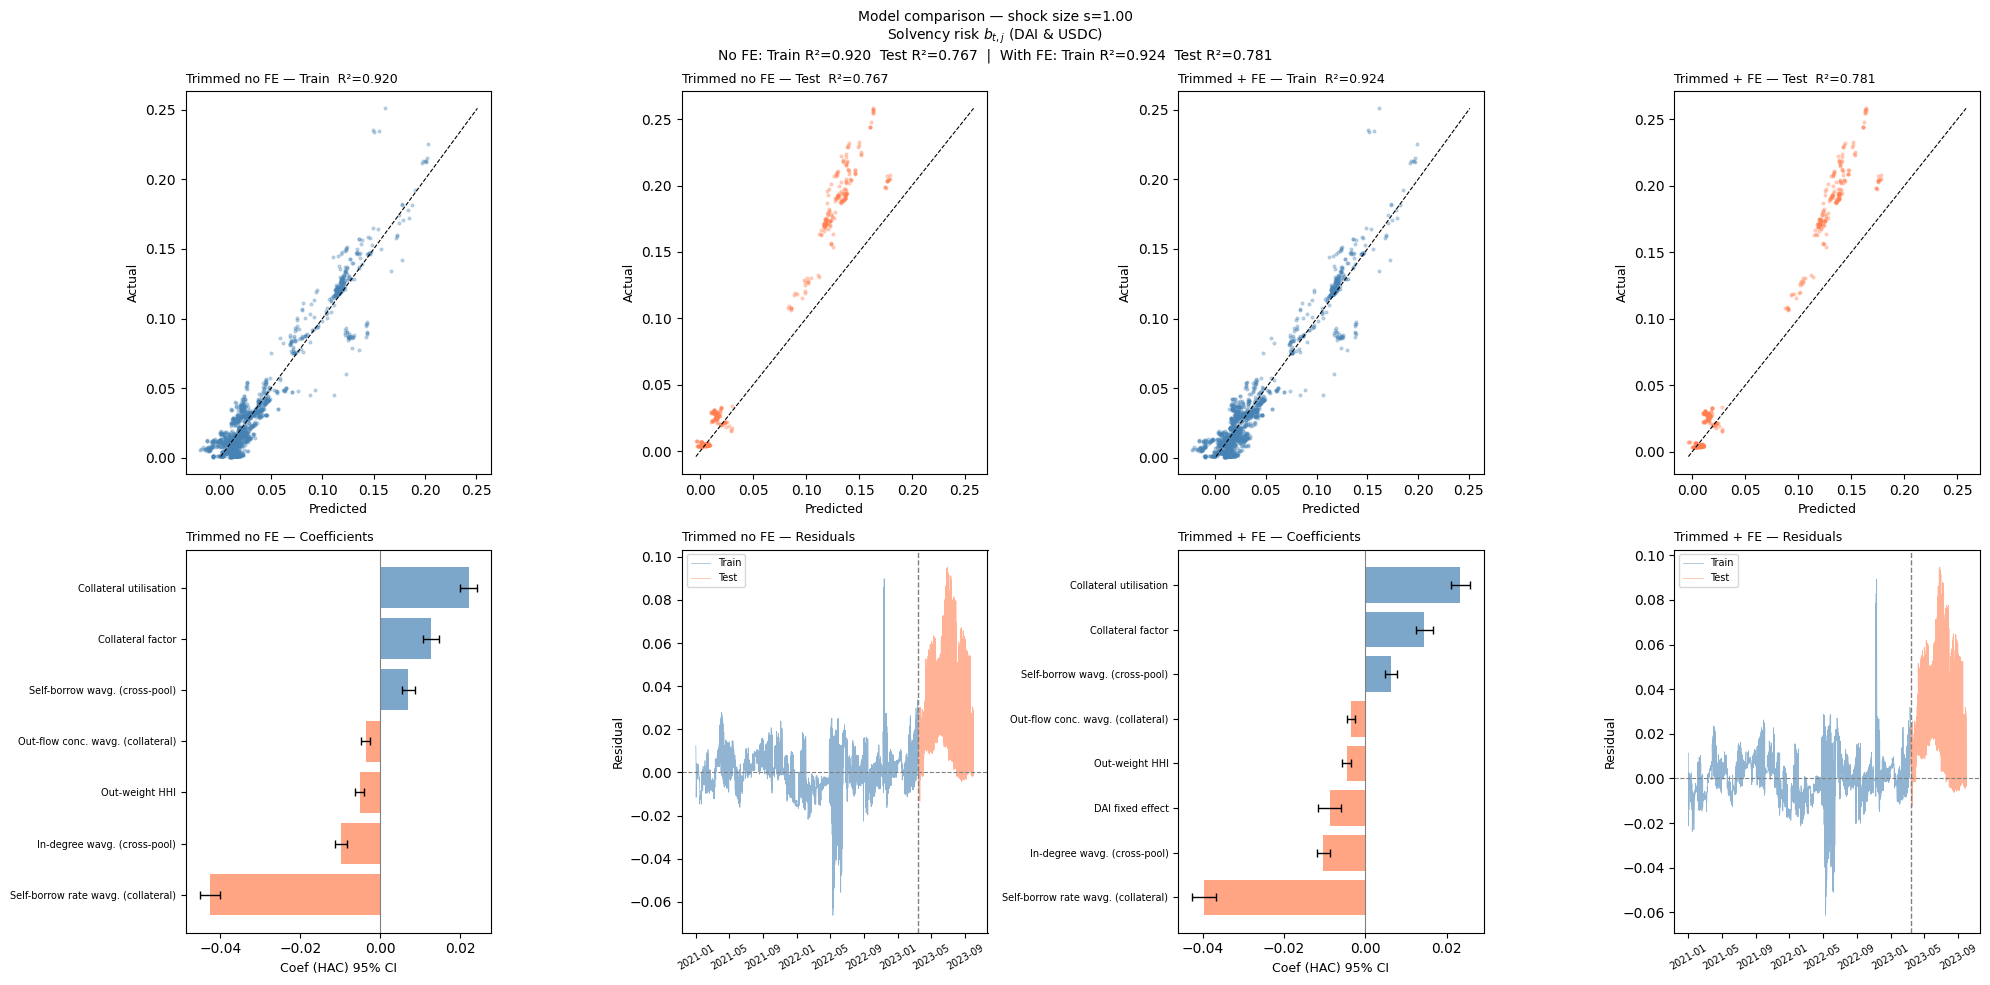

Saved: summary_trim_fe_comparison_size100_stablecoins.pdf


In [83]:
import copy
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# ── Config ────────────────────────────────────────────────────────
FOCUS_SIZE       = 1.0
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['DAI', 'USDC']
ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200

GROUPS_flat = [
    'pool_own', 'pool_cross', 'pool_centrality',
    'collaterals_network', 'collaterals_financial',
    #'borrowers_network',   'borrowers_financial',
]

rename_map = {
    'pctUsedCollateral':               'Collateral utilisation',
    'self_borrow_2':                   'Self-borrowing rate',
    'utilization_ratio':               'Utilisation ratio',
    'collateralFactor':                'Collateral factor',
    'in_degree':                       'In-degree',
    'in_weight_hhi':                   'In-weight HHI',
    'out_degree':                      'Out-degree',
    'out_weight_hhi':                  'Out-weight HHI',
    'pagerank':                        'PageRank',
    'pagerank_scaled':                 'PageRank (scaled)',
    'hub':                             'Hub score',
    'hub_scaled':                      'Hub score (scaled)',
    'pools_hhiDeposit':                'Deposit HHI (cross-pool)',
    'pools_hhiBorrow':                 'Borrow HHI (cross-pool)',
    'pools_in_degree_std':             'In-degree dispersion (cross-pool)',
    'pools_out_degree_std':            'Out-degree dispersion (cross-pool)',
    'pools_pctSelfBorrow_std':         'Self-borrow dispersion (cross-pool)',
    'pools_out_degree_wavg':           'Out-degree wavg. (cross-pool)',
    'pools_in_degree_wavg':            'In-degree wavg. (cross-pool)',
    'pools_pctSelfBorrow_wavg':        'Self-borrow wavg. (cross-pool)',
    'collaterals-in_degree-wavg':      'In-degree wavg. (collateral)',
    'collaterals-in_weight-wavg':      'In-flow weight wavg. (collateral)',
    'collaterals-in_weight_hhi-wavg':  'In-flow conc. wavg. (collateral)',
    'collaterals-out_degree-wavg':     'Out-degree wavg. (collateral)',
    'collaterals-out_weight-wavg':     'Out-flow weight wavg. (collateral)',
    'collaterals-out_weight_hhi-wavg': 'Out-flow conc. wavg. (collateral)',
    'collaterals-pctSelfBorrow-wavg':  'Self-borrow rate wavg. (collateral)',
    'collaterals-pctUsedCollateral-wavg': 'Collateral utilisation wavg. (collateral)',
    'collaterals-health-wavg':         'Health ratio wavg. (collateral)',
    'collaterals-pctDeposit-wavg':     'Deposit share wavg. (collateral)',
    'borrowers-in_degree-wavg':        'In-degree wavg. (borrower)',
    'borrowers-in_weight-wavg':        'In-flow weight wavg. (borrower)',
    'borrowers-in_weight_hhi-wavg':    'In-flow conc. wavg. (borrower)',
    'borrowers-out_degree-wavg':       'Out-degree wavg. (borrower)',
    'borrowers-out_weight-wavg':       'Out-flow weight wavg. (borrower)',
    'borrowers-out_weight_hhi-wavg':   'Out-flow conc. wavg. (borrower)',
    'borrowers-pctSelfBorrow-wavg':    'Self-borrow rate wavg. (borrower)',
    'borrowers-pctUsedCollateral-wavg':'Collateral utilisation wavg. (borrower)',
    'borrowers-health-wavg':           'Health ratio wavg. (borrower)',
    'borrowers-pctDeposit-wavg':       'Deposit share wavg. (borrower)',
    'fe_DAI':                          'DAI fixed effect',
}

def get_renamed_params(model):
    params   = model.params.drop('const')
    ci       = model.conf_int().drop('const')
    params_r = params.rename(index=lambda v: rename_map.get(v, v))
    ci_r     = ci.rename(index=lambda v: rename_map.get(v, v))
    return params_r, ci_r

# ── 1. Build sample ───────────────────────────────────────────────
regr100 = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['size']             == FOCUS_SIZE) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == HEALTH_THRESHOLD)
].copy()

n_dai  = (regr100['shockAsset'] == 'DAI').sum()
n_usdc = (regr100['shockAsset'] == 'USDC').sum()
print(f"Sample: N={len(regr100)}  (DAI={n_dai}, USDC={n_usdc})")

# ── 2. Build X / y ────────────────────────────────────────────────
theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
available        = [v for v in theory_vars_flat if v in regr100.columns]

X_th  = regr100[available].copy()
y_th  = regr100['share_B'].copy()
dt_th = regr100['date'].copy()

row_mask = X_th.notna().all(axis=1) & y_th.notna()
X_th  = X_th.loc[row_mask]; y_th = y_th.loc[row_mask]; dt_th = dt_th.loc[row_mask]
X_th  = X_th.loc[:, X_th.std() > 0]; available = list(X_th.columns)

# ── 3. Train / test split ─────────────────────────────────────────
end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
X_th = X_th[end_mask]; y_th = y_th[end_mask]; dt_th = dt_th[end_mask]

n_total = len(y_th)
n_test  = int(n_total * TEST_SIZE)
n_train = n_total - n_test

X_tr_raw = X_th.iloc[:n_train]; X_te_raw = X_th.iloc[n_train:]
y_tr     = y_th.iloc[:n_train]; y_te     = y_th.iloc[n_train:]
dates_tr = dt_th.iloc[:n_train]; dates_te = dt_th.iloc[n_train:]

print(f"Train: N={n_train}  {dates_tr.min().date()} → {dates_tr.max().date()}")
print(f"Test:  N={n_test}   {dates_te.min().date()} → {dates_te.max().date()}")

# ── 4. Scale ──────────────────────────────────────────────────────
scaler  = StandardScaler()
X_tr_sc = pd.DataFrame(
    scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
)
X_te_sc = pd.DataFrame(
    scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
)

# ── 5. Full OLS ───────────────────────────────────────────────────
model_hac = sm.OLS(y_tr, sm.add_constant(X_tr_sc)).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)
print(f"[Full OLS]  Train R²={model_hac.rsquared:.4f}  N vars={len(available)}")

# ── 6. LASSO ──────────────────────────────────────────────────────
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
lasso_cv = LassoCV(
    cv=tscv, n_alphas=LAMBDA_GRID_SIZE, max_iter=10_000, random_state=42
)
lasso_cv.fit(X_tr_sc, y_tr)

coefs_min    = pd.Series(lasso_cv.coef_, index=available)
selected_min = coefs_min[coefs_min != 0].index.tolist()
if not selected_min:
    selected_min = available
print(f"[LASSO]  λ_min={lasso_cv.alpha_:.6f}  ({len(selected_min)} vars)")

# ── 7. OLS on LASSO-selected vars ────────────────────────────────
model_lasso = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected_min])).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)
print(f"[LASSO OLS]  Train R²={model_lasso.rsquared:.4f}  N vars={len(selected_min)}")

# ── 8. Trimmed model — no FE ──────────────────────────────────────
sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < ALPHA]
if not sig_vars:
    print("*** No significant vars at ALPHA — relaxing to p<0.05.")
    sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < 0.05]

model_trim = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig_vars])).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)
y_pred_te = model_trim.predict(
    sm.add_constant(X_te_sc[sig_vars], has_constant='add')
)
res_te  = y_te - y_pred_te
r2_test = 1 - (res_te**2).sum() / ((y_te - y_te.mean())**2).sum()
n_vars  = len(sig_vars)
print(f"[Trimmed no FE]  Train R²={model_trim.rsquared:.4f}  "
      f"Test R²={r2_test:.4f}  N vars={n_vars}")

# ── 9. Trimmed model — with DAI FE ───────────────────────────────
X_tr_sc['fe_DAI'] = (
    regr100.loc[X_tr_raw.index, 'shockAsset'] == 'DAI'
).astype(float).values
X_te_sc['fe_DAI'] = (
    regr100.loc[X_te_raw.index, 'shockAsset'] == 'DAI'
).astype(float).values

sig_vars_fe   = list(dict.fromkeys(sig_vars + ['fe_DAI']))
model_trim_fe = sm.OLS(
    y_tr.astype(float),
    sm.add_constant(X_tr_sc[sig_vars_fe].astype(float))
).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})

y_pred_te_fe = model_trim_fe.predict(
    sm.add_constant(X_te_sc[sig_vars_fe].astype(float), has_constant='add')
)
res_te_fe  = y_te - y_pred_te_fe
r2_test_fe = 1 - (res_te_fe**2).sum() / ((y_te - y_te.mean())**2).sum()
n_vars_fe  = len(sig_vars_fe)
print(f"[Trimmed + FE]   Train R²={model_trim_fe.rsquared:.4f}  "
      f"Test R²={r2_test_fe:.4f}  N vars={n_vars_fe}")

X_tr_sc.drop(columns=['fe_DAI'], inplace=True, errors='ignore')
X_te_sc.drop(columns=['fe_DAI'], inplace=True, errors='ignore')

# ── 10. 2 × 4 comparison figure ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f'Model comparison — shock size s={FOCUS_SIZE:.2f}\n'
    f'Solvency risk $b_{{t,j}}$ (DAI & USDC)\n'
    f'No FE: Train R²={model_trim.rsquared:.3f}  Test R²={r2_test:.3f}  |  '
    f'With FE: Train R²={model_trim_fe.rsquared:.3f}  Test R²={r2_test_fe:.3f}',
    fontsize=10
)

for col_idx, (model, y_pred, res_plot, label, r2_te_) in enumerate([
    (model_trim,    y_pred_te,    res_te,    'Trimmed no FE', r2_test),
    (model_trim_fe, y_pred_te_fe, res_te_fe, 'Trimmed + FE',  r2_test_fe),
]):
    # actual vs predicted — train
    ax = axes[0, col_idx * 2]
    ax.scatter(model.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')
    lims = [y_tr.min(), y_tr.max()]
    ax.plot(lims, lims, 'k--', lw=0.8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(f'{label} — Train  R²={model.rsquared:.3f}', fontsize=9, loc='left')

    # actual vs predicted — test
    ax = axes[0, col_idx * 2 + 1]
    ax.scatter(y_pred, y_te, s=4, alpha=0.3, color='coral')
    lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=0.8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(f'{label} — Test  R²={r2_te_:.3f}', fontsize=9, loc='left')

    # coefficients
    ax = axes[1, col_idx * 2]
    params_r, ci_r = get_renamed_params(model)
    order_r = params_r.sort_values().index
    y_pos   = range(len(order_r))
    ax.barh(y_pos, params_r[order_r],
            color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
            alpha=0.7)
    ax.errorbar(
        params_r[order_r], y_pos,
        xerr=[params_r[order_r] - ci_r.loc[order_r, 0],
              ci_r.loc[order_r, 1] - params_r[order_r]],
        fmt='none', color='black', capsize=3, lw=1
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order_r, fontsize=7)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlabel('Coef (HAC) 95% CI', fontsize=9)
    ax.set_title(f'{label} — Coefficients', fontsize=9, loc='left')

    # residuals over time
    ax = axes[1, col_idx * 2 + 1]
    ax.plot(dates_tr, model.resid.values,
            color='steelblue', lw=0.5, alpha=0.6, label='Train')
    ax.plot(dates_te, res_plot.values,
            color='coral', lw=0.5, alpha=0.6, label='Test')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
    ax.set_ylabel('Residual', fontsize=9)
    ax.set_title(f'{label} — Residuals', fontsize=9, loc='left')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.tight_layout()
plt.savefig('summary_trim_fe_comparison_size100_stablecoins.pdf',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: summary_trim_fe_comparison_size100_stablecoins.pdf")

Sample: N=2524  (DAI=1262, USDC=1262)
Train: N=1607  2021-01-01 → 2023-03-15
Test:  N=401   2023-03-15 → 2023-10-01
[Full OLS]  Train R²=0.9671  N vars=30
[LASSO]  λ_min=0.000480  (13 vars)
[LASSO OLS]  Train R²=0.9306  N vars=13
[Trimmed + FE]  Train R²=0.9242  Test R²=0.7808  N vars=8


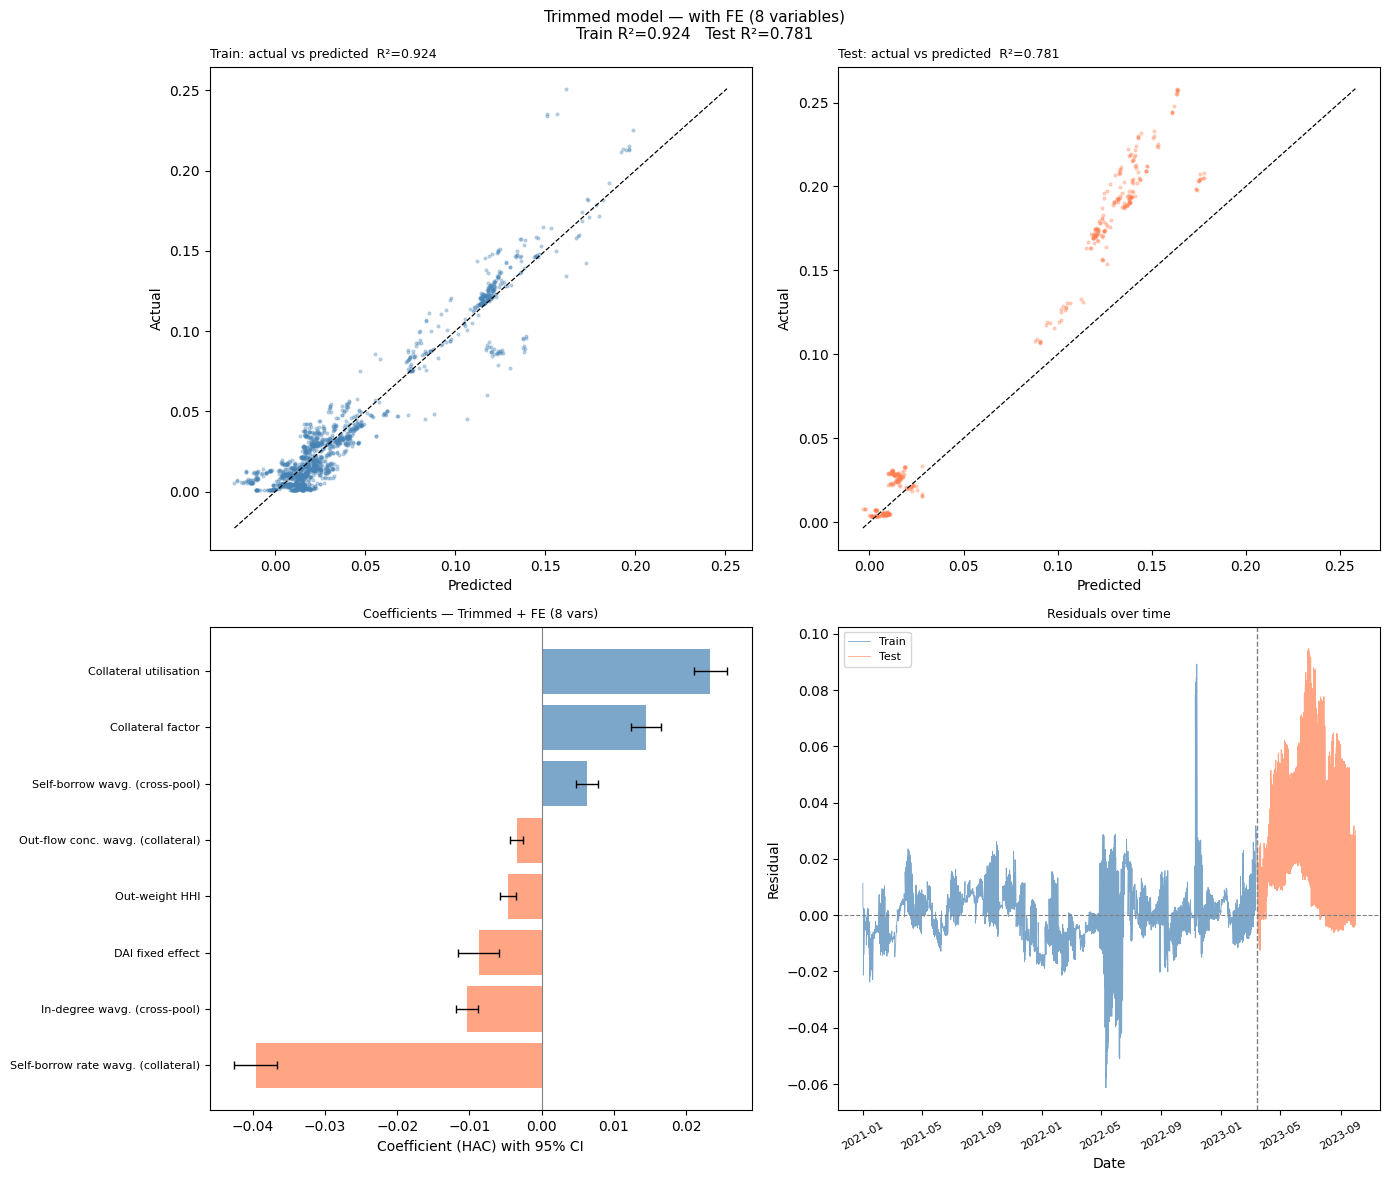

Saved: summary_trim_fe_size100_stablecoins.pdf


In [84]:
import copy
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# ── Config ────────────────────────────────────────────────────────
FOCUS_SIZE       = 1.0
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['DAI', 'USDC']
ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200

GROUPS_flat = [
    'pool_own', 'pool_cross', 'pool_centrality',
    'collaterals_network', 'collaterals_financial',
    #'borrowers_network',   'borrowers_financial',
]

rename_map = {
    'pctUsedCollateral':               'Collateral utilisation',
    'self_borrow_2':                   'Self-borrowing rate',
    'utilization_ratio':               'Utilisation ratio',
    'collateralFactor':                'Collateral factor',
    'in_degree':                       'In-degree',
    'in_weight_hhi':                   'In-weight HHI',
    'out_degree':                      'Out-degree',
    'out_weight_hhi':                  'Out-weight HHI',
    'pagerank':                        'PageRank',
    'pagerank_scaled':                 'PageRank (scaled)',
    'hub':                             'Hub score',
    'hub_scaled':                      'Hub score (scaled)',
    'pools_hhiDeposit':                'Deposit HHI (cross-pool)',
    'pools_hhiBorrow':                 'Borrow HHI (cross-pool)',
    'pools_in_degree_std':             'In-degree dispersion (cross-pool)',
    'pools_out_degree_std':            'Out-degree dispersion (cross-pool)',
    'pools_pctSelfBorrow_std':         'Self-borrow dispersion (cross-pool)',
    'pools_out_degree_wavg':           'Out-degree wavg. (cross-pool)',
    'pools_in_degree_wavg':            'In-degree wavg. (cross-pool)',
    'pools_pctSelfBorrow_wavg':        'Self-borrow wavg. (cross-pool)',
    'collaterals-in_degree-wavg':      'In-degree wavg. (collateral)',
    'collaterals-in_weight-wavg':      'In-flow weight wavg. (collateral)',
    'collaterals-in_weight_hhi-wavg':  'In-flow conc. wavg. (collateral)',
    'collaterals-out_degree-wavg':     'Out-degree wavg. (collateral)',
    'collaterals-out_weight-wavg':     'Out-flow weight wavg. (collateral)',
    'collaterals-out_weight_hhi-wavg': 'Out-flow conc. wavg. (collateral)',
    'collaterals-pctSelfBorrow-wavg':  'Self-borrow rate wavg. (collateral)',
    'collaterals-pctUsedCollateral-wavg': 'Collateral utilisation wavg. (collateral)',
    'collaterals-health-wavg':         'Health ratio wavg. (collateral)',
    'collaterals-pctDeposit-wavg':     'Deposit share wavg. (collateral)',
    'fe_DAI':                          'DAI fixed effect',
}

def get_renamed_params(model):
    params   = model.params.drop('const')
    ci       = model.conf_int().drop('const')
    params_r = params.rename(index=lambda v: rename_map.get(v, v))
    ci_r     = ci.rename(index=lambda v: rename_map.get(v, v))
    return params_r, ci_r

# ── 1. Build sample ───────────────────────────────────────────────
regr100 = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['size']             == FOCUS_SIZE) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == HEALTH_THRESHOLD)
].copy()

n_dai  = (regr100['shockAsset'] == 'DAI').sum()
n_usdc = (regr100['shockAsset'] == 'USDC').sum()
print(f"Sample: N={len(regr100)}  (DAI={n_dai}, USDC={n_usdc})")

# ── 2. Build X / y ────────────────────────────────────────────────
theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
available        = [v for v in theory_vars_flat if v in regr100.columns]

X_th  = regr100[available].copy()
y_th  = regr100['share_B'].copy()
dt_th = regr100['date'].copy()

row_mask = X_th.notna().all(axis=1) & y_th.notna()
X_th  = X_th.loc[row_mask]; y_th = y_th.loc[row_mask]; dt_th = dt_th.loc[row_mask]
X_th  = X_th.loc[:, X_th.std() > 0]; available = list(X_th.columns)

# ── 3. Train / test split ─────────────────────────────────────────
end_mask = dt_th.values <= pd.Timestamp(TEST_END_DATE)
X_th = X_th[end_mask]; y_th = y_th[end_mask]; dt_th = dt_th[end_mask]

n_total = len(y_th)
n_test  = int(n_total * TEST_SIZE)
n_train = n_total - n_test

X_tr_raw = X_th.iloc[:n_train]; X_te_raw = X_th.iloc[n_train:]
y_tr     = y_th.iloc[:n_train]; y_te     = y_th.iloc[n_train:]
dates_tr = dt_th.iloc[:n_train]; dates_te = dt_th.iloc[n_train:]

print(f"Train: N={n_train}  {dates_tr.min().date()} → {dates_tr.max().date()}")
print(f"Test:  N={n_test}   {dates_te.min().date()} → {dates_te.max().date()}")

# ── 4. Scale ──────────────────────────────────────────────────────
scaler  = StandardScaler()
X_tr_sc = pd.DataFrame(
    scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
)
X_te_sc = pd.DataFrame(
    scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
)

# ── 5. Full OLS ───────────────────────────────────────────────────
model_hac = sm.OLS(y_tr, sm.add_constant(X_tr_sc)).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)
print(f"[Full OLS]  Train R²={model_hac.rsquared:.4f}  N vars={len(available)}")

# ── 6. LASSO ──────────────────────────────────────────────────────
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
lasso_cv = LassoCV(
    cv=tscv, n_alphas=LAMBDA_GRID_SIZE, max_iter=10_000, random_state=42
)
lasso_cv.fit(X_tr_sc, y_tr)

coefs_min    = pd.Series(lasso_cv.coef_, index=available)
selected_min = coefs_min[coefs_min != 0].index.tolist()
if not selected_min:
    selected_min = available
print(f"[LASSO]  λ_min={lasso_cv.alpha_:.6f}  ({len(selected_min)} vars)")

# ── 7. OLS on LASSO-selected vars ────────────────────────────────
model_lasso = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected_min])).fit(
    cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
)
print(f"[LASSO OLS]  Train R²={model_lasso.rsquared:.4f}  N vars={len(selected_min)}")

# ── 8. Trimmed model — no FE ──────────────────────────────────────
sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < ALPHA]
if not sig_vars:
    print("*** No significant vars at ALPHA — relaxing to p<0.05.")
    sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < 0.05]

# ── 9. Trimmed model — with DAI FE ───────────────────────────────
X_tr_sc['fe_DAI'] = (
    regr100.loc[X_tr_raw.index, 'shockAsset'] == 'DAI'
).astype(float).values
X_te_sc['fe_DAI'] = (
    regr100.loc[X_te_raw.index, 'shockAsset'] == 'DAI'
).astype(float).values

sig_vars_fe   = list(dict.fromkeys(sig_vars + ['fe_DAI']))
model_trim_fe = sm.OLS(
    y_tr.astype(float),
    sm.add_constant(X_tr_sc[sig_vars_fe].astype(float))
).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})

y_pred_te_fe = model_trim_fe.predict(
    sm.add_constant(X_te_sc[sig_vars_fe].astype(float), has_constant='add')
)
res_te_fe  = y_te - y_pred_te_fe
r2_test_fe = 1 - (res_te_fe**2).sum() / ((y_te - y_te.mean())**2).sum()
n_vars_fe  = len(sig_vars_fe)
print(f"[Trimmed + FE]  Train R²={model_trim_fe.rsquared:.4f}  "
      f"Test R²={r2_test_fe:.4f}  N vars={n_vars_fe}")

X_tr_sc.drop(columns=['fe_DAI'], inplace=True, errors='ignore')
X_te_sc.drop(columns=['fe_DAI'], inplace=True, errors='ignore')

# ── 10. 2 × 2 figure — FE model only ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    f'Trimmed model — with FE ({n_vars_fe} variables)\n'
    f'Train R²={model_trim_fe.rsquared:.3f}   Test R²={r2_test_fe:.3f}',
    fontsize=11
)

# Panel A: Train actual vs predicted
ax = axes[0, 0]
ax.scatter(model_trim_fe.fittedvalues, y_tr, s=4, alpha=0.3, color='steelblue')
lims = [min(y_tr.min(), model_trim_fe.fittedvalues.min()),
        max(y_tr.max(), model_trim_fe.fittedvalues.max())]
ax.plot(lims, lims, 'k--', lw=0.9)
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('Actual', fontsize=10)
ax.set_title(f'Train: actual vs predicted  R²={model_trim_fe.rsquared:.3f}',
             fontsize=9, loc='left')

# Panel B: Test actual vs predicted
ax = axes[0, 1]
ax.scatter(y_pred_te_fe, y_te, s=4, alpha=0.3, color='coral')
lims = [min(y_te.min(), y_pred_te_fe.min()), max(y_te.max(), y_pred_te_fe.max())]
ax.plot(lims, lims, 'k--', lw=0.9)
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('Actual', fontsize=10)
ax.set_title(f'Test: actual vs predicted  R²={r2_test_fe:.3f}',
             fontsize=9, loc='left')

# Panel C: Coefficients
ax = axes[1, 0]
params_r, ci_r = get_renamed_params(model_trim_fe)
order_r = params_r.sort_values().index
y_pos   = range(len(order_r))
ax.barh(y_pos, params_r[order_r],
        color=['coral' if v < 0 else 'steelblue' for v in params_r[order_r]],
        alpha=0.7)
ax.errorbar(
    params_r[order_r], y_pos,
    xerr=[params_r[order_r] - ci_r.loc[order_r, 0],
          ci_r.loc[order_r, 1] - params_r[order_r]],
    fmt='none', color='black', capsize=3, lw=1
)
ax.set_yticks(y_pos)
ax.set_yticklabels(order_r, fontsize=8)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Coefficient (HAC) with 95% CI', fontsize=10)
ax.set_title(f'Coefficients — Trimmed + FE ({n_vars_fe} vars)',
             fontsize=9, loc='center')

# Panel D: Residuals over time
ax = axes[1, 1]
ax.plot(dates_tr, model_trim_fe.resid.values,
        color='steelblue', lw=0.6, alpha=0.7, label='Train')
ax.plot(dates_te, res_te_fe.values,
        color='coral', lw=0.6, alpha=0.7, label='Test')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(dates_te.min(), color='gray', ls='--', lw=1)
ax.set_ylabel('Residual', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.set_title('Residuals over time', fontsize=9, loc='center')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig('summary_trim_fe_size100_stablecoins.pdf',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved: summary_trim_fe_size100_stablecoins.pdf")

In [85]:
# ══════════════════════════════════════════════════════════════════
# Descriptive statistics table — updated with stablecoin columns
#
# Crypto:     ETH & WBTC at s = 0.50
# Stablecoin: DAI & USDC at s = 1.00
#
# Paste AFTER final_updated and break_date are defined.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

HEALTH_THRESHOLD = 10
END_DATE         = '2024-06-15'

# ── Pull subsamples ───────────────────────────────────────────────
def get_sample(assets, shock_size):
    return final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['date']             <= pd.Timestamp(END_DATE)) &
        (final_updated['size']             == shock_size) &
        (final_updated['shockAsset'].isin(assets)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

eth  = get_sample(['ETH'],  0.50)
wbtc = get_sample(['WBTC'], 0.50)
dai  = get_sample(['DAI'],  1.00)
usdc = get_sample(['USDC'], 1.00)

for df in [eth, wbtc, dai, usdc]:
    if 'shareT_pool' not in df.columns:
        df['shareT_pool'] = (df['T_pool'] - df['Tp_pool']) / df['assets']
    if 'share_B' not in df.columns:
        df['share_B'] = df['B'] / df['assets']
    df['liq_risk'] = df['shareT_pool'].abs()

for name, df in [('ETH', eth), ('WBTC', wbtc), ('DAI', dai), ('USDC', usdc)]:
    print(f"{name}: N={len(df)}  "
          f"dates: {df['date'].min().date()} → {df['date'].max().date()}")

# ── Helpers ───────────────────────────────────────────────────────
def ms(df, col):
    if col not in df.columns or df[col].isna().all():
        return None, None
    return df[col].mean(), df[col].std()

def fmt(val, scale=1, decimals=4):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return '---'
    return f'{val * scale:.{decimals}f}'

def fmt_M(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return '---'
    return f'{val/1e6:.2f}M'

samples = {'ETH': eth, 'WBTC': wbtc, 'DAI': dai, 'USDC': usdc}

def row_stats(col, decimals=4, is_M=False):
    out = {}
    for name, df in samples.items():
        m, s = ms(df, col)
        if is_M:
            out[name] = (fmt_M(m), fmt_M(s))
        else:
            out[name] = (fmt(m, decimals=decimals), fmt(s, decimals=decimals))
    return out

# Cross-pool: protocol-level, identical across all assets on a given date
# Use ETH subsample (drop_duplicates on date)
cross_pool = eth.drop_duplicates(subset='date')

def cross_row_stats(col, decimals=4):
    m, s = ms(cross_pool, col)
    return (fmt(m, decimals=decimals), fmt(s, decimals=decimals))

# ── Collect stats ─────────────────────────────────────────────────
liq   = row_stats('liq_risk',   decimals=4)
solv  = row_stats('share_B',    decimals=4)
pctu  = row_stats('pctUsedCollateral',  decimals=4)
sb2   = row_stats('self_borrow_2',      decimals=4)
ur    = row_stats('utilization_ratio',  decimals=4)
cf    = row_stats('collateralFactor',   decimals=4)
indeg = row_stats('in_degree',          decimals=2)
iwhhi = row_stats('in_weight_hhi',      decimals=4)
odeg  = row_stats('out_degree',         decimals=2)
owhhi = row_stats('out_weight_hhi',     decimals=4)

pr    = row_stats('pagerank',        decimals=4)
prs   = row_stats('pagerank_scaled', decimals=4)
hub   = row_stats('hub',             decimals=4)
hubs  = row_stats('hub_scaled',      decimals=4)

cp_dep = cross_row_stats('pools_hhiDeposit',        decimals=4)
cp_bor = cross_row_stats('pools_hhiBorrow',         decimals=4)
cp_ids = cross_row_stats('pools_in_degree_std',     decimals=2)
cp_ods = cross_row_stats('pools_out_degree_std',    decimals=2)
cp_sbs = cross_row_stats('pools_pctSelfBorrow_std', decimals=4)
cp_odw = cross_row_stats('pools_out_degree_wavg',   decimals=2)
cp_idw = cross_row_stats('pools_in_degree_wavg',    decimals=2)
cp_sbw = cross_row_stats('pools_pctSelfBorrow_wavg',decimals=4)

cn_ind  = row_stats('collaterals-in_degree-wavg',      decimals=4)
cn_inw  = row_stats('collaterals-in_weight-wavg',      is_M=True)
cn_ihhi = row_stats('collaterals-in_weight_hhi-wavg',  decimals=4)
cn_oud  = row_stats('collaterals-out_degree-wavg',     decimals=4)
cn_ouw  = row_stats('collaterals-out_weight-wavg',     is_M=True)
cn_ohhi = row_stats('collaterals-out_weight_hhi-wavg', decimals=4)

cf_sb = row_stats('collaterals-pctSelfBorrow-wavg',      decimals=4)
cf_cu = row_stats('collaterals-pctUsedCollateral-wavg',  decimals=4)
cf_hr = row_stats('collaterals-health-wavg',             decimals=4)
cf_ds = row_stats('collaterals-pctDeposit-wavg',         decimals=4)

# ── LaTeX helpers ─────────────────────────────────────────────────
def twoMS(d, key):
    m, s = d[key]
    return f'{m} & {s}'

def crossMS(t):
    m, s = t
    return f'{m} & {s}'

# ── Build LaTeX ───────────────────────────────────────────────────
tex = r"""\begin{table}[ht]
\centering
\begin{threeparttable}
\caption{Descriptive statistics --- Crypto sample (ETH and WBTC, $s = 0.5$)
         and Stablecoin sample (DAI and USDC, $s = 1.0$),
         1 January 2021 -- 15 June 2024}
\label{tab:desc_stats}
\footnotesize
\begin{tabular}{lrrrrrrrr}
\toprule
& \multicolumn{2}{c}{ETH} & \multicolumn{2}{c}{WBTC}
& \multicolumn{2}{c}{DAI} & \multicolumn{2}{c}{USDC} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}
\cmidrule(lr){6-7}\cmidrule(lr){8-9}
Variable & Mean & Std & Mean & Std & Mean & Std & Mean & Std \\
\midrule
\multicolumn{9}{l}{\textit{Outcome variables}} \\""" + f"""
Liquidity risk ($\\ell$) & {twoMS(liq,'ETH')} & {twoMS(liq,'WBTC')} & \\multicolumn{{2}}{{c}}{{---}} & \\multicolumn{{2}}{{c}}{{---}} \\\\
Bad debt share ($b$) & {twoMS(solv,'ETH')} & {twoMS(solv,'WBTC')} & {twoMS(solv,'DAI')} & {twoMS(solv,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Own-pool characteristics}} \\""" + f"""
Collateral utilisation & {twoMS(pctu,'ETH')} & {twoMS(pctu,'WBTC')} & {twoMS(pctu,'DAI')} & {twoMS(pctu,'USDC')} \\\\
Self-borrowing rate & {twoMS(sb2,'ETH')} & {twoMS(sb2,'WBTC')} & {twoMS(sb2,'DAI')} & {twoMS(sb2,'USDC')} \\\\
Utilisation ratio & {twoMS(ur,'ETH')} & {twoMS(ur,'WBTC')} & {twoMS(ur,'DAI')} & {twoMS(ur,'USDC')} \\\\
Collateral factor & {twoMS(cf,'ETH')} & {twoMS(cf,'WBTC')} & {twoMS(cf,'DAI')} & {twoMS(cf,'USDC')} \\\\
In-degree & {twoMS(indeg,'ETH')} & {twoMS(indeg,'WBTC')} & {twoMS(indeg,'DAI')} & {twoMS(indeg,'USDC')} \\\\
In-weight HHI & {twoMS(iwhhi,'ETH')} & {twoMS(iwhhi,'WBTC')} & {twoMS(iwhhi,'DAI')} & {twoMS(iwhhi,'USDC')} \\\\
Out-degree & {twoMS(odeg,'ETH')} & {twoMS(odeg,'WBTC')} & {twoMS(odeg,'DAI')} & {twoMS(odeg,'USDC')} \\\\
Out-weight HHI & {twoMS(owhhi,'ETH')} & {twoMS(owhhi,'WBTC')} & {twoMS(owhhi,'DAI')} & {twoMS(owhhi,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Pool centrality}} \\""" + f"""
PageRank & {twoMS(pr,'ETH')} & {twoMS(pr,'WBTC')} & {twoMS(pr,'DAI')} & {twoMS(pr,'USDC')} \\\\
PageRank (scaled) & {twoMS(prs,'ETH')} & {twoMS(prs,'WBTC')} & {twoMS(prs,'DAI')} & {twoMS(prs,'USDC')} \\\\
Hub score & {twoMS(hub,'ETH')} & {twoMS(hub,'WBTC')} & {twoMS(hub,'DAI')} & {twoMS(hub,'USDC')} \\\\
Hub score (scaled) & {twoMS(hubs,'ETH')} & {twoMS(hubs,'WBTC')} & {twoMS(hubs,'DAI')} & {twoMS(hubs,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Cross-pool linkages}$^{a}$} \\
\cmidrule(lr){2-3}
\multicolumn{1}{l}{} & \multicolumn{2}{c}{All assets} & \multicolumn{6}{c}{} \\
\cmidrule(lr){2-3}""" + f"""
Deposit concentration (HHI) & {crossMS(cp_dep)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Borrowing concentration (HHI) & {crossMS(cp_bor)} & \\multicolumn{{6}}{{c}}{{}} \\\\
In-degree dispersion & {crossMS(cp_ids)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Out-degree dispersion & {crossMS(cp_ods)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Self-borrowing dispersion & {crossMS(cp_sbs)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Out-degree (wavg.) & {crossMS(cp_odw)} & \\multicolumn{{6}}{{c}}{{}} \\\\
In-degree (wavg.) & {crossMS(cp_idw)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Self-borrowing share (wavg.) & {crossMS(cp_sbw)} & \\multicolumn{{6}}{{c}}{{}} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Collateral network features}} \\""" + f"""
In-degree (wavg.) & {twoMS(cn_ind,'ETH')} & {twoMS(cn_ind,'WBTC')} & {twoMS(cn_ind,'DAI')} & {twoMS(cn_ind,'USDC')} \\\\
In-flow weight (wavg.) & {twoMS(cn_inw,'ETH')} & {twoMS(cn_inw,'WBTC')} & {twoMS(cn_inw,'DAI')} & {twoMS(cn_inw,'USDC')} \\\\
In-flow weight HHI (wavg.) & {twoMS(cn_ihhi,'ETH')} & {twoMS(cn_ihhi,'WBTC')} & {twoMS(cn_ihhi,'DAI')} & {twoMS(cn_ihhi,'USDC')} \\\\
Out-degree (wavg.) & {twoMS(cn_oud,'ETH')} & {twoMS(cn_oud,'WBTC')} & {twoMS(cn_oud,'DAI')} & {twoMS(cn_oud,'USDC')} \\\\
Out-flow weight (wavg.) & {twoMS(cn_ouw,'ETH')} & {twoMS(cn_ouw,'WBTC')} & {twoMS(cn_ouw,'DAI')} & {twoMS(cn_ouw,'USDC')} \\\\
Out-flow weight HHI (wavg.) & {twoMS(cn_ohhi,'ETH')} & {twoMS(cn_ohhi,'WBTC')} & {twoMS(cn_ohhi,'DAI')} & {twoMS(cn_ohhi,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Collateral financial features}} \\""" + f"""
Self-borrowing rate (wavg.) & {twoMS(cf_sb,'ETH')} & {twoMS(cf_sb,'WBTC')} & {twoMS(cf_sb,'DAI')} & {twoMS(cf_sb,'USDC')} \\\\
Collateral utilisation (wavg.) & {twoMS(cf_cu,'ETH')} & {twoMS(cf_cu,'WBTC')} & {twoMS(cf_cu,'DAI')} & {twoMS(cf_cu,'USDC')} \\\\
Health ratio (wavg.) & {twoMS(cf_hr,'ETH')} & {twoMS(cf_hr,'WBTC')} & {twoMS(cf_hr,'DAI')} & {twoMS(cf_hr,'USDC')} \\\\
Deposit share (wavg.) & {twoMS(cf_ds,'ETH')} & {twoMS(cf_ds,'WBTC')} & {twoMS(cf_ds,'DAI')} & {twoMS(cf_ds,'USDC')} \\\\
""" + r"""\bottomrule
\end{tabular}
\begin{tablenotes}[flushleft]
\setlength{\itemsep}{0pt}
\setlength{\parsep}{0pt}
\footnotesize
\item \textit{Notes}: Statistics computed on the post-break sample
(1 January 2021 -- 15 June 2024). Crypto columns (ETH, WBTC) use
shock size $s = 0.5$; stablecoin columns (DAI, USDC) use $s = 1.0$.
Health threshold $= 10$. $\ell_{t,a}$ is the liquidity risk and
$b_{t,a}$ is the solvency risk, both defined in
Section~\ref{sec:empirical} and expressed as proportions in $[0,1]$.
Liquidity risk is not reported for stablecoins at $s = 1.0$ as a full
price wipeout mechanically produces zero liquidations.
Wavg.\ denotes value-weighted average over the set of collateral
providers at the pool level. HHI denotes the Herfindahl--Hirschman
index. In-flow and out-flow weights are expressed in millions of
dollars (M).
\item[$a$] Cross-pool linkage variables are computed at the protocol
level and are therefore identical across all assets on any given date.
Statistics are reported once for the full sample.
\end{tablenotes}
\end{threeparttable}
\end{table}"""

fname = 'table_desc_stats_updated.tex'
with open(fname, 'w') as f:
    f.write(tex)
print(f"Saved: {fname}")
print()
print(tex)

ETH: N=1262  dates: 2021-01-01 → 2024-06-15
WBTC: N=1262  dates: 2021-01-01 → 2024-06-15
DAI: N=1262  dates: 2021-01-01 → 2024-06-15
USDC: N=1262  dates: 2021-01-01 → 2024-06-15
Saved: table_desc_stats_updated.tex

\begin{table}[ht]
\centering
\begin{threeparttable}
\caption{Descriptive statistics --- Crypto sample (ETH and WBTC, $s = 0.5$)
         and Stablecoin sample (DAI and USDC, $s = 1.0$),
         1 January 2021 -- 15 June 2024}
\label{tab:desc_stats}
\footnotesize
\begin{tabular}{lrrrrrrrr}
\toprule
& \multicolumn{2}{c}{ETH} & \multicolumn{2}{c}{WBTC}
& \multicolumn{2}{c}{DAI} & \multicolumn{2}{c}{USDC} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}
\cmidrule(lr){6-7}\cmidrule(lr){8-9}
Variable & Mean & Std & Mean & Std & Mean & Std & Mean & Std \\
\midrule
\multicolumn{9}{l}{\textit{Outcome variables}} \\
Liquidity risk ($\ell$) & 0.1357 & 0.0423 & 0.0137 & 0.0423 & \multicolumn{2}{c}{---} & \multicolumn{2}{c}{---} \\
Bad debt share ($b$) & 0.0236 & 0.0151 & 0.0077 & 0.0062 & 0.016

In [86]:
# ══════════════════════════════════════════════════════════════════
# Descriptive statistics table — updated with stablecoin columns
#
# Crypto:     ETH & WBTC at s = 0.50
# Stablecoin: DAI & USDC at s = 1.00
#
# Paste AFTER final_updated and break_date are defined.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

HEALTH_THRESHOLD = 10
END_DATE         = '2024-06-15'

# ── Pull subsamples ───────────────────────────────────────────────
def get_sample(assets, shock_size):
    return final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['date']             <= pd.Timestamp(END_DATE)) &
        (final_updated['size']             == shock_size) &
        (final_updated['shockAsset'].isin(assets)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

eth  = get_sample(['ETH'],  0.50)
wbtc = get_sample(['WBTC'], 0.50)
dai  = get_sample(['DAI'],  1.00)
usdc = get_sample(['USDC'], 1.00)

for df in [eth, wbtc, dai, usdc]:
    if 'shareT_pool' not in df.columns:
        df['shareT_pool'] = (df['T_pool'] - df['Tp_pool']) / df['assets']
    if 'share_B' not in df.columns:
        df['share_B'] = df['B'] / df['assets']
    df['liq_risk'] = df['shareT_pool'].abs()

for name, df in [('ETH', eth), ('WBTC', wbtc), ('DAI', dai), ('USDC', usdc)]:
    print(f"{name}: N={len(df)}  "
          f"dates: {df['date'].min().date()} → {df['date'].max().date()}")

# ── Helpers ───────────────────────────────────────────────────────
def ms(df, col):
    if col not in df.columns or df[col].isna().all():
        return None, None
    return df[col].mean(), df[col].std()

def fmt(val, scale=1, decimals=4):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return '---'
    return f'{val * scale:.{decimals}f}'

def fmt_M(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return '---'
    return f'{val/1e6:.2f}M'

samples = {'ETH': eth, 'WBTC': wbtc, 'DAI': dai, 'USDC': usdc}

def row_stats(col, decimals=4, is_M=False):
    out = {}
    for name, df in samples.items():
        m, s = ms(df, col)
        if is_M:
            out[name] = (fmt_M(m), fmt_M(s))
        else:
            out[name] = (fmt(m, decimals=decimals), fmt(s, decimals=decimals))
    return out

# Cross-pool: protocol-level, identical across all assets on a given date
# Use ETH subsample (drop_duplicates on date)
cross_pool = eth.drop_duplicates(subset='date')

def cross_row_stats(col, decimals=4):
    m, s = ms(cross_pool, col)
    return (fmt(m, decimals=decimals), fmt(s, decimals=decimals))

# ── Collect stats ─────────────────────────────────────────────────
liq   = row_stats('liq_risk',   decimals=4)
solv  = row_stats('share_B',    decimals=4)
pctu  = row_stats('pctUsedCollateral',  decimals=4)
sb2   = row_stats('self_borrow_2',      decimals=4)
ur    = row_stats('utilization_ratio',  decimals=4)
cf    = row_stats('collateralFactor',   decimals=4)
indeg = row_stats('in_degree',          decimals=2)
iwhhi = row_stats('in_weight_hhi',      decimals=4)
odeg  = row_stats('out_degree',         decimals=2)
owhhi = row_stats('out_weight_hhi',     decimals=4)

pr    = row_stats('pagerank',        decimals=4)
prs   = row_stats('pagerank_scaled', decimals=4)
hub   = row_stats('hub',             decimals=4)
hubs  = row_stats('hub_scaled',      decimals=4)

cp_dep = cross_row_stats('pools_hhiDeposit',        decimals=4)
cp_bor = cross_row_stats('pools_hhiBorrow',         decimals=4)
cp_ids = cross_row_stats('pools_in_degree_std',     decimals=2)
cp_ods = cross_row_stats('pools_out_degree_std',    decimals=2)
cp_sbs = cross_row_stats('pools_pctSelfBorrow_std', decimals=4)
cp_odw = cross_row_stats('pools_out_degree_wavg',   decimals=2)
cp_idw = cross_row_stats('pools_in_degree_wavg',    decimals=2)
cp_sbw = cross_row_stats('pools_pctSelfBorrow_wavg',decimals=4)

cn_ind  = row_stats('collaterals-in_degree-wavg',      decimals=4)
cn_inw  = row_stats('collaterals-in_weight-wavg',      is_M=True)
cn_ihhi = row_stats('collaterals-in_weight_hhi-wavg',  decimals=4)
cn_oud  = row_stats('collaterals-out_degree-wavg',     decimals=4)
cn_ouw  = row_stats('collaterals-out_weight-wavg',     is_M=True)
cn_ohhi = row_stats('collaterals-out_weight_hhi-wavg', decimals=4)

cf_sb = row_stats('collaterals-pctSelfBorrow-wavg',      decimals=4)
cf_cu = row_stats('collaterals-pctUsedCollateral-wavg',  decimals=4)
cf_hr = row_stats('collaterals-health-wavg',             decimals=4)
cf_ds = row_stats('collaterals-pctDeposit-wavg',         decimals=4)

# ── Borrower network features ─────────────────────────────────────
bn_ind  = row_stats('borrowers-in_degree-wavg',      decimals=4)
bn_inw  = row_stats('borrowers-in_weight-wavg',      is_M=True)
bn_ihhi = row_stats('borrowers-in_weight_hhi-wavg',  decimals=4)
bn_oud  = row_stats('borrowers-out_degree-wavg',     decimals=4)
bn_ouw  = row_stats('borrowers-out_weight-wavg',     is_M=True)
bn_ohhi = row_stats('borrowers-out_weight_hhi-wavg', decimals=4)

# ── Borrower financial features ───────────────────────────────────
bf_sb = row_stats('borrowers-pctSelfBorrow-wavg',      decimals=4)
bf_cu = row_stats('borrowers-pctUsedCollateral-wavg',  decimals=4)
bf_hr = row_stats('borrowers-health-wavg',             decimals=4)
bf_ds = row_stats('borrowers-pctDeposit-wavg',         decimals=4)

# ── LaTeX helpers ─────────────────────────────────────────────────
def twoMS(d, key):
    m, s = d[key]
    return f'{m} & {s}'

def crossMS(t):
    m, s = t
    return f'{m} & {s}'

NOTES_COMMON = r"""
\begin{tablenotes}[flushleft]
\setlength{\itemsep}{0pt}
\setlength{\parsep}{0pt}
\scriptsize
\item \textit{Notes}: Post-break sample, 1 January 2021 --
15 June 2024. Crypto columns use $s = 0.5$; stablecoin
columns use $s = 1.0$. Health threshold $= 10$: collateral
provider averages include only users with health ratio below
this value; results are insensitive to this choice within
the empirically relevant range. $\ell_{t,j}$ and $b_{t,j}$
are defined in Section~\ref{sec:empirical}; liquidity risk
is not reported for stablecoins as a full de-pegging
produces zero reserve losses by construction. Wavg.:
value-weighted average over collateral providers or
borrowers. HHI: Herfindahl--Hirschman index. Flow weights
in millions of dollars.
\item[$a$] Cross-pool variables are protocol-level and
identical across assets on any given date; reported once.
\end{tablenotes}
\end{threeparttable}
\end{table}"""

HEADER = r"""& \multicolumn{2}{c}{ETH} & \multicolumn{2}{c}{WBTC}
& \multicolumn{2}{c}{DAI} & \multicolumn{2}{c}{USDC} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}
\cmidrule(lr){6-7}\cmidrule(lr){8-9}
Variable & Mean & Std & Mean & Std & Mean & Std & Mean & Std \\
\midrule"""

# ══════════════════════════════════════════════════════════════════
# TABLE 5a: Pool characteristics + collateral features
# ══════════════════════════════════════════════════════════════════
tex_a = r"""\begin{table}[ht]
\centering
\begin{threeparttable}
\caption{Descriptive statistics (Panel A) ---
         Pool characteristics and collateral provider features,
         1 January 2021 -- 15 June 2024}
\label{tab:desc_stats_a}
\footnotesize
\begin{tabular}{lrrrrrrrr}
\toprule
""" + HEADER + f"""
\multicolumn{{9}}{{l}}{{\\textit{{Outcome variables}}}} \\\\
Liquidity risk ($\\ell$) & {twoMS(liq,'ETH')} & {twoMS(liq,'WBTC')} & \\multicolumn{{2}}{{c}}{{---}} & \\multicolumn{{2}}{{c}}{{---}} \\\\
Bad debt share ($b$) & {twoMS(solv,'ETH')} & {twoMS(solv,'WBTC')} & {twoMS(solv,'DAI')} & {twoMS(solv,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Own-pool characteristics}} \\""" + f"""
Collateral utilisation & {twoMS(pctu,'ETH')} & {twoMS(pctu,'WBTC')} & {twoMS(pctu,'DAI')} & {twoMS(pctu,'USDC')} \\\\
Self-borrowing rate & {twoMS(sb2,'ETH')} & {twoMS(sb2,'WBTC')} & {twoMS(sb2,'DAI')} & {twoMS(sb2,'USDC')} \\\\
Utilisation ratio & {twoMS(ur,'ETH')} & {twoMS(ur,'WBTC')} & {twoMS(ur,'DAI')} & {twoMS(ur,'USDC')} \\\\
Collateral factor & {twoMS(cf,'ETH')} & {twoMS(cf,'WBTC')} & {twoMS(cf,'DAI')} & {twoMS(cf,'USDC')} \\\\
In-degree & {twoMS(indeg,'ETH')} & {twoMS(indeg,'WBTC')} & {twoMS(indeg,'DAI')} & {twoMS(indeg,'USDC')} \\\\
In-weight HHI & {twoMS(iwhhi,'ETH')} & {twoMS(iwhhi,'WBTC')} & {twoMS(iwhhi,'DAI')} & {twoMS(iwhhi,'USDC')} \\\\
Out-degree & {twoMS(odeg,'ETH')} & {twoMS(odeg,'WBTC')} & {twoMS(odeg,'DAI')} & {twoMS(odeg,'USDC')} \\\\
Out-weight HHI & {twoMS(owhhi,'ETH')} & {twoMS(owhhi,'WBTC')} & {twoMS(owhhi,'DAI')} & {twoMS(owhhi,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Pool centrality}} \\""" + f"""
PageRank (scaled) & {twoMS(prs,'ETH')} & {twoMS(prs,'WBTC')} & {twoMS(prs,'DAI')} & {twoMS(prs,'USDC')} \\\\
Hub score (scaled) & {twoMS(hubs,'ETH')} & {twoMS(hubs,'WBTC')} & {twoMS(hubs,'DAI')} & {twoMS(hubs,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Cross-pool linkages}$^{a}$} \\
\cmidrule(lr){2-3}
\multicolumn{1}{l}{} & \multicolumn{2}{c}{All assets} & \multicolumn{6}{c}{} \\
\cmidrule(lr){2-3}""" + f"""
Deposit concentration (HHI) & {crossMS(cp_dep)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Borrowing concentration (HHI) & {crossMS(cp_bor)} & \\multicolumn{{6}}{{c}}{{}} \\\\
In-degree dispersion & {crossMS(cp_ids)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Out-degree dispersion & {crossMS(cp_ods)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Self-borrowing dispersion & {crossMS(cp_sbs)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Out-degree (wavg.) & {crossMS(cp_odw)} & \\multicolumn{{6}}{{c}}{{}} \\\\
In-degree (wavg.) & {crossMS(cp_idw)} & \\multicolumn{{6}}{{c}}{{}} \\\\
Self-borrowing share (wavg.) & {crossMS(cp_sbw)} & \\multicolumn{{6}}{{c}}{{}} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Collateral network features}} \\""" + f"""
In-degree (wavg.) & {twoMS(cn_ind,'ETH')} & {twoMS(cn_ind,'WBTC')} & {twoMS(cn_ind,'DAI')} & {twoMS(cn_ind,'USDC')} \\\\
In-flow weight (wavg.) & {twoMS(cn_inw,'ETH')} & {twoMS(cn_inw,'WBTC')} & {twoMS(cn_inw,'DAI')} & {twoMS(cn_inw,'USDC')} \\\\
In-flow weight HHI (wavg.) & {twoMS(cn_ihhi,'ETH')} & {twoMS(cn_ihhi,'WBTC')} & {twoMS(cn_ihhi,'DAI')} & {twoMS(cn_ihhi,'USDC')} \\\\
Out-degree (wavg.) & {twoMS(cn_oud,'ETH')} & {twoMS(cn_oud,'WBTC')} & {twoMS(cn_oud,'DAI')} & {twoMS(cn_oud,'USDC')} \\\\
Out-flow weight (wavg.) & {twoMS(cn_ouw,'ETH')} & {twoMS(cn_ouw,'WBTC')} & {twoMS(cn_ouw,'DAI')} & {twoMS(cn_ouw,'USDC')} \\\\
Out-flow weight HHI (wavg.) & {twoMS(cn_ohhi,'ETH')} & {twoMS(cn_ohhi,'WBTC')} & {twoMS(cn_ohhi,'DAI')} & {twoMS(cn_ohhi,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Collateral financial features}} \\""" + f"""
Self-borrowing rate (wavg.) & {twoMS(cf_sb,'ETH')} & {twoMS(cf_sb,'WBTC')} & {twoMS(cf_sb,'DAI')} & {twoMS(cf_sb,'USDC')} \\\\
Collateral utilisation (wavg.) & {twoMS(cf_cu,'ETH')} & {twoMS(cf_cu,'WBTC')} & {twoMS(cf_cu,'DAI')} & {twoMS(cf_cu,'USDC')} \\\\
Health ratio (wavg.) & {twoMS(cf_hr,'ETH')} & {twoMS(cf_hr,'WBTC')} & {twoMS(cf_hr,'DAI')} & {twoMS(cf_hr,'USDC')} \\\\
Deposit share (wavg.) & {twoMS(cf_ds,'ETH')} & {twoMS(cf_ds,'WBTC')} & {twoMS(cf_ds,'DAI')} & {twoMS(cf_ds,'USDC')} \\\\
""" + r"""\bottomrule
\end{tabular}""" + NOTES_COMMON

# ══════════════════════════════════════════════════════════════════
# TABLE 5b: Borrower features
# ══════════════════════════════════════════════════════════════════
tex_b = r"""\begin{table}[ht]
\centering
\begin{threeparttable}
\caption{Descriptive statistics (Panel B) ---
         Borrower features,
         1 January 2021 -- 15 June 2024}
\label{tab:desc_stats_b}
\footnotesize
\begin{tabular}{lrrrrrrrr}
\toprule
""" + HEADER + r"""
\multicolumn{9}{l}{\textit{Borrower network features}} \\""" + f"""
In-degree (wavg.) & {twoMS(bn_ind,'ETH')} & {twoMS(bn_ind,'WBTC')} & {twoMS(bn_ind,'DAI')} & {twoMS(bn_ind,'USDC')} \\\\
In-flow weight (wavg.) & {twoMS(bn_inw,'ETH')} & {twoMS(bn_inw,'WBTC')} & {twoMS(bn_inw,'DAI')} & {twoMS(bn_inw,'USDC')} \\\\
In-flow weight HHI (wavg.) & {twoMS(bn_ihhi,'ETH')} & {twoMS(bn_ihhi,'WBTC')} & {twoMS(bn_ihhi,'DAI')} & {twoMS(bn_ihhi,'USDC')} \\\\
Out-degree (wavg.) & {twoMS(bn_oud,'ETH')} & {twoMS(bn_oud,'WBTC')} & {twoMS(bn_oud,'DAI')} & {twoMS(bn_oud,'USDC')} \\\\
Out-flow weight (wavg.) & {twoMS(bn_ouw,'ETH')} & {twoMS(bn_ouw,'WBTC')} & {twoMS(bn_ouw,'DAI')} & {twoMS(bn_ouw,'USDC')} \\\\
Out-flow weight HHI (wavg.) & {twoMS(bn_ohhi,'ETH')} & {twoMS(bn_ohhi,'WBTC')} & {twoMS(bn_ohhi,'DAI')} & {twoMS(bn_ohhi,'USDC')} \\\\
""" + r"""\midrule
\multicolumn{9}{l}{\textit{Borrower financial features}} \\""" + f"""
Self-borrowing rate (wavg.) & {twoMS(bf_sb,'ETH')} & {twoMS(bf_sb,'WBTC')} & {twoMS(bf_sb,'DAI')} & {twoMS(bf_sb,'USDC')} \\\\
Collateral utilisation (wavg.) & {twoMS(bf_cu,'ETH')} & {twoMS(bf_cu,'WBTC')} & {twoMS(bf_cu,'DAI')} & {twoMS(bf_cu,'USDC')} \\\\
Health ratio (wavg.) & {twoMS(bf_hr,'ETH')} & {twoMS(bf_hr,'WBTC')} & {twoMS(bf_hr,'DAI')} & {twoMS(bf_hr,'USDC')} \\\\
Deposit share (wavg.) & {twoMS(bf_ds,'ETH')} & {twoMS(bf_ds,'WBTC')} & {twoMS(bf_ds,'DAI')} & {twoMS(bf_ds,'USDC')} \\\\
""" + r"""\bottomrule
\end{tabular}""" + NOTES_COMMON

# ── Save both tables ──────────────────────────────────────────────
for fname, tex in [('table_desc_stats_a.tex', tex_a),
                   ('table_desc_stats_b.tex', tex_b)]:
    with open(fname, 'w') as f:
        f.write(tex)
    print(f"Saved: {fname}")

print("\n--- TABLE A ---\n")
print(tex_a)
print("\n--- TABLE B ---\n")
print(tex_b)

ETH: N=1262  dates: 2021-01-01 → 2024-06-15
WBTC: N=1262  dates: 2021-01-01 → 2024-06-15
DAI: N=1262  dates: 2021-01-01 → 2024-06-15
USDC: N=1262  dates: 2021-01-01 → 2024-06-15
Saved: table_desc_stats_a.tex
Saved: table_desc_stats_b.tex

--- TABLE A ---

\begin{table}[ht]
\centering
\begin{threeparttable}
\caption{Descriptive statistics (Panel A) ---
         Pool characteristics and collateral provider features,
         1 January 2021 -- 15 June 2024}
\label{tab:desc_stats_a}
\footnotesize
\begin{tabular}{lrrrrrrrr}
\toprule
& \multicolumn{2}{c}{ETH} & \multicolumn{2}{c}{WBTC}
& \multicolumn{2}{c}{DAI} & \multicolumn{2}{c}{USDC} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}
\cmidrule(lr){6-7}\cmidrule(lr){8-9}
Variable & Mean & Std & Mean & Std & Mean & Std & Mean & Std \\
\midrule
\multicolumn{9}{l}{\textit{Outcome variables}} \\
Liquidity risk ($\ell$) & 0.1357 & 0.0423 & 0.0137 & 0.0423 & \multicolumn{2}{c}{---} & \multicolumn{2}{c}{---} \\
Bad debt share ($b$) & 0.0236 & 0.0151 & 0.00

In [87]:
print("Date range in final_updated:")
print(f"  Min: {final_updated['date'].min()}")
print(f"  Max: {final_updated['date'].max()}")

print("\nObservations per year (before break_date filter):")
print(final_updated['date'].dt.year.value_counts().sort_index())

print("\nMissing values in key features before 2021-01-01:")
pre = final_updated[final_updated['date'] < '2021-01-01']
print(f"  N rows before break_date: {len(pre)}")
if len(pre) > 0:
    theory_vars = [v for g in GROUPS_flat for v in features[g]]
    available = [v for v in theory_vars if v in pre.columns]
    print(f"  Missing predictors:\n{pre[available].isna().mean().sort_values(ascending=False).head(10)}")
    print(f"\n  Missing outcome (shareT_pool): {pre['shareT_pool'].isna().mean():.2%}")

Date range in final_updated:
  Min: 2020-01-01 00:00:00
  Max: 2024-06-15 00:00:00

Observations per year (before break_date filter):
date
2020    56160
2021    64014
2022    68164
2023    68985
2024    31523
Name: count, dtype: int64

Missing values in key features before 2021-01-01:
  N rows before break_date: 56160
  Missing predictors:
pctUsedCollateral                     0.0
self_borrow_2                         0.0
collaterals-health-wavg               0.0
collaterals-pctUsedCollateral-wavg    0.0
collaterals-pctSelfBorrow-wavg        0.0
collaterals-out_weight_hhi-wavg       0.0
collaterals-out_weight-wavg           0.0
collaterals-out_degree-wavg           0.0
collaterals-in_weight_hhi-wavg        0.0
collaterals-in_weight-wavg            0.0
dtype: float64

  Missing outcome (shareT_pool): 8.71%


In [88]:
pre = final_updated[final_updated['date'] < '2021-01-01'].copy()

print("Missing shareT_pool by shockAsset and year-month:")
pre['ym'] = pre['date'].dt.to_period('M')
pivot = pre.groupby(['shockAsset', 'ym'])['shareT_pool'].apply(
    lambda x: x.isna().mean()
).round(3).unstack()
print(pivot)

print("\nOverall missing rate by shockAsset (pre-2021):")
print(pre.groupby('shockAsset')['shareT_pool'].apply(
    lambda x: x.isna().mean()
).round(3).sort_values(ascending=False))

Missing shareT_pool by shockAsset and year-month:
ym          2020-01  2020-02  2020-03  2020-04  2020-05  2020-06  2020-07  2020-08  2020-09  2020-10  2020-11  2020-12
shockAsset                                                                                                            
BAT             1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0
COMP            NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN      1.0      1.0      1.0
DAI             0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
ETH             0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
REP             1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0
SAI             1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.

In [89]:
# ══════════════════════════════════════════════════════════════════
# Sample size proof — ETH only vs ETH+WBTC pooled
# Liquidity risk (shareT_pool), s = 0.50
#
# Runs the full LASSO → OLS → trim pipeline on:
#   (a) ETH only
#   (b) WBTC only
#   (c) ETH + WBTC pooled (baseline)
#
# Paste AFTER the main liquidity loop has run so that all
# globals (features, GROUPS_flat, rename_map, break_date,
# TEST_END_DATE, TEST_SIZE, HAC_MAXLAGS, ALPHA, LAMBDA_GRID_SIZE,
# N_SPLITS, HEALTH_THRESHOLD) are defined.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

TARGET_SHOCK = 0.50

def run_pipeline(asset_list, label):
    """Run full LASSO→OLS→trim pipeline for a given asset list."""

    # ── 1. Build sample ──────────────────────────────────────────
    regr = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['date']             <= pd.Timestamp(TEST_END_DATE)) &
        (final_updated['size']             == TARGET_SHOCK) &
        (final_updated['shockAsset'].isin(asset_list)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    theory_vars = [v for g in GROUPS_flat for v in features[g]]
    available   = [v for v in theory_vars if v in regr.columns]

    X_th  = regr[available].copy()
    y_th  = regr['shareT_pool'].copy()
    dt_th = regr['date'].copy()

    mask  = X_th.notna().all(axis=1) & y_th.notna()
    X_th  = X_th.loc[mask]; y_th = y_th.loc[mask]; dt_th = dt_th.loc[mask]
    X_th  = X_th.loc[:, X_th.std() > 0]; available = list(X_th.columns)

    # ── 2. Train/test split ───────────────────────────────────────
    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    X_tr_raw = X_th.iloc[:n_train]; X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]; y_te     = y_th.iloc[n_train:]
    dates_tr = dt_th.iloc[:n_train]; dates_te = dt_th.iloc[n_train:]

    # ── 3. Scale ──────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    # ── 4. LASSO ──────────────────────────────────────────────────
    tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_cv = LassoCV(
        cv=tscv, n_alphas=LAMBDA_GRID_SIZE, max_iter=10_000, random_state=42
    )
    lasso_cv.fit(X_tr_sc, y_tr)

    coefs_min    = pd.Series(lasso_cv.coef_, index=available)
    selected_min = coefs_min[coefs_min != 0].index.tolist()
    if not selected_min:
        selected_min = available

    # ── 5. OLS on LASSO-selected ──────────────────────────────────
    model_lasso = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected_min])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )

    # ── 6. Trim at ALPHA ──────────────────────────────────────────
    sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < ALPHA]
    if not sig_vars:
        sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < 0.05]

    model_trim  = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig_vars])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    y_pred_trim = model_trim.predict(
        sm.add_constant(X_te_sc[sig_vars], has_constant='add')
    )
    res_trim  = y_te - y_pred_trim
    r2_test   = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse      = np.sqrt((res_trim**2).mean())

    # ── 7. Subsampling stability (50 draws, drop 10% of train) ────
    rng     = np.random.default_rng(42)
    r2_draws = []
    for _ in range(50):
        keep_idx = rng.choice(n_train, size=int(n_train * 0.9), replace=False)
        keep_idx = np.sort(keep_idx)
        X_tr_sub = X_tr_sc.iloc[keep_idx][sig_vars]
        y_tr_sub = y_tr.iloc[keep_idx]
        m_sub    = sm.OLS(y_tr_sub, sm.add_constant(X_tr_sub)).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        y_pred_sub = m_sub.predict(
            sm.add_constant(X_te_sc[sig_vars], has_constant='add')
        )
        res_sub = y_te - y_pred_sub
        r2_sub  = 1 - (res_sub**2).sum() / ((y_te - y_te.mean())**2).sum()
        r2_draws.append(r2_sub)

    r2_draws = np.array(r2_draws)

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  N total:       {n_total:>6}  (train={n_train}, test={n_test})")
    print(f"  LASSO vars:    {len(selected_min):>6}")
    print(f"  Trimmed vars:  {len(sig_vars):>6}")
    print(f"  Train R²:      {model_trim.rsquared:>7.3f}")
    print(f"  Test  R²:      {r2_test:>7.3f}")
    print(f"  RMSE:          {rmse:>7.4f}")
    print(f"  Subsampling test R² (50 draws):")
    print(f"    Mean:  {r2_draws.mean():>7.3f}")
    print(f"    Std:   {r2_draws.std():>7.3f}")
    print(f"    Min:   {r2_draws.min():>7.3f}")
    print(f"    Max:   {r2_draws.max():>7.3f}")
    print(f"    IQR:   [{np.percentile(r2_draws,25):.3f}, "
          f"{np.percentile(r2_draws,75):.3f}]")

    return {
        'label':        label,
        'n_total':      n_total,
        'n_train':      n_train,
        'n_test':       n_test,
        'n_vars_lasso': len(selected_min),
        'n_vars_trim':  len(sig_vars),
        'r2_train':     model_trim.rsquared,
        'r2_test':      r2_test,
        'rmse':         rmse,
        'r2_sub_mean':  r2_draws.mean(),
        'r2_sub_std':   r2_draws.std(),
        'r2_sub_iqr':   np.percentile(r2_draws, 75) - np.percentile(r2_draws, 25),
    }

# ── Run for each sample ───────────────────────────────────────────
results_eth    = run_pipeline(['ETH'],         'ETH only')
results_wbtc   = run_pipeline(['WBTC'],        'WBTC only')
results_pooled = run_pipeline(['ETH', 'WBTC'], 'ETH + WBTC pooled (baseline)')

# ── Summary table ─────────────────────────────────────────────────
print("\n\n" + "=" * 75)
print("  SUMMARY — ETH only vs WBTC only vs Pooled")
print("=" * 75)
print(f"  {'Sample':<28} {'N_train':>8} {'Vars':>5} "
      f"{'Train R²':>9} {'Test R²':>8} {'Sub Mean':>9} {'Sub Std':>8} {'Sub IQR':>8}")
print("  " + "-" * 75)
for r in [results_eth, results_wbtc, results_pooled]:
    print(f"  {r['label']:<28} {r['n_train']:>8} {r['n_vars_trim']:>5} "
          f"{r['r2_train']:>9.3f} {r['r2_test']:>8.3f} "
          f"{r['r2_sub_mean']:>9.3f} {r['r2_sub_std']:>8.3f} "
          f"{r['r2_sub_iqr']:>8.3f}")

print("""
Interpretation:
  - Test R² gap between single-asset and pooled specs shows
    the predictive cost of a smaller sample.
  - Subsampling std and IQR measure stability: higher values
    indicate the model is sensitive to which observations are
    included, i.e. the sample is borderline for reliable estimation.
  - The pooled spec should show both higher test R² and narrower
    subsampling dispersion, proving that pooling is necessary for
    reliable out-of-sample prediction.
""")


  ETH only
  N total:         1004  (train=804, test=200)
  LASSO vars:        22
  Trimmed vars:       9
  Train R²:        0.777
  Test  R²:       -0.178
  RMSE:           0.0295
  Subsampling test R² (50 draws):
    Mean:   -0.178
    Std:     0.044
    Min:    -0.284
    Max:    -0.099
    IQR:   [-0.203, -0.142]

  WBTC only
  N total:         1004  (train=804, test=200)
  LASSO vars:         6
  Trimmed vars:       4
  Train R²:        0.800
  Test  R²:      -3907.988
  RMSE:           0.0270
  Subsampling test R² (50 draws):
    Mean:  -3938.493
    Std:   149.665
    Min:   -4208.657
    Max:   -3425.576
    IQR:   [-4040.919, -3855.717]

  ETH + WBTC pooled (baseline)
  N total:         2008  (train=1607, test=401)
  LASSO vars:        16
  Trimmed vars:      12
  Train R²:        0.872
  Test  R²:        0.831
  RMSE:           0.0321
  Subsampling test R² (50 draws):
    Mean:    0.830
    Std:     0.005
    Min:     0.822
    Max:     0.840
    IQR:   [0.827, 0.834]


  SU

In [90]:
# ══════════════════════════════════════════════════════════════════
# Distribution of outcomes across train/test periods
# Liquidity risk (shareT_pool) and solvency risk (share_B)
# ETH and WBTC, s = 0.50
#
# Paste AFTER the main liquidity loop has run.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

TARGET_SHOCK     = 0.50
HEALTH_THRESHOLD = 10
TEST_END_DATE    = '2023-10-01'
TEST_SIZE        = 0.20

# ── Build sample ──────────────────────────────────────────────────
regr = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['date']             <= pd.Timestamp(TEST_END_DATE)) &
    (final_updated['size']             == TARGET_SHOCK) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == HEALTH_THRESHOLD)
].copy()

regr['share_B'] = regr['B'] / regr['assets']
regr['liq_risk'] = regr['shareT_pool'].abs()

# ── Chronological split ───────────────────────────────────────────
n_total = len(regr)
n_test  = int(n_total * TEST_SIZE)
n_train = n_total - n_test

regr_sorted = regr.sort_values('date').reset_index(drop=True)
train = regr_sorted.iloc[:n_train]
test  = regr_sorted.iloc[n_train:]

print(f"Train: N={n_train}  "
      f"{train['date'].min().date()} → {train['date'].max().date()}")
print(f"Test:  N={n_test}   "
      f"{test['date'].min().date()} → {test['date'].max().date()}")

# ── Summary statistics ────────────────────────────────────────────
def desc(df, col):
    s = df[col].dropna()
    return {
        'N':    len(s),
        'Mean': s.mean(),
        'Std':  s.std(),
        'Min':  s.min(),
        'P25':  s.quantile(0.25),
        'P50':  s.median(),
        'P75':  s.quantile(0.75),
        'Max':  s.max(),
        'CV':   s.std() / s.mean() if s.mean() != 0 else np.nan,
    }

for outcome, label in [('liq_risk', 'Liquidity risk (ℓ)'),
                        ('share_B',  'Solvency risk (b)')]:
    d_tr = desc(train, outcome)
    d_te = desc(test,  outcome)

    print(f"\n{'='*65}")
    print(f"  {label}  —  s = {TARGET_SHOCK:.2f},  ETH & WBTC")
    print(f"{'='*65}")
    print(f"  {'Statistic':<12} {'Train':>12} {'Test':>12} {'Ratio (Te/Tr)':>14}")
    print(f"  {'-'*52}")
    for k in ['N', 'Mean', 'Std', 'Min', 'P25', 'P50', 'P75', 'Max', 'CV']:
        tr_val = d_tr[k]
        te_val = d_te[k]
        ratio  = te_val / tr_val if tr_val != 0 else np.nan
        if k == 'N':
            print(f"  {k:<12} {int(tr_val):>12} {int(te_val):>12} {'':>14}")
        else:
            print(f"  {k:<12} {tr_val:>12.4f} {te_val:>12.4f} {ratio:>14.3f}")

# ── Variance ratio test ───────────────────────────────────────────
from scipy import stats

print(f"\n{'='*65}")
print("  Variance ratio tests (Levene):  H0 = equal variances")
print(f"{'='*65}")
for outcome, label in [('liq_risk', 'Liquidity risk (ℓ)'),
                        ('share_B',  'Solvency risk (b)')]:
    tr_vals = train[outcome].dropna()
    te_vals = test[outcome].dropna()
    stat, p  = stats.levene(tr_vals, te_vals)
    var_ratio = te_vals.var() / tr_vals.var()
    print(f"  {label}:")
    print(f"    Var(train)={tr_vals.var():.6f}  "
          f"Var(test)={te_vals.var():.6f}  "
          f"Ratio={var_ratio:.3f}")
    print(f"    Levene stat={stat:.3f}  p={p:.4f}  "
          f"{'** significantly different' if p < 0.05 else 'not significantly different'}")

# ── Per-asset breakdown ───────────────────────────────────────────
print(f"\n{'='*65}")
print("  Per-asset breakdown")
print(f"{'='*65}")
for asset in CRYPTO_ASSETS:
    for outcome, label in [('liq_risk', 'ℓ'), ('share_B', 'b')]:
        tr_a = train[train['shockAsset'] == asset][outcome].dropna()
        te_a = test[test['shockAsset']   == asset][outcome].dropna()
        print(f"  {asset} {label}:  "
              f"Train mean={tr_a.mean():.4f} std={tr_a.std():.4f}  |  "
              f"Test  mean={te_a.mean():.4f} std={te_a.std():.4f}  |  "
              f"Std ratio={te_a.std()/tr_a.std():.3f}")

Train: N=1607  2021-01-01 → 2023-03-15
Test:  N=401   2023-03-15 → 2023-10-01

  Liquidity risk (ℓ)  —  s = 0.50,  ETH & WBTC
  Statistic           Train         Test  Ratio (Te/Tr)
  ----------------------------------------------------
  N                    1607          401               
  Mean               0.0270       0.0654          2.420
  Std                0.0318       0.0567          1.785
  Min                0.0005       0.0012          2.474
  P25                0.0055       0.0142          2.588
  P50                0.0141       0.0677          4.812
  P75                0.0327       0.1212          3.706
  Max                0.1663       0.1684          1.013
  CV                 1.1759       0.8671          0.737

  Solvency risk (b)  —  s = 0.50,  ETH & WBTC
  Statistic           Train         Test  Ratio (Te/Tr)
  ----------------------------------------------------
  N                    1607          401               
  Mean               0.0096       0.0404     

In [91]:
for thr in sorted(final_updated['health_threshold'].unique()):
    sub = final_updated[
        (final_updated['size']       == 0.50) &
        (final_updated['shockAsset'] == 'ETH') &
        (final_updated['health_threshold'] == thr) &
        (final_updated['date']       >= break_date)
    ]
    print(f"threshold={thr:>3}  N={len(sub):>5}  "
          f"shareT_pool mean={sub['shareT_pool'].mean():.4f}  "
          f"shareT_pool std={sub['shareT_pool'].std():.4f}  "
          f"share_B mean={(sub['B']/sub['assets']).mean():.4f}")

threshold=5.0  N= 1262  shareT_pool mean=0.1357  shareT_pool std=0.0423  share_B mean=0.0236
threshold=10.0  N= 1262  shareT_pool mean=0.1357  shareT_pool std=0.0423  share_B mean=0.0236
threshold=20.0  N= 1262  shareT_pool mean=0.1357  shareT_pool std=0.0423  share_B mean=0.0236
threshold=nan  N=    0  shareT_pool mean=nan  shareT_pool std=nan  share_B mean=nan


In [92]:
# Check whether features differ across health thresholds
feature_cols = [v for g in GROUPS_flat for v in features[g] 
                if v in final_updated.columns]

print("Checking feature differences across health thresholds")
print("ETH, s=0.50, post break_date\n")

dfs = {}
for thr in [5.0, 10.0, 20.0]:
    dfs[thr] = final_updated[
        (final_updated['size']             == 0.50) &
        (final_updated['shockAsset']       == 'ETH') &
        (final_updated['date']             >= break_date) &
        (final_updated['health_threshold'] == thr)
    ][['date'] + feature_cols].set_index('date')

print(f"{'Feature':<45} {'mean_5':>10} {'mean_10':>10} {'mean_20':>10} "
      f"{'max_diff':>10} {'differs?'}")
print("-" * 100)
for col in feature_cols:
    if col not in dfs[5.0].columns:
        continue
    m5  = dfs[5.0][col].mean()
    m10 = dfs[10.0][col].mean()
    m20 = dfs[20.0][col].mean()
    max_diff = max(abs(m5-m10), abs(m5-m20), abs(m10-m20))
    differs  = "YES" if max_diff > 1e-6 else "no"
    print(f"  {col:<45} {m5:>10.4f} {m10:>10.4f} {m20:>10.4f} "
          f"{max_diff:>10.6f} {differs}")

Checking feature differences across health thresholds
ETH, s=0.50, post break_date

Feature                                           mean_5    mean_10    mean_20   max_diff differs?
----------------------------------------------------------------------------------------------------
  pctUsedCollateral                                 0.3764     0.3764     0.3764   0.000000 no
  self_borrow_2                                     0.0161     0.0161     0.0161   0.000000 no
  utilization_ratio                                 0.0409     0.0409     0.0409   0.000000 no
  collateralFactor                                  0.8043     0.8043     0.8043   0.000000 no
  in_degree                                      1310.8114  1310.8114  1310.8114   0.000000 no
  in_weight_hhi                                     0.1988     0.1988     0.1988   0.000000 no
  out_degree                                    70102.5602 70102.5602 70102.5602   0.000000 no
  out_weight_hhi                                   

In [93]:
# Proper sensitivity check — vary HEALTH_THRESHOLD globally
results_threshold = []

for thr in [5.0, 10.0, 20.0]:
    print(f"\nRunning pipeline for health_threshold = {thr}")
    
    # Temporarily override the global
    _orig = HEALTH_THRESHOLD
    HEALTH_THRESHOLD_TEMP = thr
    
    regr = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['date']             <= pd.Timestamp(TEST_END_DATE)) &
        (final_updated['size']             == 0.50) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == thr)
    ].copy()

    theory_vars = [v for g in GROUPS_flat for v in features[g]]
    available   = [v for v in theory_vars if v in regr.columns]

    X_th  = regr[available].copy()
    y_th  = regr['shareT_pool'].copy()
    dt_th = regr['date'].copy()

    mask  = X_th.notna().all(axis=1) & y_th.notna()
    X_th  = X_th.loc[mask]; y_th = y_th.loc[mask]; dt_th = dt_th.loc[mask]
    X_th  = X_th.loc[:, X_th.std() > 0]; available = list(X_th.columns)

    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    X_tr_raw = X_th.iloc[:n_train]; X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]; y_te     = y_th.iloc[n_train:]

    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_cv = LassoCV(cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
                       max_iter=10_000, random_state=42)
    lasso_cv.fit(X_tr_sc, y_tr)

    coefs_min    = pd.Series(lasso_cv.coef_, index=available)
    selected_min = coefs_min[coefs_min != 0].index.tolist()
    if not selected_min:
        selected_min = available

    model_lasso = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected_min])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )

    sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < ALPHA]
    if not sig_vars:
        sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < 0.05]

    model_trim  = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig_vars])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    y_pred      = model_trim.predict(
        sm.add_constant(X_te_sc[sig_vars], has_constant='add')
    )
    res         = y_te - y_pred
    r2_test     = 1 - (res**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse        = np.sqrt((res**2).mean())

    # Check variable overlap with baseline (threshold=10)
    print(f"  N={n_total}  vars={len(sig_vars)}  "
          f"Train R²={model_trim.rsquared:.3f}  "
          f"Test R²={r2_test:.3f}  RMSE={rmse:.4f}")
    print(f"  Selected: {sig_vars}")
    
    results_threshold.append({
        'threshold': thr,
        'n_vars':    len(sig_vars),
        'r2_train':  model_trim.rsquared,
        'r2_test':   r2_test,
        'rmse':      rmse,
        'sig_vars':  sig_vars,
    })

# Summary
print("\n\nSUMMARY")
print(f"{'Threshold':>10} {'Vars':>5} {'Train R²':>9} {'Test R²':>9} {'RMSE':>8}")
print("-" * 45)
for r in results_threshold:
    star = " ◄ baseline" if r['threshold'] == 10 else ""
    print(f"{r['threshold']:>10} {r['n_vars']:>5} "
          f"{r['r2_train']:>9.3f} {r['r2_test']:>9.3f} "
          f"{r['r2_test']:>8.3f}{star}")


Running pipeline for health_threshold = 5.0
  N=2008  vars=10  Train R²=0.896  Test R²=0.760  RMSE=0.0278
  Selected: ['pctUsedCollateral', 'collateralFactor', 'out_degree', 'out_weight_hhi', 'pools_in_degree_wavg', 'pools_pctSelfBorrow_wavg', 'collaterals-in_degree-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg']

Running pipeline for health_threshold = 10.0
  N=2008  vars=10  Train R²=0.897  Test R²=0.757  RMSE=0.0279
  Selected: ['pctUsedCollateral', 'collateralFactor', 'out_degree', 'out_weight_hhi', 'pools_in_degree_wavg', 'pools_pctSelfBorrow_wavg', 'collaterals-in_degree-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg']

Running pipeline for health_threshold = 20.0
  N=2008  vars=16  Train R²=0.926  Test R²=0.956  RMSE=0.0119
  Selected: ['pctUsedCollateral', 'self_borrow_2', 'utilization_ratio', 'collateralFactor', 'in_weight_hhi', 'out_weight_hhi', 'pools_o

In [94]:
# Check the outcome variable in the main results
res_main = results_by_size.get(0.50)
if res_main:
    print(f"Main model train R²: {res_main['r2_train_trim']:.3f}")
    print(f"Main model test R²:  {res_main['r2_test_trim']:.3f}")
    print(f"Main sig_vars: {res_main['sig_vars']}")
    
    # Check what outcome was used
    regr_check = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['date']             <= pd.Timestamp(TEST_END_DATE)) &
        (final_updated['size']             == 0.50) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == 10)
    ].copy()
    print(f"\nshareT_pool: mean={regr_check['shareT_pool'].mean():.4f} "
          f"std={regr_check['shareT_pool'].std():.4f}")

Main model train R²: 0.872
Main model test R²:  0.831
Main sig_vars: ['pctUsedCollateral', 'utilization_ratio', 'pools_hhiBorrow', 'pools_out_degree_std', 'pools_out_degree_wavg', 'pools_in_degree_wavg', 'pagerank_scaled', 'collaterals-in_degree-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg', 'collaterals-pctUsedCollateral-wavg', 'collaterals-pctDeposit-wavg']

shareT_pool: mean=0.0347 std=0.0410


In [95]:
regr_check = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['date']             <= pd.Timestamp(TEST_END_DATE)) &
    (final_updated['size']             == 0.50) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == 10)
].copy()

# Check all candidate outcome columns
for col in ['shareT_pool', 'shareT_pool_assets', 'T_pool', 'Tp_pool', 
            'assets', 'T', 'Tp']:
    if col in regr_check.columns:
        print(f"{col}: mean={regr_check[col].mean():.6f}  "
              f"std={regr_check[col].std():.6f}")

# Try to reconstruct the main outcome
if all(c in regr_check.columns for c in ['T_pool', 'Tp_pool', 'assets']):
    regr_check['outcome_v2'] = (regr_check['T_pool'] - regr_check['Tp_pool']) / regr_check['assets']
    print(f"\noutcome_v2 = (T_pool-Tp_pool)/assets: "
          f"mean={regr_check['outcome_v2'].mean():.6f}  "
          f"std={regr_check['outcome_v2'].std():.6f}")

shareT_pool: mean=0.034682  std=0.041034
T_pool: mean=284810764.085714  std=194580193.307683
Tp_pool: mean=243204897.141567  std=176536506.331021
assets: mean=1839638627.100674  std=1511060214.528096
T: mean=4633495788.692286  std=3391948848.548095
Tp: mean=4628960512.563570  std=3390002533.592114

outcome_v2 = (T_pool-Tp_pool)/assets: mean=0.034682  std=0.041034


In [96]:
results_threshold = []

for thr in [5.0, 10.0, 20.0]:
    print(f"\nRunning pipeline for health_threshold = {thr}")

    regr = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['date']             <= pd.Timestamp(TEST_END_DATE)) &
        (final_updated['size']             == 0.50) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == thr)
    ].copy()

    # Verify outcome matches main model
    print(f"  shareT_pool: mean={regr['shareT_pool'].mean():.4f}  "
          f"std={regr['shareT_pool'].std():.4f}  N={len(regr)}")

    theory_vars = [v for g in GROUPS_flat for v in features[g]]
    available   = [v for v in theory_vars if v in regr.columns]

    X_th  = regr[available].copy()
    y_th  = regr['shareT_pool'].copy()   # correct outcome
    dt_th = regr['date'].copy()

    mask  = X_th.notna().all(axis=1) & y_th.notna()
    X_th  = X_th.loc[mask]; y_th = y_th.loc[mask]; dt_th = dt_th.loc[mask]
    X_th  = X_th.loc[:, X_th.std() > 0]; available = list(X_th.columns)

    n_total = len(y_th)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    X_tr_raw = X_th.iloc[:n_train]; X_te_raw = X_th.iloc[n_train:]
    y_tr     = y_th.iloc[:n_train]; y_te     = y_th.iloc[n_train:]

    scaler  = StandardScaler()
    X_tr_sc = pd.DataFrame(
        scaler.fit_transform(X_tr_raw), columns=available, index=X_tr_raw.index
    )
    X_te_sc = pd.DataFrame(
        scaler.transform(X_te_raw), columns=available, index=X_te_raw.index
    )

    tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso_cv = LassoCV(cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
                       max_iter=10_000, random_state=42)
    lasso_cv.fit(X_tr_sc, y_tr)

    coefs_min    = pd.Series(lasso_cv.coef_, index=available)
    selected_min = coefs_min[coefs_min != 0].index.tolist()
    if not selected_min:
        selected_min = available

    model_lasso = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected_min])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )

    sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < ALPHA]
    if not sig_vars:
        sig_vars = [v for v in selected_min if model_lasso.pvalues[v] < 0.05]

    model_trim = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig_vars])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    y_pred  = model_trim.predict(
        sm.add_constant(X_te_sc[sig_vars], has_constant='add')
    )
    res     = y_te - y_pred
    r2_test = 1 - (res**2).sum() / ((y_te - y_te.mean())**2).sum()
    rmse    = np.sqrt((res**2).mean())

    # Variable overlap with baseline
    baseline_vars = set(results_by_size[0.50]['sig_vars'])
    overlap = len(set(sig_vars) & baseline_vars)

    print(f"  vars={len(sig_vars)}  Train R²={model_trim.rsquared:.3f}  "
          f"Test R²={r2_test:.3f}  RMSE={rmse:.4f}  "
          f"Overlap with baseline: {overlap}/{len(baseline_vars)}")
    print(f"  Selected: {sig_vars}")

    results_threshold.append({
        'threshold': thr,
        'n_vars':    len(sig_vars),
        'r2_train':  model_trim.rsquared,
        'r2_test':   r2_test,
        'rmse':      rmse,
        'overlap':   overlap,
        'sig_vars':  sig_vars,
    })

print("\n\nSUMMARY")
print(f"{'Threshold':>10} {'Vars':>5} {'Train R²':>9} "
      f"{'Test R²':>9} {'RMSE':>8} {'Var overlap':>12}")
print("-" * 60)
for r in results_threshold:
    star = " ◄ baseline" if r['threshold'] == 10 else ""
    print(f"{r['threshold']:>10} {r['n_vars']:>5} "
          f"{r['r2_train']:>9.3f} {r['r2_test']:>9.3f} "
          f"{r['rmse']:>8.4f} {r['overlap']:>12}{star}")


Running pipeline for health_threshold = 5.0
  shareT_pool: mean=0.0347  std=0.0410  N=2008
  vars=10  Train R²=0.896  Test R²=0.760  RMSE=0.0278  Overlap with baseline: 4/12
  Selected: ['pctUsedCollateral', 'collateralFactor', 'out_degree', 'out_weight_hhi', 'pools_in_degree_wavg', 'pools_pctSelfBorrow_wavg', 'collaterals-in_degree-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg']

Running pipeline for health_threshold = 10.0
  shareT_pool: mean=0.0347  std=0.0410  N=2008
  vars=10  Train R²=0.897  Test R²=0.757  RMSE=0.0279  Overlap with baseline: 4/12
  Selected: ['pctUsedCollateral', 'collateralFactor', 'out_degree', 'out_weight_hhi', 'pools_in_degree_wavg', 'pools_pctSelfBorrow_wavg', 'collaterals-in_degree-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_weight_hhi-wavg', 'collaterals-pctSelfBorrow-wavg']

Running pipeline for health_threshold = 20.0
  shareT_pool: mean=0.0347  std=0.0410  N=2008
  vars=16  Tra

In [97]:
# Check which notebook produced results_by_size
print(results_by_size[0.50]['sig_vars'])
print(f"N obs: {results_by_size[0.50]['n_obs']}")
print(f"Test R²: {results_by_size[0.50]['r2_test_trim']:.3f}")

# Check current final_updated
regr_check = final_updated[
    (final_updated['date']             >= break_date) &
    (final_updated['date']             <= pd.Timestamp(TEST_END_DATE)) &
    (final_updated['size']             == 0.50) &
    (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
    (final_updated['health_threshold'] == 10)
]
print(f"\nCurrent final_updated: N={len(regr_check)}")
print(f"shareT_pool mean={regr_check['shareT_pool'].mean():.4f}")
print(f"Collaterals-health-wavg mean={regr_check['collaterals-health-wavg'].mean():.4f}")

['pctUsedCollateral', 'utilization_ratio', 'pools_hhiBorrow', 'pools_out_degree_std', 'pools_out_degree_wavg', 'pools_in_degree_wavg', 'pagerank_scaled', 'collaterals-in_degree-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degree-wavg', 'collaterals-pctUsedCollateral-wavg', 'collaterals-pctDeposit-wavg']
N obs: 2008
Test R²: 0.831

Current final_updated: N=2008
shareT_pool mean=0.0347
Collaterals-health-wavg mean=1.3284


In [98]:
# Check actual price decline on crash days in your data
for asset in ['ETH', 'WBTC']:
    for date in ['2021-05-19', '2022-11-09']:
        row = final_updated[
            (final_updated['date'] == pd.Timestamp(date)) &
            (final_updated['shockAsset'] == asset)
        ]['size'].unique()
        print(f"{asset} {date}: shock sizes available = {row}")

ETH 2021-05-19: shock sizes available = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
ETH 2022-11-09: shock sizes available = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
WBTC 2021-05-19: shock sizes available = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
WBTC 2022-11-09: shock sizes available = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]



  SHOCK SIZE = 0.10  |  50 draws (drop 10% of train)
  Baseline  train N=1607  test N=401
  Baseline sig_vars (3)
  Baseline  Train R²=0.1017  Test R²=0.0664
  ... 10/50 draws done
  ... 20/50 draws done
  ... 30/50 draws done
  ... 40/50 draws done
  ... 50/50 draws done

  Bootstrap summary (50 draws):
  Metric                      Baseline  Boot mean   Boot std
  r2_test_trim_fe               0.0664     0.0656     0.0022
  r2_train_trim_fe              0.1017     0.1024     0.0067

  SHOCK SIZE = 0.20  |  50 draws (drop 10% of train)
  Baseline  train N=1607  test N=401
  Baseline sig_vars (7)
  Baseline  Train R²=0.4008  Test R²=0.3835
  ... 10/50 draws done
  ... 20/50 draws done
  ... 30/50 draws done
  ... 40/50 draws done
  ... 50/50 draws done

  Bootstrap summary (50 draws):
  Metric                      Baseline  Boot mean   Boot std
  r2_test_trim_fe               0.3835     0.3832     0.0068
  r2_train_trim_fe              0.4008     0.4011     0.0052

  SHOCK SIZE = 0.30

/var/folders/95/0gcj87_150g4pzspfbpj6m7w0000gp/T/ipykernel_26015/1047552256.py:68: RuntimeWarning: invalid value encountered in scalar divide
  r2_full  = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()


  *** Baseline failed — skipping.


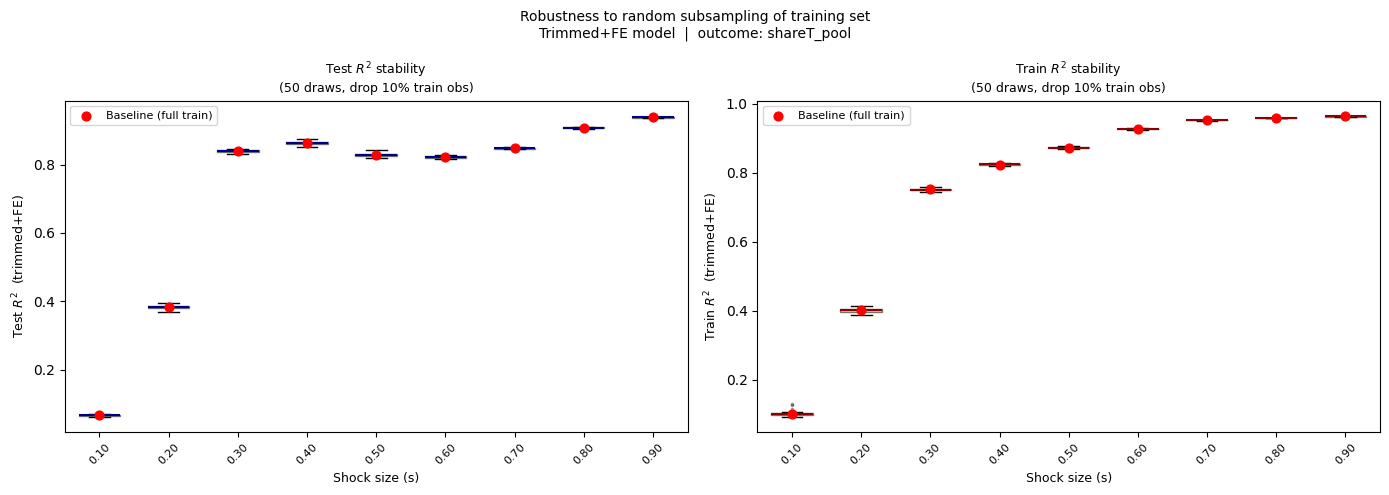

Saved: robustness_size_shock.png / robustness_r2_all_sizes.pdf


In [99]:
"""
Robustness check: random subsampling of the training set.
Produces Figure 17 (robustness_size_shock.png / robustness_r2_all_sizes.pdf)

For each shock size, the pipeline is re-run N_BOOTSTRAP times.
Each iteration randomly drops DROP_SHARE of training observations,
keeping the test set fixed.

Prerequisites (must already be defined in the notebook):
    final_updated, features, break_date, rename_map,
    GROUPS_flat, HAC_MAXLAGS, ALPHA, HEALTH_THRESHOLD
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# ══════════════════════════════════════════════════════════════════
# Config
# ══════════════════════════════════════════════════════════════════
START_DATE       = '2021-01-01'
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['ETH', 'WBTC']

ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200

DROP_SHARE   = 0.10   # fraction of training obs dropped each iteration
N_BOOTSTRAP  = 50     # number of subsampling draws per shock size
RANDOM_SEED  = 42

SHOCK_SIZES  = [round(s, 2) for s in np.arange(0.10, 1.01, 0.10)]

rng = np.random.default_rng(RANDOM_SEED)

# ══════════════════════════════════════════════════════════════════
# Helper: run one full pipeline on a given train/test split
# ══════════════════════════════════════════════════════════════════
def run_pipeline(X_tr_raw, y_tr, X_te_raw, y_te, available,
                 sig_vars_reference=None):
    try:
        scaler  = StandardScaler()
        X_tr_sc = pd.DataFrame(
            scaler.fit_transform(X_tr_raw),
            columns=available, index=X_tr_raw.index
        )
        X_te_sc = pd.DataFrame(
            scaler.transform(X_te_raw),
            columns=available, index=X_te_raw.index
        )

        # Full OLS
        model_full = sm.OLS(y_tr, sm.add_constant(X_tr_sc)).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        y_pred_full = model_full.predict(
            sm.add_constant(X_te_sc, has_constant='add')
        )
        res_full = y_te - y_pred_full
        r2_full  = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()

        # LASSO or reference sig_vars
        if sig_vars_reference is None:
            tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
            lasso_cv = LassoCV(
                cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
                max_iter=10_000, random_state=42
            )
            lasso_cv.fit(X_tr_sc, y_tr)
            coefs_min    = pd.Series(lasso_cv.coef_, index=available)
            selected_min = coefs_min[coefs_min != 0].index.tolist()
            if not selected_min:
                selected_min = available

            model_lasso = sm.OLS(
                y_tr, sm.add_constant(X_tr_sc[selected_min])
            ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
            sig_vars = [v for v in selected_min
                        if model_lasso.pvalues.get(v, 1.0) < ALPHA]
            if not sig_vars:
                sig_vars = [v for v in selected_min
                            if model_lasso.pvalues.get(v, 1.0) < 0.05]
        else:
            sig_vars = [v for v in sig_vars_reference if v in available]

        if not sig_vars:
            return None

        # Trimmed — no FE
        model_trim  = sm.OLS(
            y_tr, sm.add_constant(X_tr_sc[sig_vars])
        ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
        y_pred_trim = model_trim.predict(
            sm.add_constant(X_te_sc[sig_vars], has_constant='add')
        )
        res_trim = y_te - y_pred_trim
        r2_trim  = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()

        # Trimmed — with WBTC FE
        fe_tr = (
            regr_postbreak.loc[X_tr_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values
        fe_te = (
            regr_postbreak.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values

        X_tr_fe            = X_tr_sc[sig_vars].copy()
        X_tr_fe['fe_WBTC'] = fe_tr
        X_te_fe            = X_te_sc[sig_vars].copy()
        X_te_fe['fe_WBTC'] = fe_te

        model_trim_fe = sm.OLS(
            y_tr.astype(float),
            sm.add_constant(X_tr_fe.astype(float))
        ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
        y_pred_trim_fe = model_trim_fe.predict(
            sm.add_constant(X_te_fe.astype(float), has_constant='add')
        )
        res_trim_fe = y_te - y_pred_trim_fe
        r2_trim_fe  = 1 - (res_trim_fe**2).sum() / ((y_te - y_te.mean())**2).sum()

        return {
            'r2_train_full':    model_full.rsquared,
            'r2_test_full':     r2_full,
            'r2_train_trim':    model_trim.rsquared,
            'r2_test_trim':     r2_trim,
            'r2_train_trim_fe': model_trim_fe.rsquared,
            'r2_test_trim_fe':  r2_trim_fe,
            'n_train':          len(y_tr),
            'sig_vars':         sig_vars,
            'coefs_trim_fe':    model_trim_fe.params.drop('const'),
            'pvals_trim_fe':    model_trim_fe.pvalues.drop('const'),
        }
    except Exception:
        return None


# ══════════════════════════════════════════════════════════════════
# Main loop: shock sizes × bootstrap draws
# ══════════════════════════════════════════════════════════════════
robustness_by_size = {}

for SHOCK_SIZE in SHOCK_SIZES:
    print(f"\n{'='*65}")
    print(f"  SHOCK SIZE = {SHOCK_SIZE:.2f}  |  {N_BOOTSTRAP} draws "
          f"(drop {int(DROP_SHARE*100)}% of train)")
    print(f"{'='*65}")

    regr_postbreak = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == SHOCK_SIZE) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    if len(regr_postbreak) < 20:
        print("  *** Too few observations — skipping.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
    available        = [v for v in theory_vars_flat
                        if v in regr_postbreak.columns]

    X_all  = regr_postbreak[available].copy()
    y_all  = regr_postbreak['shareT_pool'].copy()
    dt_all = regr_postbreak['date'].copy()

    row_mask = X_all.notna().all(axis=1) & y_all.notna()
    X_all    = X_all.loc[row_mask]
    y_all    = y_all.loc[row_mask]
    dt_all   = dt_all.loc[row_mask]

    X_all     = X_all.loc[:, X_all.std() > 0]
    available = list(X_all.columns)

    end_mask = dt_all.values <= pd.Timestamp(TEST_END_DATE)
    X_all    = X_all[end_mask]
    y_all    = y_all[end_mask]
    dt_all   = dt_all[end_mask]

    n_total = len(y_all)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    if n_train < 15 or n_test < 5:
        print(f"  *** Train={n_train} / Test={n_test} — too small.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    X_te_raw  = X_all.iloc[n_train:]
    y_te      = y_all.iloc[n_train:]
    X_tr_base = X_all.iloc[:n_train]
    y_tr_base = y_all.iloc[:n_train]

    print(f"  Baseline  train N={n_train}  test N={n_test}")
    baseline = run_pipeline(X_tr_base, y_tr_base, X_te_raw, y_te,
                            available, sig_vars_reference=None)

    if baseline is None:
        print("  *** Baseline failed — skipping.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    ref_sig_vars = baseline['sig_vars']
    print(f"  Baseline sig_vars ({len(ref_sig_vars)})")
    print(f"  Baseline  Train R²={baseline['r2_train_trim_fe']:.4f}  "
          f"Test R²={baseline['r2_test_trim_fe']:.4f}")

    bootstrap_results = []
    n_drop = max(1, int(n_train * DROP_SHARE))

    for b in range(N_BOOTSTRAP):
        drop_idx  = rng.choice(n_train, size=n_drop, replace=False)
        keep_mask = np.ones(n_train, dtype=bool)
        keep_mask[drop_idx] = False

        X_tr_b = X_tr_base.iloc[keep_mask]
        y_tr_b = y_tr_base.iloc[keep_mask]

        res = run_pipeline(X_tr_b, y_tr_b, X_te_raw, y_te,
                           available, sig_vars_reference=ref_sig_vars)

        if res is not None:
            row = {
                'bootstrap':        b,
                'n_train':          len(y_tr_b),
                'r2_train_full':    res['r2_train_full'],
                'r2_test_full':     res['r2_test_full'],
                'r2_train_trim_fe': res['r2_train_trim_fe'],
                'r2_test_trim_fe':  res['r2_test_trim_fe'],
            }
            for var, coef in res['coefs_trim_fe'].items():
                row[f'coef_{var}'] = coef
            for var, pval in res['pvals_trim_fe'].items():
                row[f'pval_{var}'] = pval
            bootstrap_results.append(row)

        if (b + 1) % 10 == 0:
            print(f"  ... {b+1}/{N_BOOTSTRAP} draws done")

    if not bootstrap_results:
        robustness_by_size[SHOCK_SIZE] = None
        continue

    boot_df = pd.DataFrame(bootstrap_results)

    print(f"\n  Bootstrap summary ({len(boot_df)} draws):")
    print(f"  {'Metric':<25} {'Baseline':>10} {'Boot mean':>10} "
          f"{'Boot std':>10}")
    for metric, base_val in [
        ('r2_test_trim_fe',  baseline['r2_test_trim_fe']),
        ('r2_train_trim_fe', baseline['r2_train_trim_fe']),
    ]:
        s = boot_df[metric]
        print(f"  {metric:<25} {base_val:>10.4f} {s.mean():>10.4f} "
              f"{s.std():>10.4f}")

    robustness_by_size[SHOCK_SIZE] = {
        'baseline':     baseline,
        'boot_df':      boot_df,
        'ref_sig_vars': ref_sig_vars,
        'n_train':      n_train,
        'n_test':       n_test,
    }


# ══════════════════════════════════════════════════════════════════
# FIGURE 17: cross-size summary — test R² and train R² box plots
# ══════════════════════════════════════════════════════════════════
sizes_ok = [sz for sz, v in robustness_by_size.items() if v is not None]

if sizes_ok:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: test R² distribution per shock size
    ax = axes[0]
    data_r2 = [robustness_by_size[sz]['boot_df']['r2_test_trim_fe'].dropna()
               for sz in sizes_ok]
    base_r2 = [robustness_by_size[sz]['baseline']['r2_test_trim_fe']
               for sz in sizes_ok]
    ax.boxplot(data_r2, positions=range(len(sizes_ok)), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='navy', lw=1.5),
               whiskerprops=dict(lw=0.8),
               flierprops=dict(marker='.', markersize=3, alpha=0.4),
               widths=0.6)
    ax.scatter(range(len(sizes_ok)), base_r2, color='red', zorder=5,
               s=40, label='Baseline (full train)')
    ax.set_xticks(range(len(sizes_ok)))
    ax.set_xticklabels([f'{sz:.2f}' for sz in sizes_ok],
                       rotation=45, fontsize=8)
    ax.set_xlabel('Shock size (s)', fontsize=9)
    ax.set_ylabel('Test $R^2$  (trimmed+FE)', fontsize=9)
    ax.set_title(f'Test $R^2$ stability\n({N_BOOTSTRAP} draws, '
                 f'drop {int(DROP_SHARE*100)}% train obs)', fontsize=9)
    ax.legend(fontsize=8)

    # Right panel: train R² for comparison
    ax = axes[1]
    data_r2_tr = [robustness_by_size[sz]['boot_df']['r2_train_trim_fe'].dropna()
                  for sz in sizes_ok]
    base_r2_tr = [robustness_by_size[sz]['baseline']['r2_train_trim_fe']
                  for sz in sizes_ok]
    ax.boxplot(data_r2_tr, positions=range(len(sizes_ok)), patch_artist=True,
               boxprops=dict(facecolor='coral', alpha=0.5),
               medianprops=dict(color='darkred', lw=1.5),
               whiskerprops=dict(lw=0.8),
               flierprops=dict(marker='.', markersize=3, alpha=0.4),
               widths=0.6)
    ax.scatter(range(len(sizes_ok)), base_r2_tr, color='red', zorder=5,
               s=40, label='Baseline (full train)')
    ax.set_xticks(range(len(sizes_ok)))
    ax.set_xticklabels([f'{sz:.2f}' for sz in sizes_ok],
                       rotation=45, fontsize=8)
    ax.set_xlabel('Shock size (s)', fontsize=9)
    ax.set_ylabel('Train $R^2$  (trimmed+FE)', fontsize=9)
    ax.set_title(f'Train $R^2$ stability\n({N_BOOTSTRAP} draws, '
                 f'drop {int(DROP_SHARE*100)}% train obs)', fontsize=9)
    ax.legend(fontsize=8)

    fig.suptitle(
        'Robustness to random subsampling of training set\n'
        'Trimmed+FE model  |  outcome: shareT_pool',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig('robustness_size_shock.png', bbox_inches='tight', dpi=150)
    plt.savefig('robustness_r2_all_sizes.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: robustness_size_shock.png / robustness_r2_all_sizes.pdf")

In [100]:
sz = 0.90
bd = robustness_by_size[sz]['boot_df']
bl = robustness_by_size[sz]['baseline']
print(f"no-FE  baseline={bl['r2_test_trim']:.3f}   "
      f"boot mean={bd['r2_test_full'].mean():.3f}")
print(f"+FE    baseline={bl['r2_test_trim_fe']:.3f}  "
      f"boot mean={bd['r2_test_trim_fe'].mean():.3f}")
print(f"n sig_vars: {len(bl['sig_vars'])}")

no-FE  baseline=0.937   boot mean=0.903
+FE    baseline=0.938  boot mean=0.938
n sig_vars: 11



  SHOCK SIZE = 0.10  |  50 draws (drop 10% of train)
  Baseline  train N=1607  test N=401
  Baseline sig_vars (3)
  Baseline  Train R²=0.1017  Test R²=0.0664
  ... 10/50 draws done
  ... 20/50 draws done
  ... 30/50 draws done
  ... 40/50 draws done
  ... 50/50 draws done

  Bootstrap summary (50 draws):
  Metric                      Baseline  Boot mean   Boot std
  r2_test_trim_fe               0.0664     0.0665     0.0033
  r2_train_trim_fe              0.1017     0.0990     0.0092

  SHOCK SIZE = 0.20  |  50 draws (drop 10% of train)
  Baseline  train N=1607  test N=401
  Baseline sig_vars (7)
  Baseline  Train R²=0.4008  Test R²=0.3835
  ... 10/50 draws done
  ... 20/50 draws done
  ... 30/50 draws done
  ... 40/50 draws done
  ... 50/50 draws done

  Bootstrap summary (50 draws):
  Metric                      Baseline  Boot mean   Boot std
  r2_test_trim_fe               0.3835     0.3934     0.0338
  r2_train_trim_fe              0.4008     0.4055     0.0207

  SHOCK SIZE = 0.30

/var/folders/95/0gcj87_150g4pzspfbpj6m7w0000gp/T/ipykernel_26015/1628844489.py:75: RuntimeWarning: invalid value encountered in scalar divide
  r2_full  = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()


  *** Baseline failed — skipping.


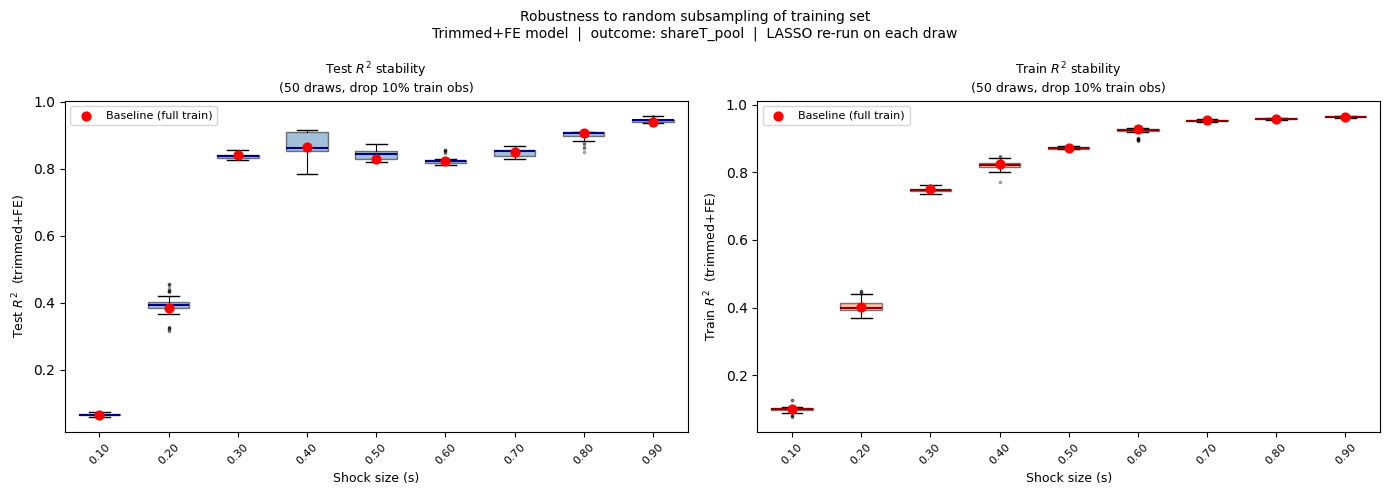

Saved: robustness_size_shock.png / robustness_r2_all_sizes.pdf


In [101]:
"""
Robustness check: random subsampling of the training set.
Produces Figure 17 (robustness_size_shock.png / robustness_r2_all_sizes.pdf)

For each shock size, the pipeline is re-run N_BOOTSTRAP times.
Each iteration randomly drops DROP_SHARE of training observations,
keeping the test set fixed.

Prerequisites (must already be defined in the notebook):
    final_updated, features, break_date, rename_map,
    GROUPS_flat, HAC_MAXLAGS, ALPHA, HEALTH_THRESHOLD
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# ══════════════════════════════════════════════════════════════════
# Config
# ══════════════════════════════════════════════════════════════════
START_DATE       = '2021-01-01'
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['ETH', 'WBTC']

ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200

DROP_SHARE   = 0.10   # fraction of training obs dropped each iteration
N_BOOTSTRAP  = 50     # number of subsampling draws per shock size
RANDOM_SEED  = 42

# Variable set across draws:
#   False -> re-run LASSO on every draw. Boxes then reflect selection
#            noise AND coefficient noise. Much slower.
#   True  -> hold the baseline sig_vars fixed. Boxes reflect
#            coefficient noise only.
FIX_VARS_ACROSS_DRAWS = False

SHOCK_SIZES  = [round(s, 2) for s in np.arange(0.10, 1.01, 0.10)]

rng = np.random.default_rng(RANDOM_SEED)

# ══════════════════════════════════════════════════════════════════
# Helper: run one full pipeline on a given train/test split
# ══════════════════════════════════════════════════════════════════
def run_pipeline(X_tr_raw, y_tr, X_te_raw, y_te, available,
                 sig_vars_reference=None):
    try:
        scaler  = StandardScaler()
        X_tr_sc = pd.DataFrame(
            scaler.fit_transform(X_tr_raw),
            columns=available, index=X_tr_raw.index
        )
        X_te_sc = pd.DataFrame(
            scaler.transform(X_te_raw),
            columns=available, index=X_te_raw.index
        )

        # Full OLS
        model_full = sm.OLS(y_tr, sm.add_constant(X_tr_sc)).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        y_pred_full = model_full.predict(
            sm.add_constant(X_te_sc, has_constant='add')
        )
        res_full = y_te - y_pred_full
        r2_full  = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()

        # LASSO or reference sig_vars
        if sig_vars_reference is None:
            tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
            lasso_cv = LassoCV(
                cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
                max_iter=10_000, random_state=42
            )
            lasso_cv.fit(X_tr_sc, y_tr)
            coefs_min    = pd.Series(lasso_cv.coef_, index=available)
            selected_min = coefs_min[coefs_min != 0].index.tolist()
            if not selected_min:
                selected_min = available

            model_lasso = sm.OLS(
                y_tr, sm.add_constant(X_tr_sc[selected_min])
            ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
            sig_vars = [v for v in selected_min
                        if model_lasso.pvalues.get(v, 1.0) < ALPHA]
            if not sig_vars:
                sig_vars = [v for v in selected_min
                            if model_lasso.pvalues.get(v, 1.0) < 0.05]
        else:
            sig_vars = [v for v in sig_vars_reference if v in available]

        if not sig_vars:
            return None

        # Trimmed — no FE
        model_trim  = sm.OLS(
            y_tr, sm.add_constant(X_tr_sc[sig_vars])
        ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
        y_pred_trim = model_trim.predict(
            sm.add_constant(X_te_sc[sig_vars], has_constant='add')
        )
        res_trim = y_te - y_pred_trim
        r2_trim  = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()

        # Trimmed — with WBTC FE
        fe_tr = (
            regr_postbreak.loc[X_tr_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values
        fe_te = (
            regr_postbreak.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values

        X_tr_fe            = X_tr_sc[sig_vars].copy()
        X_tr_fe['fe_WBTC'] = fe_tr
        X_te_fe            = X_te_sc[sig_vars].copy()
        X_te_fe['fe_WBTC'] = fe_te

        model_trim_fe = sm.OLS(
            y_tr.astype(float),
            sm.add_constant(X_tr_fe.astype(float))
        ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
        y_pred_trim_fe = model_trim_fe.predict(
            sm.add_constant(X_te_fe.astype(float), has_constant='add')
        )
        res_trim_fe = y_te - y_pred_trim_fe
        r2_trim_fe  = 1 - (res_trim_fe**2).sum() / ((y_te - y_te.mean())**2).sum()

        return {
            'r2_train_full':    model_full.rsquared,
            'r2_test_full':     r2_full,
            'r2_train_trim':    model_trim.rsquared,
            'r2_test_trim':     r2_trim,
            'r2_train_trim_fe': model_trim_fe.rsquared,
            'r2_test_trim_fe':  r2_trim_fe,
            'n_train':          len(y_tr),
            'sig_vars':         sig_vars,
            'coefs_trim_fe':    model_trim_fe.params.drop('const'),
            'pvals_trim_fe':    model_trim_fe.pvalues.drop('const'),
        }
    except Exception:
        return None


# ══════════════════════════════════════════════════════════════════
# Main loop: shock sizes × bootstrap draws
# ══════════════════════════════════════════════════════════════════
robustness_by_size = {}

for SHOCK_SIZE in SHOCK_SIZES:
    print(f"\n{'='*65}")
    print(f"  SHOCK SIZE = {SHOCK_SIZE:.2f}  |  {N_BOOTSTRAP} draws "
          f"(drop {int(DROP_SHARE*100)}% of train)")
    print(f"{'='*65}")

    regr_postbreak = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == SHOCK_SIZE) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    if len(regr_postbreak) < 20:
        print("  *** Too few observations — skipping.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
    available        = [v for v in theory_vars_flat
                        if v in regr_postbreak.columns]

    X_all  = regr_postbreak[available].copy()
    y_all  = regr_postbreak['shareT_pool'].copy()
    dt_all = regr_postbreak['date'].copy()

    row_mask = X_all.notna().all(axis=1) & y_all.notna()
    X_all    = X_all.loc[row_mask]
    y_all    = y_all.loc[row_mask]
    dt_all   = dt_all.loc[row_mask]

    X_all     = X_all.loc[:, X_all.std() > 0]
    available = list(X_all.columns)

    end_mask = dt_all.values <= pd.Timestamp(TEST_END_DATE)
    X_all    = X_all[end_mask]
    y_all    = y_all[end_mask]
    dt_all   = dt_all[end_mask]

    n_total = len(y_all)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    if n_train < 15 or n_test < 5:
        print(f"  *** Train={n_train} / Test={n_test} — too small.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    X_te_raw  = X_all.iloc[n_train:]
    y_te      = y_all.iloc[n_train:]
    X_tr_base = X_all.iloc[:n_train]
    y_tr_base = y_all.iloc[:n_train]

    print(f"  Baseline  train N={n_train}  test N={n_test}")
    baseline = run_pipeline(X_tr_base, y_tr_base, X_te_raw, y_te,
                            available, sig_vars_reference=None)

    if baseline is None:
        print("  *** Baseline failed — skipping.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    ref_sig_vars = baseline['sig_vars']
    print(f"  Baseline sig_vars ({len(ref_sig_vars)})")
    print(f"  Baseline  Train R²={baseline['r2_train_trim_fe']:.4f}  "
          f"Test R²={baseline['r2_test_trim_fe']:.4f}")

    bootstrap_results = []
    n_drop = max(1, int(n_train * DROP_SHARE))

    for b in range(N_BOOTSTRAP):
        drop_idx  = rng.choice(n_train, size=n_drop, replace=False)
        keep_mask = np.ones(n_train, dtype=bool)
        keep_mask[drop_idx] = False

        X_tr_b = X_tr_base.iloc[keep_mask]
        y_tr_b = y_tr_base.iloc[keep_mask]

        res = run_pipeline(X_tr_b, y_tr_b, X_te_raw, y_te,
                           available,
                           sig_vars_reference=(ref_sig_vars
                                               if FIX_VARS_ACROSS_DRAWS
                                               else None))

        if res is not None:
            row = {
                'bootstrap':        b,
                'n_train':          len(y_tr_b),
                'r2_train_full':    res['r2_train_full'],
                'r2_test_full':     res['r2_test_full'],
                'r2_train_trim_fe': res['r2_train_trim_fe'],
                'r2_test_trim_fe':  res['r2_test_trim_fe'],
            }
            for var, coef in res['coefs_trim_fe'].items():
                row[f'coef_{var}'] = coef
            for var, pval in res['pvals_trim_fe'].items():
                row[f'pval_{var}'] = pval
            bootstrap_results.append(row)

        if (b + 1) % 10 == 0:
            print(f"  ... {b+1}/{N_BOOTSTRAP} draws done")

    if not bootstrap_results:
        robustness_by_size[SHOCK_SIZE] = None
        continue

    boot_df = pd.DataFrame(bootstrap_results)

    print(f"\n  Bootstrap summary ({len(boot_df)} draws):")
    print(f"  {'Metric':<25} {'Baseline':>10} {'Boot mean':>10} "
          f"{'Boot std':>10}")
    for metric, base_val in [
        ('r2_test_trim_fe',  baseline['r2_test_trim_fe']),
        ('r2_train_trim_fe', baseline['r2_train_trim_fe']),
    ]:
        s = boot_df[metric]
        print(f"  {metric:<25} {base_val:>10.4f} {s.mean():>10.4f} "
              f"{s.std():>10.4f}")

    robustness_by_size[SHOCK_SIZE] = {
        'baseline':     baseline,
        'boot_df':      boot_df,
        'ref_sig_vars': ref_sig_vars,
        'n_train':      n_train,
        'n_test':       n_test,
    }


# ══════════════════════════════════════════════════════════════════
# FIGURE 17: cross-size summary — test R² and train R² box plots
# ══════════════════════════════════════════════════════════════════
sizes_ok = [sz for sz, v in robustness_by_size.items() if v is not None]

if sizes_ok:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: test R² distribution per shock size
    ax = axes[0]
    data_r2 = [robustness_by_size[sz]['boot_df']['r2_test_trim_fe'].dropna()
               for sz in sizes_ok]
    base_r2 = [robustness_by_size[sz]['baseline']['r2_test_trim_fe']
               for sz in sizes_ok]
    ax.boxplot(data_r2, positions=range(len(sizes_ok)), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='navy', lw=1.5),
               whiskerprops=dict(lw=0.8),
               flierprops=dict(marker='.', markersize=3, alpha=0.4),
               widths=0.6)
    ax.scatter(range(len(sizes_ok)), base_r2, color='red', zorder=5,
               s=40, label='Baseline (full train)')
    ax.set_xticks(range(len(sizes_ok)))
    ax.set_xticklabels([f'{sz:.2f}' for sz in sizes_ok],
                       rotation=45, fontsize=8)
    ax.set_xlabel('Shock size (s)', fontsize=9)
    ax.set_ylabel('Test $R^2$  (trimmed+FE)', fontsize=9)
    ax.set_title(f'Test $R^2$ stability\n({N_BOOTSTRAP} draws, '
                 f'drop {int(DROP_SHARE*100)}% train obs)', fontsize=9)
    ax.legend(fontsize=8)

    # Right panel: train R² for comparison
    ax = axes[1]
    data_r2_tr = [robustness_by_size[sz]['boot_df']['r2_train_trim_fe'].dropna()
                  for sz in sizes_ok]
    base_r2_tr = [robustness_by_size[sz]['baseline']['r2_train_trim_fe']
                  for sz in sizes_ok]
    ax.boxplot(data_r2_tr, positions=range(len(sizes_ok)), patch_artist=True,
               boxprops=dict(facecolor='coral', alpha=0.5),
               medianprops=dict(color='darkred', lw=1.5),
               whiskerprops=dict(lw=0.8),
               flierprops=dict(marker='.', markersize=3, alpha=0.4),
               widths=0.6)
    ax.scatter(range(len(sizes_ok)), base_r2_tr, color='red', zorder=5,
               s=40, label='Baseline (full train)')
    ax.set_xticks(range(len(sizes_ok)))
    ax.set_xticklabels([f'{sz:.2f}' for sz in sizes_ok],
                       rotation=45, fontsize=8)
    ax.set_xlabel('Shock size (s)', fontsize=9)
    ax.set_ylabel('Train $R^2$  (trimmed+FE)', fontsize=9)
    ax.set_title(f'Train $R^2$ stability\n({N_BOOTSTRAP} draws, '
                 f'drop {int(DROP_SHARE*100)}% train obs)', fontsize=9)
    ax.legend(fontsize=8)

    vars_note = ('variable set fixed at baseline'
                 if FIX_VARS_ACROSS_DRAWS
                 else 'LASSO re-run on each draw')
    fig.suptitle(
        'Robustness to random subsampling of training set\n'
        f'Trimmed+FE model  |  outcome: shareT_pool  |  {vars_note}',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig('robustness_size_shock.png', bbox_inches='tight', dpi=150)
    plt.savefig('robustness_r2_all_sizes.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: robustness_size_shock.png / robustness_r2_all_sizes.pdf")


  SHOCK SIZE = 0.10  |  50 draws (drop 10% of train)
  Baseline  train N=1607  test N=401
  Baseline sig_vars (3)
  Baseline  Train R²=0.1017  Test R²=0.0664
  ... 10/50 draws done
  ... 20/50 draws done
  ... 30/50 draws done
  ... 40/50 draws done
  ... 50/50 draws done

  Bootstrap summary (50 draws):
  Arm                      Baseline  Boot mean   Boot std  IQR width
  fixed vars (test)          0.0664     0.0656     0.0022     0.0026
  LASSO each draw (test)     0.0664     0.0665     0.0033     0.0044
  vars selected: baseline=3  draws min=1 median=3 max=4

  SHOCK SIZE = 0.20  |  50 draws (drop 10% of train)
  Baseline  train N=1607  test N=401
  Baseline sig_vars (7)
  Baseline  Train R²=0.4008  Test R²=0.3835
  ... 10/50 draws done
  ... 20/50 draws done
  ... 30/50 draws done
  ... 40/50 draws done
  ... 50/50 draws done

  Bootstrap summary (50 draws):
  Arm                      Baseline  Boot mean   Boot std  IQR width
  fixed vars (test)          0.3835     0.3832     0.0

/var/folders/95/0gcj87_150g4pzspfbpj6m7w0000gp/T/ipykernel_26015/1606914029.py:73: RuntimeWarning: invalid value encountered in scalar divide
  r2_full  = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()


  *** Baseline failed — skipping.


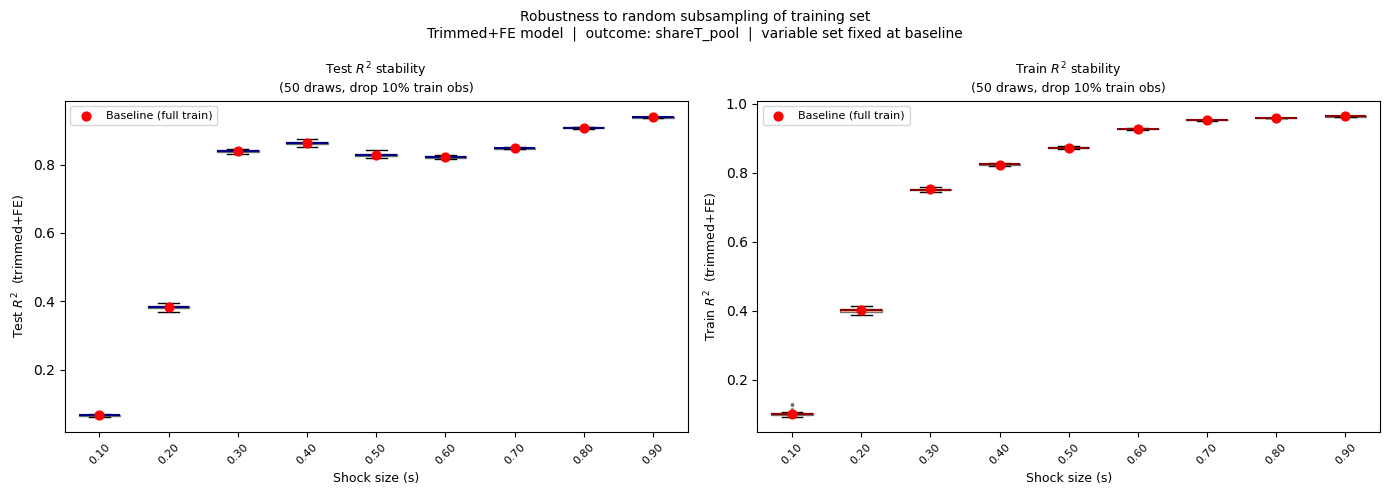

Saved: robustness_size_shock_fixedvars.png / .pdf


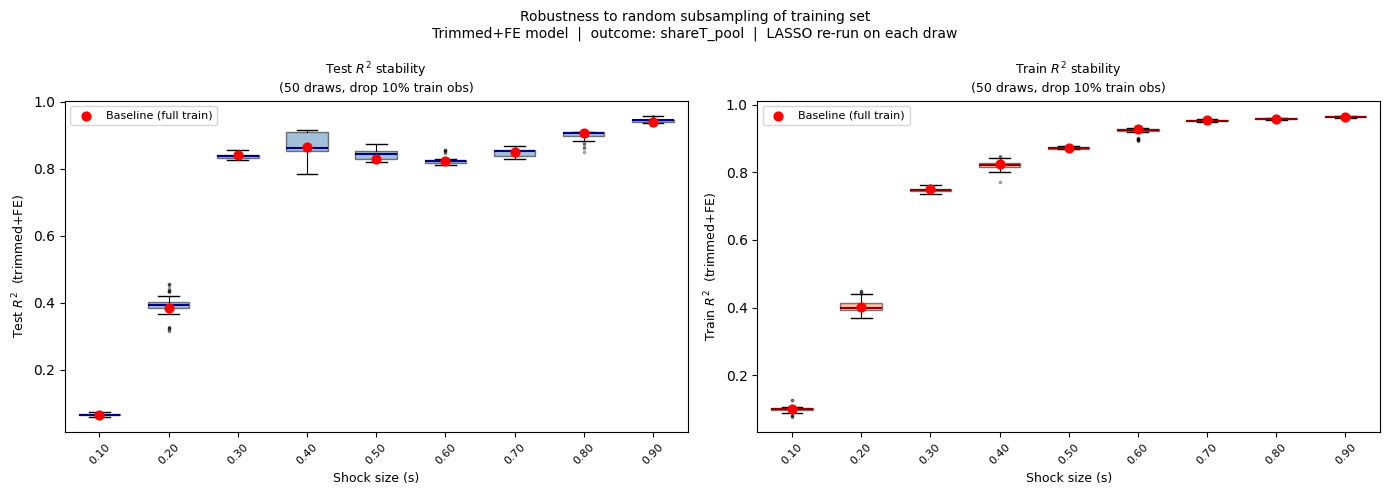

Saved: robustness_size_shock_reselect.png / .pdf


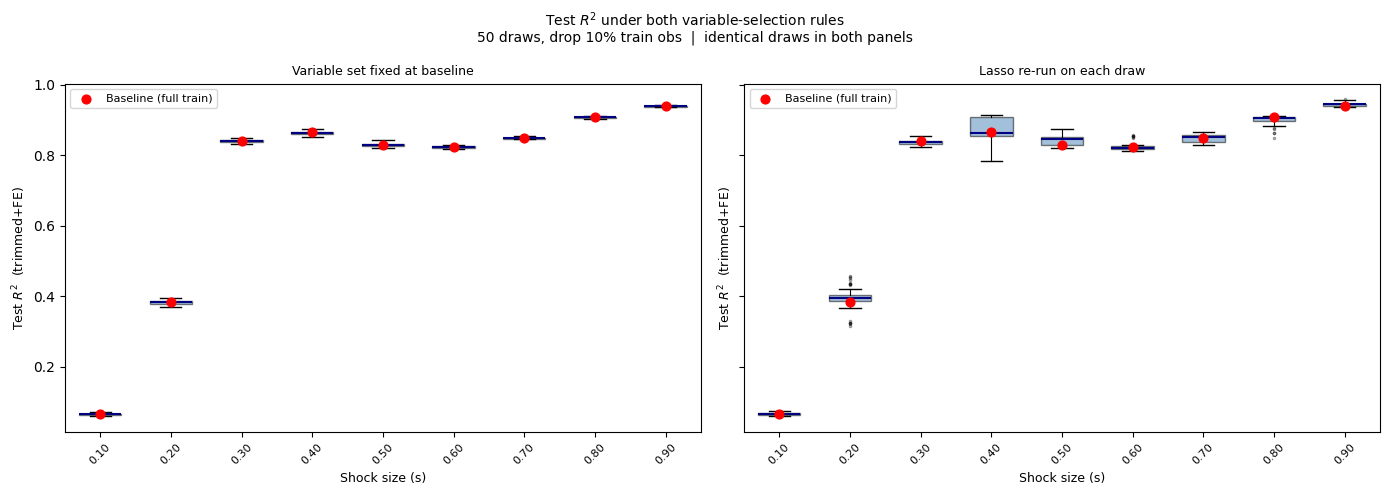

Saved: robustness_size_shock_comparison.png / .pdf

  Size    IQR fixed   IQR reselect   Baseline
----------------------------------------------
  0.10       0.003         0.004     0.066
  0.20       0.009         0.019     0.384
  0.30       0.004         0.011     0.840
  0.40       0.007         0.055     0.865
  0.50       0.007         0.022     0.830
  0.60       0.005         0.009     0.823
  0.70       0.003         0.020     0.849
  0.80       0.003         0.012     0.907
  0.90       0.002         0.007     0.938


In [102]:
"""
Robustness check: random subsampling of the training set.
Produces Figure 17 (robustness_size_shock.png / robustness_r2_all_sizes.pdf)

For each shock size, the pipeline is re-run N_BOOTSTRAP times.
Each iteration randomly drops DROP_SHARE of training observations,
keeping the test set fixed.

Prerequisites (must already be defined in the notebook):
    final_updated, features, break_date, rename_map,
    GROUPS_flat, HAC_MAXLAGS, ALPHA, HEALTH_THRESHOLD
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# ══════════════════════════════════════════════════════════════════
# Config
# ══════════════════════════════════════════════════════════════════
START_DATE       = '2021-01-01'
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
CRYPTO_ASSETS    = ['ETH', 'WBTC']

ALPHA            = 0.001
HAC_MAXLAGS      = 4
TEST_SIZE        = 0.2
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200

DROP_SHARE   = 0.10   # fraction of training obs dropped each iteration
N_BOOTSTRAP  = 50     # number of subsampling draws per shock size
RANDOM_SEED  = 42

# Variable set across draws.
# Both selection rules are run on every draw and reported separately:
#   fixed    -> baseline sig_vars held constant (coefficient noise only)
#   reselect -> LASSO re-run each draw (selection + coefficient noise)

SHOCK_SIZES  = [round(s, 2) for s in np.arange(0.10, 1.01, 0.10)]

rng = np.random.default_rng(RANDOM_SEED)

# ══════════════════════════════════════════════════════════════════
# Helper: run one full pipeline on a given train/test split
# ══════════════════════════════════════════════════════════════════
def run_pipeline(X_tr_raw, y_tr, X_te_raw, y_te, available,
                 sig_vars_reference=None):
    try:
        scaler  = StandardScaler()
        X_tr_sc = pd.DataFrame(
            scaler.fit_transform(X_tr_raw),
            columns=available, index=X_tr_raw.index
        )
        X_te_sc = pd.DataFrame(
            scaler.transform(X_te_raw),
            columns=available, index=X_te_raw.index
        )

        # Full OLS
        model_full = sm.OLS(y_tr, sm.add_constant(X_tr_sc)).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS}
        )
        y_pred_full = model_full.predict(
            sm.add_constant(X_te_sc, has_constant='add')
        )
        res_full = y_te - y_pred_full
        r2_full  = 1 - (res_full**2).sum() / ((y_te - y_te.mean())**2).sum()

        # LASSO or reference sig_vars
        if sig_vars_reference is None:
            tscv     = TimeSeriesSplit(n_splits=N_SPLITS)
            lasso_cv = LassoCV(
                cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
                max_iter=10_000, random_state=42
            )
            lasso_cv.fit(X_tr_sc, y_tr)
            coefs_min    = pd.Series(lasso_cv.coef_, index=available)
            selected_min = coefs_min[coefs_min != 0].index.tolist()
            if not selected_min:
                selected_min = available

            model_lasso = sm.OLS(
                y_tr, sm.add_constant(X_tr_sc[selected_min])
            ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
            sig_vars = [v for v in selected_min
                        if model_lasso.pvalues.get(v, 1.0) < ALPHA]
            if not sig_vars:
                sig_vars = [v for v in selected_min
                            if model_lasso.pvalues.get(v, 1.0) < 0.05]
        else:
            sig_vars = [v for v in sig_vars_reference if v in available]

        if not sig_vars:
            return None

        # Trimmed — no FE
        model_trim  = sm.OLS(
            y_tr, sm.add_constant(X_tr_sc[sig_vars])
        ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
        y_pred_trim = model_trim.predict(
            sm.add_constant(X_te_sc[sig_vars], has_constant='add')
        )
        res_trim = y_te - y_pred_trim
        r2_trim  = 1 - (res_trim**2).sum() / ((y_te - y_te.mean())**2).sum()

        # Trimmed — with WBTC FE
        fe_tr = (
            regr_postbreak.loc[X_tr_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values
        fe_te = (
            regr_postbreak.loc[X_te_raw.index, 'shockAsset'] == 'WBTC'
        ).astype(float).values

        X_tr_fe            = X_tr_sc[sig_vars].copy()
        X_tr_fe['fe_WBTC'] = fe_tr
        X_te_fe            = X_te_sc[sig_vars].copy()
        X_te_fe['fe_WBTC'] = fe_te

        model_trim_fe = sm.OLS(
            y_tr.astype(float),
            sm.add_constant(X_tr_fe.astype(float))
        ).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
        y_pred_trim_fe = model_trim_fe.predict(
            sm.add_constant(X_te_fe.astype(float), has_constant='add')
        )
        res_trim_fe = y_te - y_pred_trim_fe
        r2_trim_fe  = 1 - (res_trim_fe**2).sum() / ((y_te - y_te.mean())**2).sum()

        return {
            'r2_train_full':    model_full.rsquared,
            'r2_test_full':     r2_full,
            'r2_train_trim':    model_trim.rsquared,
            'r2_test_trim':     r2_trim,
            'r2_train_trim_fe': model_trim_fe.rsquared,
            'r2_test_trim_fe':  r2_trim_fe,
            'n_train':          len(y_tr),
            'sig_vars':         sig_vars,
            'coefs_trim_fe':    model_trim_fe.params.drop('const'),
            'pvals_trim_fe':    model_trim_fe.pvalues.drop('const'),
        }
    except Exception:
        return None


# ══════════════════════════════════════════════════════════════════
# Main loop: shock sizes × bootstrap draws
# ══════════════════════════════════════════════════════════════════
robustness_by_size = {}

for SHOCK_SIZE in SHOCK_SIZES:
    print(f"\n{'='*65}")
    print(f"  SHOCK SIZE = {SHOCK_SIZE:.2f}  |  {N_BOOTSTRAP} draws "
          f"(drop {int(DROP_SHARE*100)}% of train)")
    print(f"{'='*65}")

    regr_postbreak = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == SHOCK_SIZE) &
        (final_updated['shockAsset'].isin(CRYPTO_ASSETS)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    if len(regr_postbreak) < 20:
        print("  *** Too few observations — skipping.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    theory_vars_flat = [v for g in GROUPS_flat for v in features[g]]
    available        = [v for v in theory_vars_flat
                        if v in regr_postbreak.columns]

    X_all  = regr_postbreak[available].copy()
    y_all  = regr_postbreak['shareT_pool'].copy()
    dt_all = regr_postbreak['date'].copy()

    row_mask = X_all.notna().all(axis=1) & y_all.notna()
    X_all    = X_all.loc[row_mask]
    y_all    = y_all.loc[row_mask]
    dt_all   = dt_all.loc[row_mask]

    X_all     = X_all.loc[:, X_all.std() > 0]
    available = list(X_all.columns)

    end_mask = dt_all.values <= pd.Timestamp(TEST_END_DATE)
    X_all    = X_all[end_mask]
    y_all    = y_all[end_mask]
    dt_all   = dt_all[end_mask]

    n_total = len(y_all)
    n_test  = int(n_total * TEST_SIZE)
    n_train = n_total - n_test

    if n_train < 15 or n_test < 5:
        print(f"  *** Train={n_train} / Test={n_test} — too small.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    X_te_raw  = X_all.iloc[n_train:]
    y_te      = y_all.iloc[n_train:]
    X_tr_base = X_all.iloc[:n_train]
    y_tr_base = y_all.iloc[:n_train]

    print(f"  Baseline  train N={n_train}  test N={n_test}")
    baseline = run_pipeline(X_tr_base, y_tr_base, X_te_raw, y_te,
                            available, sig_vars_reference=None)

    if baseline is None:
        print("  *** Baseline failed — skipping.")
        robustness_by_size[SHOCK_SIZE] = None
        continue

    ref_sig_vars = baseline['sig_vars']
    print(f"  Baseline sig_vars ({len(ref_sig_vars)})")
    print(f"  Baseline  Train R²={baseline['r2_train_trim_fe']:.4f}  "
          f"Test R²={baseline['r2_test_trim_fe']:.4f}")

    bootstrap_results = []
    n_drop = max(1, int(n_train * DROP_SHARE))

    for b in range(N_BOOTSTRAP):
        drop_idx  = rng.choice(n_train, size=n_drop, replace=False)
        keep_mask = np.ones(n_train, dtype=bool)
        keep_mask[drop_idx] = False

        X_tr_b = X_tr_base.iloc[keep_mask]
        y_tr_b = y_tr_base.iloc[keep_mask]

        # Same dropped observations, two selection rules
        res_fix = run_pipeline(X_tr_b, y_tr_b, X_te_raw, y_te,
                               available, sig_vars_reference=ref_sig_vars)
        res_sel = run_pipeline(X_tr_b, y_tr_b, X_te_raw, y_te,
                               available, sig_vars_reference=None)

        if res_fix is not None or res_sel is not None:
            row = {'bootstrap': b, 'n_train': len(y_tr_b)}
            if res_fix is not None:
                row['r2_test_fix']  = res_fix['r2_test_trim_fe']
                row['r2_train_fix'] = res_fix['r2_train_trim_fe']
            if res_sel is not None:
                row['r2_test_sel']  = res_sel['r2_test_trim_fe']
                row['r2_train_sel'] = res_sel['r2_train_trim_fe']
                row['n_vars_sel']   = len(res_sel['sig_vars'])
                for var, coef in res_sel['coefs_trim_fe'].items():
                    row[f'coef_{var}'] = coef
            bootstrap_results.append(row)

        if (b + 1) % 10 == 0:
            print(f"  ... {b+1}/{N_BOOTSTRAP} draws done")

    if not bootstrap_results:
        robustness_by_size[SHOCK_SIZE] = None
        continue

    boot_df = pd.DataFrame(bootstrap_results)

    print(f"\n  Bootstrap summary ({len(boot_df)} draws):")
    print(f"  {'Arm':<22} {'Baseline':>10} {'Boot mean':>10} "
          f"{'Boot std':>10} {'IQR width':>10}")
    for arm, col in [('fixed vars (test)',      'r2_test_fix'),
                     ('LASSO each draw (test)', 'r2_test_sel')]:
        if col not in boot_df:
            continue
        s = boot_df[col].dropna()
        iqr = np.percentile(s, 75) - np.percentile(s, 25)
        print(f"  {arm:<22} {baseline['r2_test_trim_fe']:>10.4f} "
              f"{s.mean():>10.4f} {s.std():>10.4f} {iqr:>10.4f}")
    if 'n_vars_sel' in boot_df:
        nv = boot_df['n_vars_sel'].dropna()
        print(f"  vars selected: baseline={len(ref_sig_vars)}  "
              f"draws min={nv.min():.0f} median={nv.median():.0f} "
              f"max={nv.max():.0f}")

    robustness_by_size[SHOCK_SIZE] = {
        'baseline':     baseline,
        'boot_df':      boot_df,
        'ref_sig_vars': ref_sig_vars,
        'n_train':      n_train,
        'n_test':       n_test,
    }


# ══════════════════════════════════════════════════════════════════
# FIGURES — one per selection rule, plus a side-by-side comparison
# ══════════════════════════════════════════════════════════════════
sizes_ok = [sz for sz, v in robustness_by_size.items() if v is not None]

ARMS = {
    'fix': dict(test='r2_test_fix', train='r2_train_fix',
                note='variable set fixed at baseline',
                fname='robustness_size_shock_fixedvars'),
    'sel': dict(test='r2_test_sel', train='r2_train_sel',
                note='LASSO re-run on each draw',
                fname='robustness_size_shock_reselect'),
}


def _box(ax, series_list, baselines, color, edge, ylabel, title):
    ax.boxplot(series_list, positions=range(len(series_list)),
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color=edge, lw=1.5),
               whiskerprops=dict(lw=0.8),
               flierprops=dict(marker='.', markersize=3, alpha=0.4),
               widths=0.6)
    ax.scatter(range(len(baselines)), baselines, color='red', zorder=5,
               s=40, label='Baseline (full train)')
    ax.set_xticks(range(len(sizes_ok)))
    ax.set_xticklabels([f'{sz:.2f}' for sz in sizes_ok],
                       rotation=45, fontsize=8)
    ax.set_xlabel('Shock size (s)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)


if sizes_ok:
    base_test  = [robustness_by_size[sz]['baseline']['r2_test_trim_fe']
                  for sz in sizes_ok]
    base_train = [robustness_by_size[sz]['baseline']['r2_train_trim_fe']
                  for sz in sizes_ok]

    # ── One figure per arm ────────────────────────────────────────
    for arm, cfg in ARMS.items():
        if cfg['test'] not in robustness_by_size[sizes_ok[0]]['boot_df']:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        _box(axes[0],
             [robustness_by_size[sz]['boot_df'][cfg['test']].dropna()
              for sz in sizes_ok],
             base_test, 'steelblue', 'navy',
             'Test $R^2$  (trimmed+FE)',
             f'Test $R^2$ stability\n({N_BOOTSTRAP} draws, '
             f'drop {int(DROP_SHARE*100)}% train obs)')
        _box(axes[1],
             [robustness_by_size[sz]['boot_df'][cfg['train']].dropna()
              for sz in sizes_ok],
             base_train, 'coral', 'darkred',
             'Train $R^2$  (trimmed+FE)',
             f'Train $R^2$ stability\n({N_BOOTSTRAP} draws, '
             f'drop {int(DROP_SHARE*100)}% train obs)')
        fig.suptitle(
            'Robustness to random subsampling of training set\n'
            f'Trimmed+FE model  |  outcome: shareT_pool  |  {cfg["note"]}',
            fontsize=10
        )
        plt.tight_layout()
        plt.savefig(f'{cfg["fname"]}.png', bbox_inches='tight', dpi=150)
        plt.savefig(f'{cfg["fname"]}.pdf', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'Saved: {cfg["fname"]}.png / .pdf')

    # ── Side-by-side: test R² under both rules ────────────────────
    have_both = all(c in robustness_by_size[sizes_ok[0]]['boot_df']
                    for c in ('r2_test_fix', 'r2_test_sel'))
    if have_both:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        for ax, arm in zip(axes, ('fix', 'sel')):
            cfg = ARMS[arm]
            _box(ax,
                 [robustness_by_size[sz]['boot_df'][cfg['test']].dropna()
                  for sz in sizes_ok],
                 base_test, 'steelblue', 'navy',
                 'Test $R^2$  (trimmed+FE)',
                 cfg['note'].capitalize())
        fig.suptitle(
            'Test $R^2$ under both variable-selection rules\n'
            f'{N_BOOTSTRAP} draws, drop {int(DROP_SHARE*100)}% train obs  |  '
            'identical draws in both panels',
            fontsize=10
        )
        plt.tight_layout()
        plt.savefig('robustness_size_shock_comparison.png',
                    bbox_inches='tight', dpi=150)
        plt.savefig('robustness_size_shock_comparison.pdf',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: robustness_size_shock_comparison.png / .pdf')

    # ── IQR width table ───────────────────────────────────────────
    print(f"\n{'Size':>6} {'IQR fixed':>12} {'IQR reselect':>14} "
          f"{'Baseline':>10}")
    print('-' * 46)
    for sz, bt in zip(sizes_ok, base_test):
        bd = robustness_by_size[sz]['boot_df']
        out = [f'{sz:>6.2f}']
        for col in ('r2_test_fix', 'r2_test_sel'):
            if col in bd:
                s = bd[col].dropna()
                w = np.percentile(s, 75) - np.percentile(s, 25)
                out.append(f'{w:>12.3f}' if col == 'r2_test_fix'
                           else f'{w:>14.3f}')
            else:
                out.append(f'{"—":>12}')
        out.append(f'{bt:>10.3f}')
        print(''.join(out))